# Quantum_Analysis — part 1 of 2

This notebook was automatically split from a larger notebook.

# Quantum-like Analysis

[     0.0s] Loading EEG data from: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
[     0.1s] Loaded EEG segment: shape=(106944, 32)
[     0.1s] Segment: [814.571, 921.515] sec
[     0.1s] Windowing setup | window=2.00s (2000 samples) | step=0.50s (500 samples) | n_windows=210
[     0.1s] Processed window 1/210 | t=815.571s | C_l1_norm=0.83459 | S_norm=0.24421
[     0.1s] Saved partial metrics CSV at window 1
[     0.2s] Processed window 10/210 | t=820.071s | C_l1_norm=0.78356 | S_norm=0.27626
[     0.2s] Saved partial metrics CSV at window 10
[     0.2s] Processed window 20/210 | t=825.071s | C_l1_norm=0.83025 | S_norm=0.24531
[     0.2s] Saved partial metrics CSV at window 20
[     0.2s] Processed window 30/210 | t=830.071s | C_l1_norm=0.84228 | S_norm=0.23438
[     0.2s] Saved partial metrics CSV at window 30
[     0.2s] Processed window 40/210 | t=835.071s | C_l1_norm=0.77609 | S_norm=0.30260
[     0.2s] Saved partial metrics CSV at window 40
[     0.2s

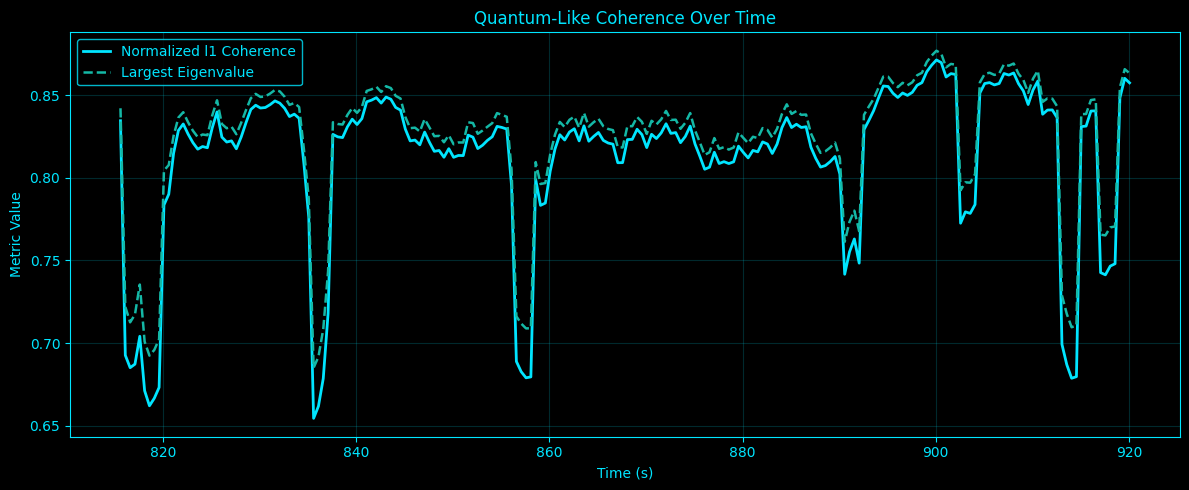

[     0.6s] Displayed plot: quantum_like_coherence_over_time.png
[     0.8s] Saved plot: quantum_like_purity_entropy_over_time.png


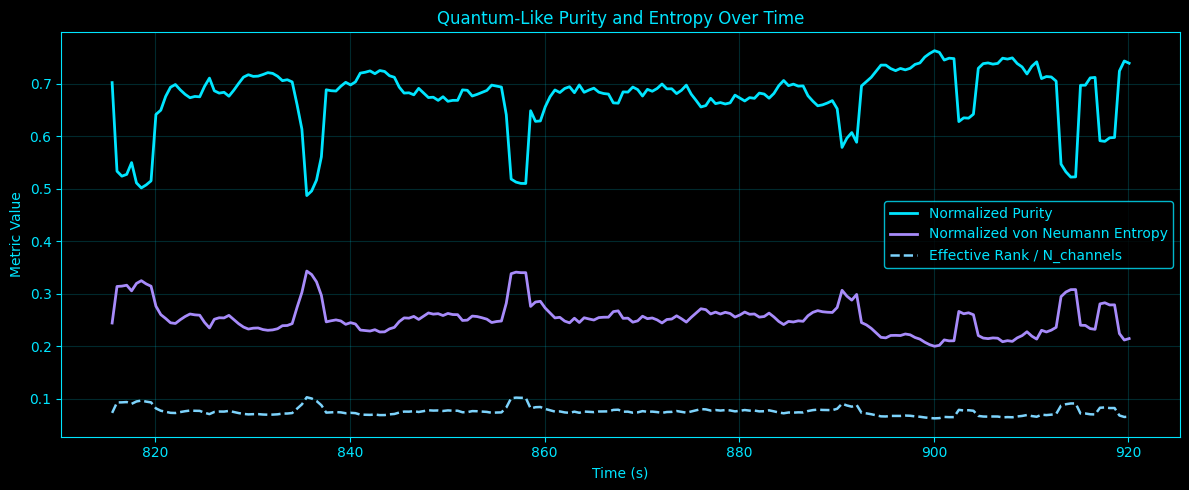

[     0.9s] Displayed plot: quantum_like_purity_entropy_over_time.png
[     1.3s] Saved plot: mean_abs_density_matrix_heatmap.png


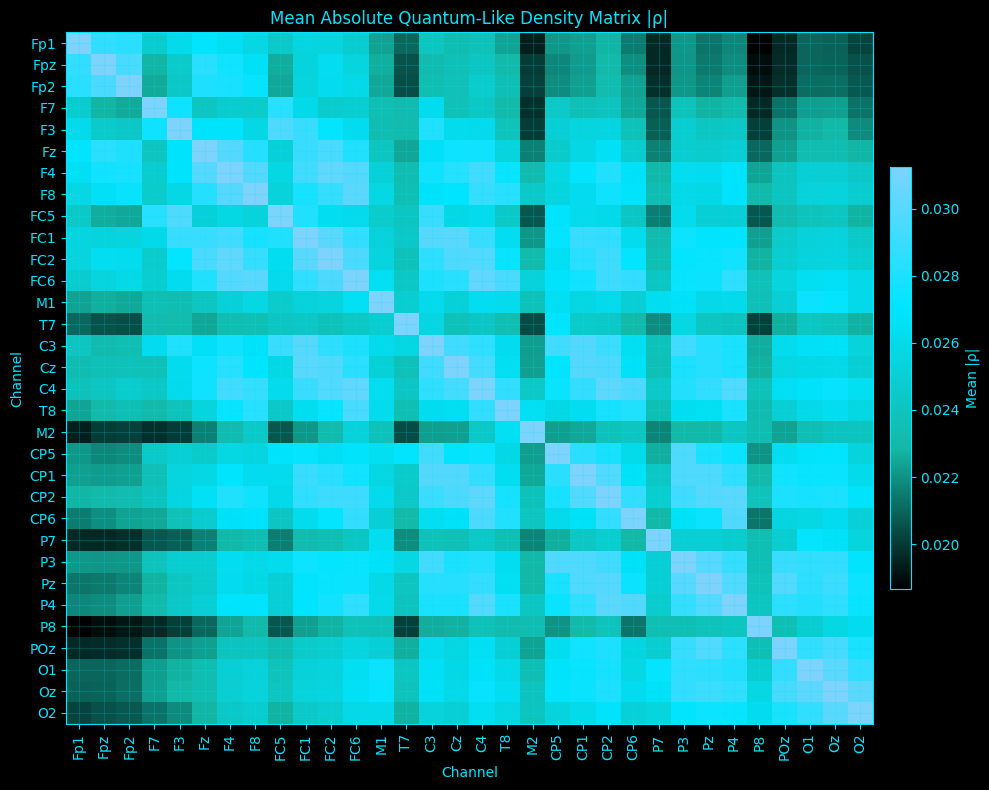

[     1.4s] Displayed plot: mean_abs_density_matrix_heatmap.png
[     1.7s] Saved plot: channel_mean_offdiag_strength.png


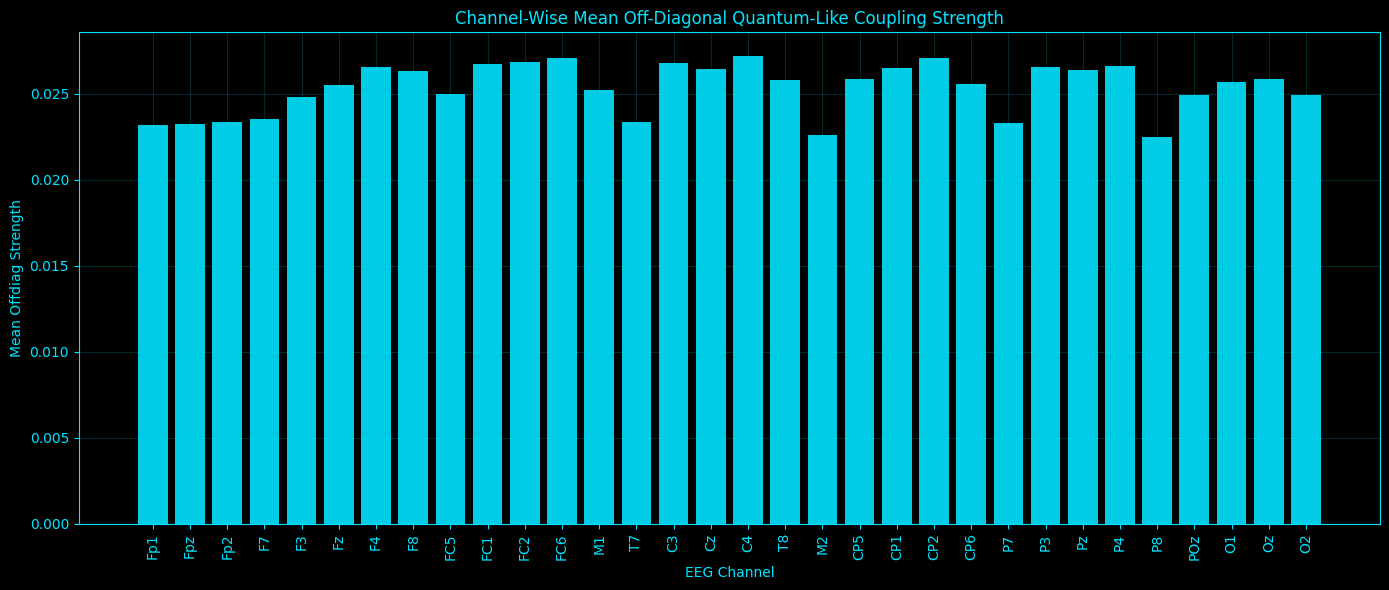

[     1.8s] Displayed plot: channel_mean_offdiag_strength.png
[     1.8s] Done.


In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = Path("/home/a/projects/Complete-Neural-Signal-Analysis")
eeg_path = base_dir / "eeg_data_with_channels.npy"

output_directory = base_dir / "quantum_like_analysis"
plots_directory = output_directory / "plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Quantum-like windowing parameters
WINDOW_SEC = 2.0
STEP_SEC = 0.5
REG_EPS = 1e-8

# Output controls
SHOW_PLOTS = True           # ALWAYS display + save
SAVE_PARTIALS = True
HEARTBEAT = True
HEARTBEAT_EVERY_WINDOWS = 10
SAVE_DENSITY_MATRICES = True

# -------------------------------------------------------
# COLOR PALETTE / STYLE
# -------------------------------------------------------
BG = "black"
ACCENT = "#00E5FF"      # axes/ticks/text/grid cyan
C_PRIMARY = "#00E5FF"   # bright cyan
C_SECONDARY = "#14B8A6" # teal
C_DIFF = "#A78BFA"      # soft violet
C_HIGHLIGHT = "#7DD3FC" # pale aqua
C_MUTED = "#67E8F9"     # light cyan

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

QUANTUM_CMAP = LinearSegmentedColormap.from_list(
    "quantum_cmap",
    [BG, C_SECONDARY, C_PRIMARY, C_HIGHLIGHT]
)

# -------------------------------------------------------
# HEARTBEAT
# -------------------------------------------------------
t0_global = time.perf_counter()

def hb(msg):
    if HEARTBEAT:
        dt = time.perf_counter() - t0_global
        print(f"[{dt:8.1f}s] {msg}", flush=True)

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    if cbar.ax.yaxis.label is not None:
        cbar.ax.yaxis.label.set_color(ACCENT)

def style_legend(legend):
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_facecolor(BG)
    frame.set_edgecolor(ACCENT)
    for text in legend.get_texts():
        text.set_color(ACCENT)

def save_and_show(fig, out_path):
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    hb(f"Saved plot: {out_path.name}")
    if SHOW_PLOTS:
        plt.show()
        hb(f"Displayed plot: {out_path.name}")
    plt.close(fig)

# -------------------------------------------------------
# DATA HELPERS
# -------------------------------------------------------
def load_eeg_segment(eeg_path, n_channels, start_index, end_index):
    hb(f"Loading EEG data from: {eeg_path}")
    eeg = np.load(eeg_path, allow_pickle=True)

    if eeg.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {eeg.shape}")

    # Handle either (time, channels) or (channels, time)
    if eeg.shape[1] == n_channels:
        segment = eeg[start_index:end_index, :]
    elif eeg.shape[0] == n_channels:
        segment = eeg[:, start_index:end_index].T
    else:
        raise ValueError(f"Unexpected EEG shape: {eeg.shape}")

    return np.asarray(segment, dtype=float)

def zscore_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, ddof=1, keepdims=True)
    return np.divide(X - mu, sd, out=np.zeros_like(X), where=sd > 1e-12)

# -------------------------------------------------------
# QUANTUM-LIKE CORE
# -------------------------------------------------------
def construct_density_matrix(window_data, reg_eps=1e-8):
    """
    Construct a quantum-like density matrix from a multichannel EEG window.

    Steps:
    1) demean + z-score each channel inside the window
    2) compute channel-channel correlation-like matrix
    3) symmetrize
    4) project away tiny negative eigenvalues caused by numerics
    5) trace-normalize to get a PSD unit-trace matrix
    """
    X = np.asarray(window_data, dtype=float)
    d = X.shape[1]

    Xz = zscore_columns(X)
    rho = (Xz.T @ Xz) / max(len(Xz) - 1, 1)

    # Hermitian / symmetric cleanup
    rho = 0.5 * (rho + rho.T)

    # small regularization for numerical stability
    rho = rho + reg_eps * np.eye(d)

    # project to PSD
    eigvals, eigvecs = np.linalg.eigh(rho)
    eigvals = np.clip(eigvals, 0.0, None)

    total = eigvals.sum()
    if total <= 0:
        return np.eye(d) / d

    rho = (eigvecs * eigvals) @ eigvecs.T
    rho = 0.5 * (rho + rho.T)
    rho = rho / np.trace(rho)

    return rho

def quantum_like_metrics(rho):
    """
    Compute quantum-like summary metrics from density matrix rho.
    """
    rho = np.asarray(rho, dtype=float)
    d = rho.shape[0]

    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.clip(np.real(eigvals), 0.0, None)
    eigvals = eigvals / (eigvals.sum() + 1e-12)

    # l1 coherence: sum of abs(off-diagonal terms)
    offdiag = rho - np.diag(np.diag(rho))
    coherence_l1 = float(np.sum(np.abs(offdiag)))
    coherence_l1_norm = coherence_l1 / (d - 1)

    # purity
    purity = float(np.trace(rho @ rho))
    purity_norm = float((d * purity - 1.0) / (d - 1.0))

    # von Neumann entropy
    entropy_vn = float(-np.sum(eigvals * np.log(eigvals + 1e-12)))
    entropy_vn_norm = float(entropy_vn / np.log(d))

    # effective rank
    effective_rank = float(np.exp(entropy_vn))

    # largest eigenvalue
    lambda_max = float(np.max(eigvals))

    return {
        "coherence_l1": coherence_l1,
        "coherence_l1_norm": coherence_l1_norm,
        "purity": purity,
        "purity_norm": purity_norm,
        "entropy_vn": entropy_vn,
        "entropy_vn_norm": entropy_vn_norm,
        "effective_rank": effective_rank,
        "lambda_max": lambda_max,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_segment = load_eeg_segment(
    eeg_path=eeg_path,
    n_channels=len(eeg_channels),
    start_index=start_index,
    end_index=end_index
)

hb(f"Loaded EEG segment: shape={EEG_segment.shape}")
hb(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec")

# -------------------------------------------------------
# WINDOW SETUP
# -------------------------------------------------------
window_size = int(WINDOW_SEC * sampling_rate)
step_size = int(STEP_SEC * sampling_rate)

if window_size <= 1:
    raise ValueError("WINDOW_SEC too small")
if step_size <= 0:
    raise ValueError("STEP_SEC too small")
if len(EEG_segment) < window_size:
    raise ValueError("EEG segment shorter than window size")

window_starts = np.arange(0, len(EEG_segment) - window_size + 1, step_size)
window_centers_sec = start_time + (window_starts + window_size / 2) / sampling_rate

hb(
    f"Windowing setup | window={WINDOW_SEC:.2f}s ({window_size} samples) | "
    f"step={STEP_SEC:.2f}s ({step_size} samples) | n_windows={len(window_starts)}"
)

# -------------------------------------------------------
# MAIN WINDOW LOOP
# -------------------------------------------------------
rows = []
rho_list = []

metrics_csv_path = output_directory / "quantum_like_window_metrics.csv"
rho_npz_path = output_directory / "quantum_like_density_matrices.npz"

for idx, start in enumerate(window_starts, start=1):
    end = start + window_size
    window = EEG_segment[start:end, :]

    rho = construct_density_matrix(window, reg_eps=REG_EPS)
    metrics = quantum_like_metrics(rho)

    rho_list.append(rho)
    rows.append({
        "window_index": idx,
        "start_sample": int(start),
        "end_sample": int(end),
        "center_time_sec": float(start_time + (start + window_size / 2) / sampling_rate),
        **metrics,
    })

    if idx == 1 or idx % HEARTBEAT_EVERY_WINDOWS == 0 or idx == len(window_starts):
        hb(
            f"Processed window {idx}/{len(window_starts)} | "
            f"t={rows[-1]['center_time_sec']:.3f}s | "
            f"C_l1_norm={metrics['coherence_l1_norm']:.5f} | "
            f"S_norm={metrics['entropy_vn_norm']:.5f}"
        )

    if SAVE_PARTIALS and (idx == 1 or idx % HEARTBEAT_EVERY_WINDOWS == 0 or idx == len(window_starts)):
        pd.DataFrame(rows).to_csv(metrics_csv_path, index=False)
        hb(f"Saved partial metrics CSV at window {idx}")

# Final save
metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(metrics_csv_path, index=False)
hb(f"Saved metrics CSV: {metrics_csv_path}")

rho_stack = np.stack(rho_list, axis=0)
mean_rho = np.mean(rho_stack, axis=0)
mean_abs_rho = np.mean(np.abs(rho_stack), axis=0)

if SAVE_DENSITY_MATRICES:
    np.savez_compressed(
        rho_npz_path,
        rho_stack=rho_stack,
        mean_rho=mean_rho,
        mean_abs_rho=mean_abs_rho,
        channel_names=np.array(eeg_channels, dtype=object)
    )
    hb(f"Saved density matrices: {rho_npz_path}")

# -------------------------------------------------------
# CHANNEL-LEVEL SUMMARY
# -------------------------------------------------------
offdiag_abs = mean_abs_rho.copy()
np.fill_diagonal(offdiag_abs, 0.0)
channel_strength = offdiag_abs.sum(axis=1) / (len(eeg_channels) - 1)

channel_strength_df = pd.DataFrame({
    "Channel": eeg_channels,
    "Mean Offdiag Strength": channel_strength
})

channel_strength_csv_path = output_directory / "quantum_like_channel_strength.csv"
channel_strength_df.to_csv(channel_strength_csv_path, index=False)
hb(f"Saved channel strength CSV: {channel_strength_csv_path}")

# -------------------------------------------------------
# PRINT SUMMARY
# -------------------------------------------------------
print("\nQuantum-like window metrics head:")
print(metrics_df.head())

print("\nTop channels by mean off-diagonal strength:")
print(
    channel_strength_df
    .sort_values("Mean Offdiag Strength", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# -------------------------------------------------------
# PLOT 1: COHERENCE + LARGEST EIGENVALUE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    metrics_df["center_time_sec"].to_numpy(),
    metrics_df["coherence_l1_norm"].to_numpy(),
    linewidth=2.0,
    color=C_PRIMARY,
    label="Normalized l1 Coherence"
)

ax.plot(
    metrics_df["center_time_sec"].to_numpy(),
    metrics_df["lambda_max"].to_numpy(),
    linewidth=1.8,
    linestyle="--",
    color=C_SECONDARY,
    label="Largest Eigenvalue"
)

ax.set_title("Quantum-Like Coherence Over Time")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Metric Value")

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "quantum_like_coherence_over_time.png")

# -------------------------------------------------------
# PLOT 2: PURITY + ENTROPY
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    metrics_df["center_time_sec"].to_numpy(),
    metrics_df["purity_norm"].to_numpy(),
    linewidth=2.0,
    color=C_PRIMARY,
    label="Normalized Purity"
)

ax.plot(
    metrics_df["center_time_sec"].to_numpy(),
    metrics_df["entropy_vn_norm"].to_numpy(),
    linewidth=2.0,
    color=C_DIFF,
    label="Normalized von Neumann Entropy"
)

ax.plot(
    metrics_df["center_time_sec"].to_numpy(),
    metrics_df["effective_rank"].to_numpy() / len(eeg_channels),
    linewidth=1.8,
    linestyle="--",
    color=C_HIGHLIGHT,
    label="Effective Rank / N_channels"
)

ax.set_title("Quantum-Like Purity and Entropy Over Time")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Metric Value")

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "quantum_like_purity_entropy_over_time.png")

# -------------------------------------------------------
# PLOT 3: MEAN |RHO| HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(mean_abs_rho, cmap=QUANTUM_CMAP, aspect="auto", interpolation="nearest")
ax.set_title("Mean Absolute Quantum-Like Density Matrix |ρ|")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(eeg_channels)))
ax.set_xticklabels(eeg_channels, rotation=90)
ax.set_yticks(np.arange(len(eeg_channels)))
ax.set_yticklabels(eeg_channels)

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Mean |ρ|", color=ACCENT)
style_colorbar(cbar)

save_and_show(fig, plots_directory / "mean_abs_density_matrix_heatmap.png")

# -------------------------------------------------------
# PLOT 4: CHANNEL-WISE MEAN OFF-DIAGONAL STRENGTH
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

ax.bar(
    channel_strength_df["Channel"],
    channel_strength_df["Mean Offdiag Strength"].to_numpy(dtype=float),
    color=C_PRIMARY,
    alpha=0.9
)

ax.set_title("Channel-Wise Mean Off-Diagonal Quantum-Like Coupling Strength")
ax.set_xlabel("EEG Channel")
ax.set_ylabel("Mean Offdiag Strength")
ax.tick_params(axis="x", rotation=90)

save_and_show(fig, plots_directory / "channel_mean_offdiag_strength.png")

hb("Done.")

[     0.0s] Starting codebook quantum-like analysis for 2D
[     0.0s] 2D loaded 1/32: Fp1 shape=(106940, 2)
[     0.0s] 2D loaded 4/32: F7 shape=(106940, 2)
[     0.1s] 2D loaded 8/32: F8 shape=(106940, 2)
[     0.1s] 2D loaded 12/32: FC6 shape=(106940, 2)
[     0.1s] 2D loaded 16/32: Cz shape=(106942, 2)
[     0.1s] 2D loaded 20/32: CP5 shape=(106941, 2)
[     0.2s] 2D loaded 24/32: P7 shape=(106942, 2)
[     0.2s] 2D loaded 28/32: P8 shape=(106940, 2)
[     0.2s] 2D loaded 32/32: O2 shape=(106940, 2)
[     0.2s] 2D common length: 106940
[     0.2s] 2D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[     0.2s] 2D fitting codebook | pool_shape=(80000, 2) | states=24
[     0.3s] 2D codebook fit complete | sigma2=0.067832
[     0.3s] 2D Fp1 window 1/52 | C=0.04593 | S=0.82491
[     0.4s] 2D Fp1 window 20/52 | C=0.02592 | S=0.91349
[     0.5s] 2D Fp1 window 40/52 | C=0.02623 | S=0.91652
[     0.5s] 2D Fp1 window 52/52 | C=0.04466 | S=0.84850
[     0.5s] 2D processed c

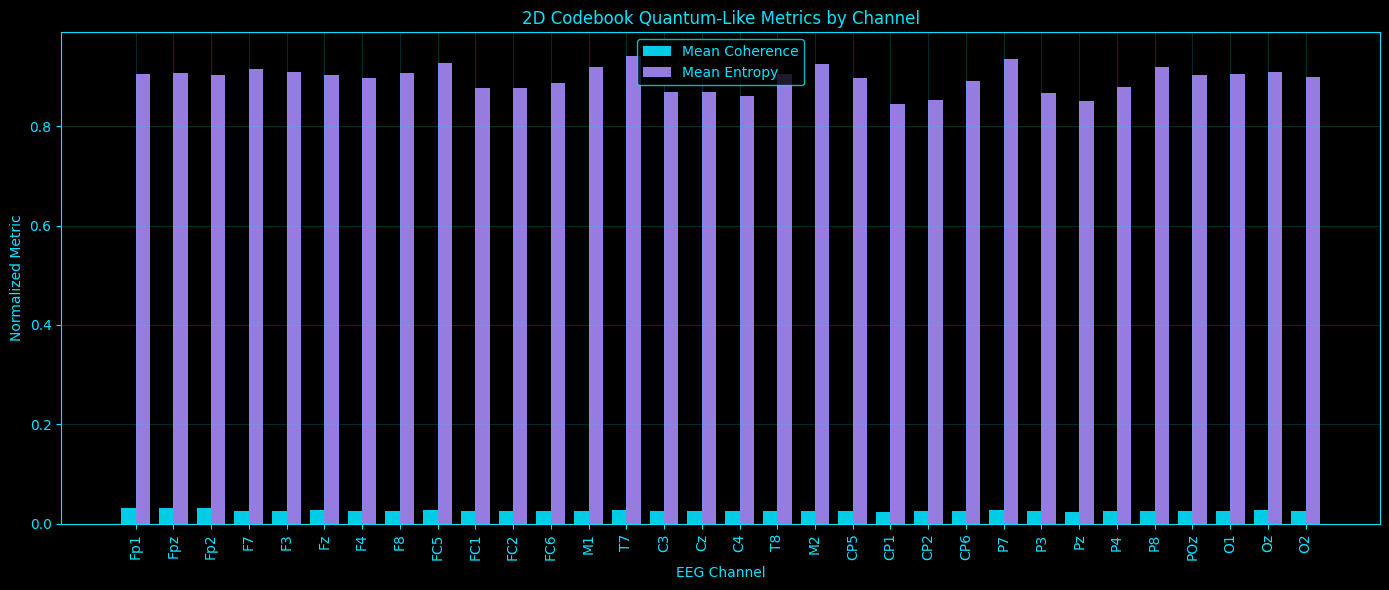

[     6.1s] Displayed plot: quantum_codebook_2d_channel_metrics.png
[     6.2s] Saved plot: quantum_codebook_2d_time_summary.png


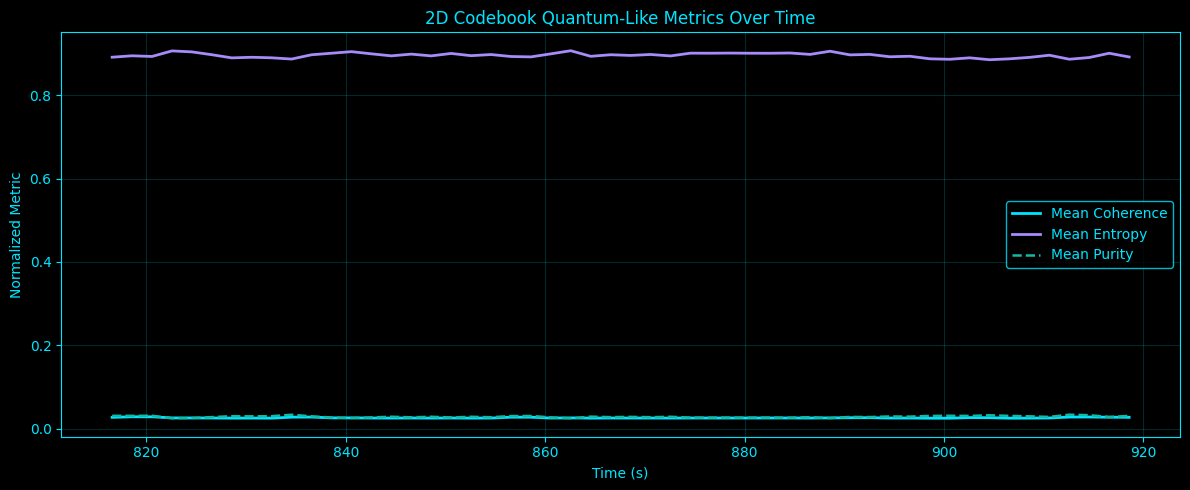

[     6.3s] Displayed plot: quantum_codebook_2d_time_summary.png
[     6.7s] Saved plot: quantum_codebook_2d_fidelity_heatmap.png


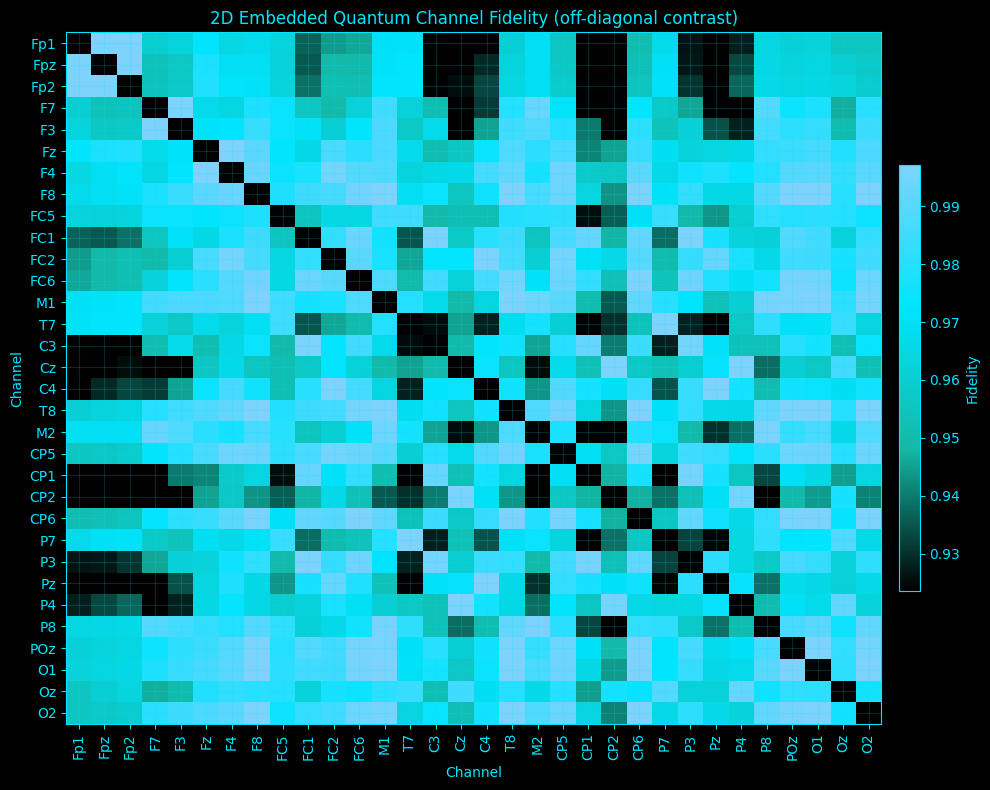

[     6.8s] Displayed plot: quantum_codebook_2d_fidelity_heatmap.png
[     6.8s] Starting codebook quantum-like analysis for 3D
[     6.8s] 3D loaded 1/32: Fp1 shape=(106936, 3)
[     6.9s] 3D loaded 4/32: F7 shape=(106936, 3)
[     6.9s] 3D loaded 8/32: F8 shape=(106936, 3)
[     6.9s] 3D loaded 12/32: FC6 shape=(106936, 3)
[     6.9s] 3D loaded 16/32: Cz shape=(106940, 3)
[     7.0s] 3D loaded 20/32: CP5 shape=(106938, 3)
[     7.0s] 3D loaded 24/32: P7 shape=(106940, 3)
[     7.0s] 3D loaded 28/32: P8 shape=(106936, 3)
[     7.0s] 3D loaded 32/32: O2 shape=(106936, 3)
[     7.0s] 3D common length: 106936
[     7.0s] 3D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[     7.1s] 3D fitting codebook | pool_shape=(80000, 3) | states=24
[     7.2s] 3D codebook fit complete | sigma2=0.214393
[     7.2s] 3D Fp1 window 1/52 | C=0.08680 | S=0.77715
[     7.2s] 3D Fp1 window 20/52 | C=0.04729 | S=0.85925
[     7.3s] 3D Fp1 window 40/52 | C=0.04757 | S=0.86054
[     7.3s] 3

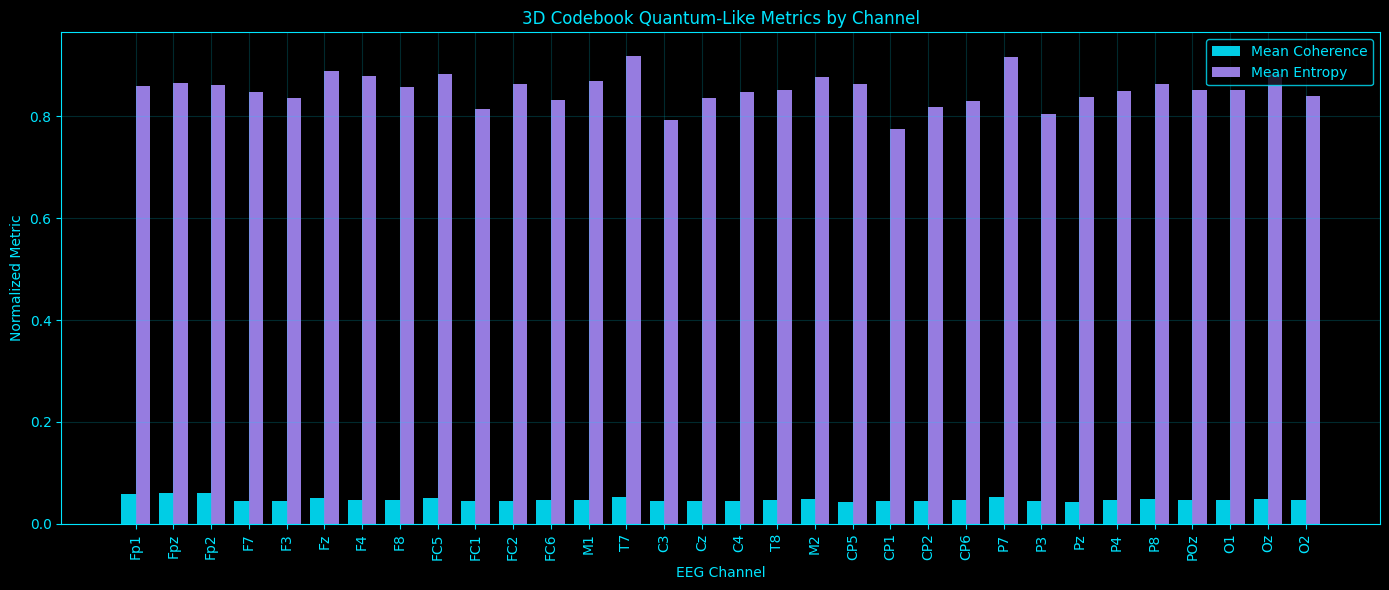

[    13.1s] Displayed plot: quantum_codebook_3d_channel_metrics.png
[    13.3s] Saved plot: quantum_codebook_3d_time_summary.png


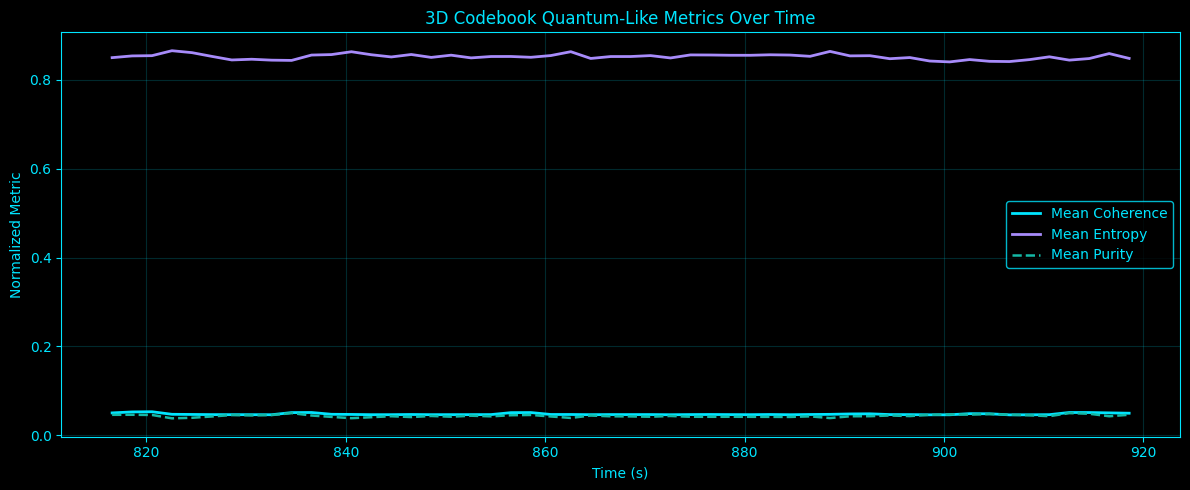

[    13.3s] Displayed plot: quantum_codebook_3d_time_summary.png
[    13.7s] Saved plot: quantum_codebook_3d_fidelity_heatmap.png


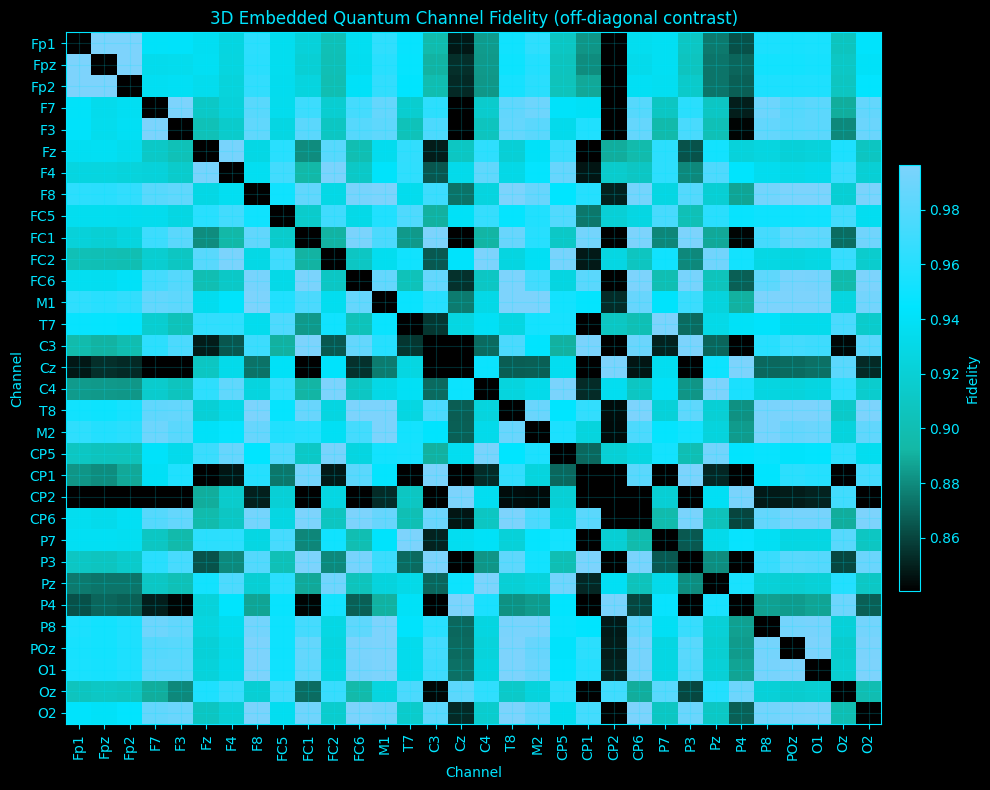

[    13.8s] Displayed plot: quantum_codebook_3d_fidelity_heatmap.png
[    13.8s] Starting codebook quantum-like analysis for 4D
[    13.9s] 4D loaded 1/32: Fp1 shape=(106932, 4)
[    14.0s] 4D loaded 4/32: F7 shape=(106932, 4)
[    14.1s] 4D loaded 8/32: F8 shape=(106932, 4)
[    14.2s] 4D loaded 12/32: FC6 shape=(106932, 4)
[    14.4s] 4D loaded 16/32: Cz shape=(106938, 4)
[    14.6s] 4D loaded 20/32: CP5 shape=(106935, 4)
[    14.7s] 4D loaded 24/32: P7 shape=(106938, 4)
[    14.9s] 4D loaded 28/32: P8 shape=(106932, 4)
[    15.0s] 4D loaded 32/32: O2 shape=(106932, 4)
[    15.0s] 4D common length: 106932
[    15.0s] 4D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[    15.0s] 4D fitting codebook | pool_shape=(80000, 4) | states=32
[    15.2s] 4D codebook fit complete | sigma2=0.346378
[    15.2s] 4D Fp1 window 1/52 | C=0.10403 | S=0.77838
[    15.3s] 4D Fp1 window 20/52 | C=0.05250 | S=0.82875
[    15.4s] 4D Fp1 window 40/52 | C=0.05301 | S=0.82720
[    15.4s] 4

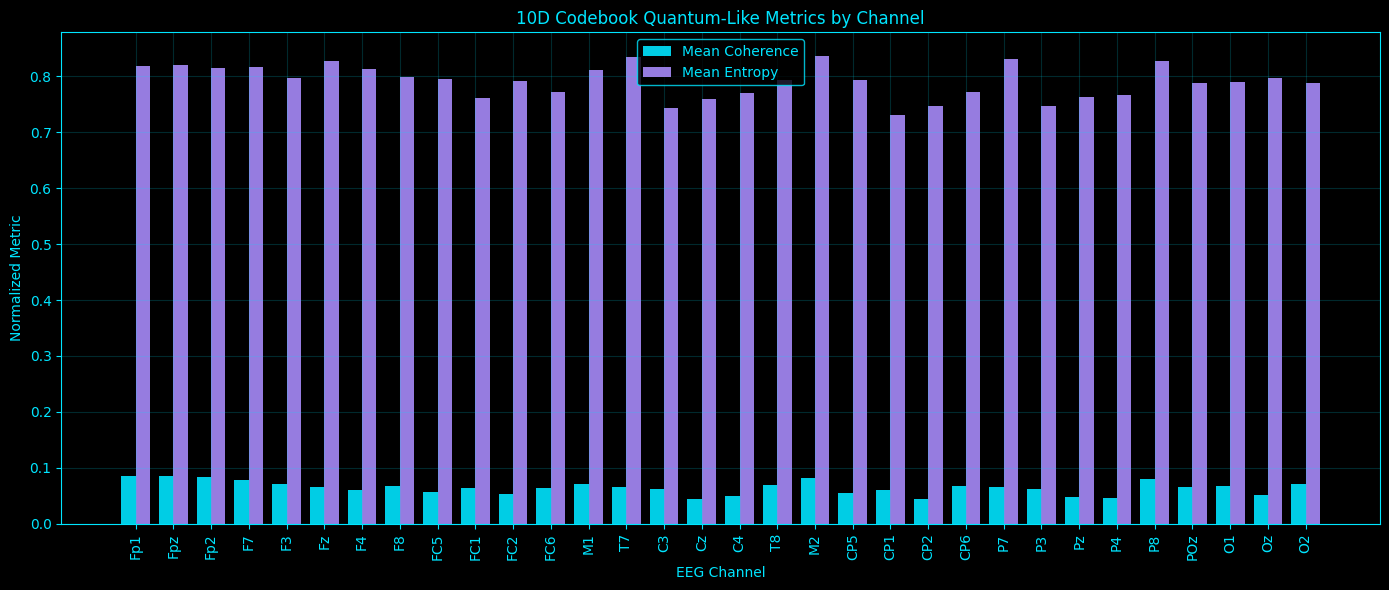

[   115.1s] Displayed plot: quantum_codebook_10d_channel_metrics.png
[   115.3s] Saved plot: quantum_codebook_10d_time_summary.png


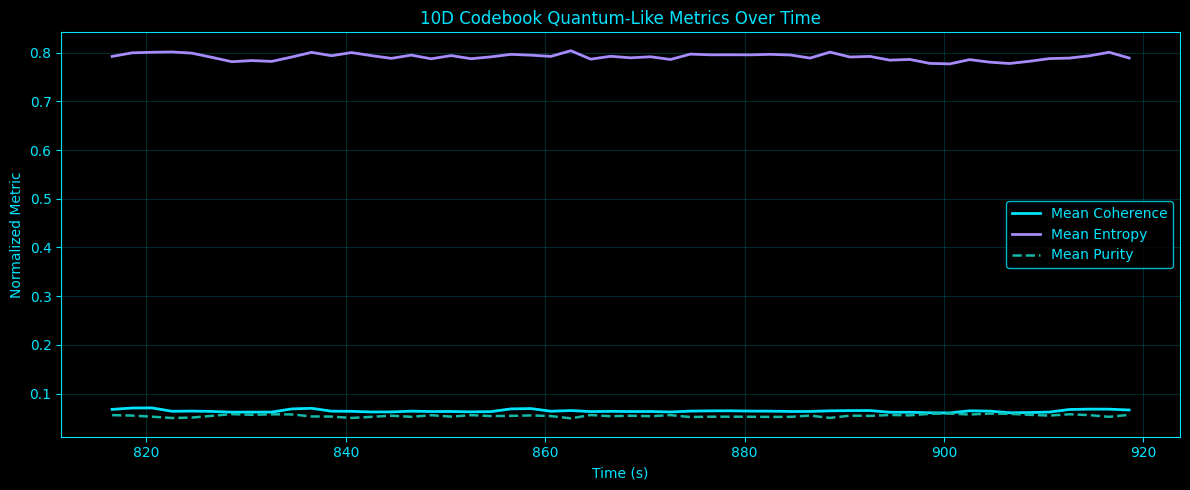

[   115.4s] Displayed plot: quantum_codebook_10d_time_summary.png
[   115.7s] Saved plot: quantum_codebook_10d_fidelity_heatmap.png


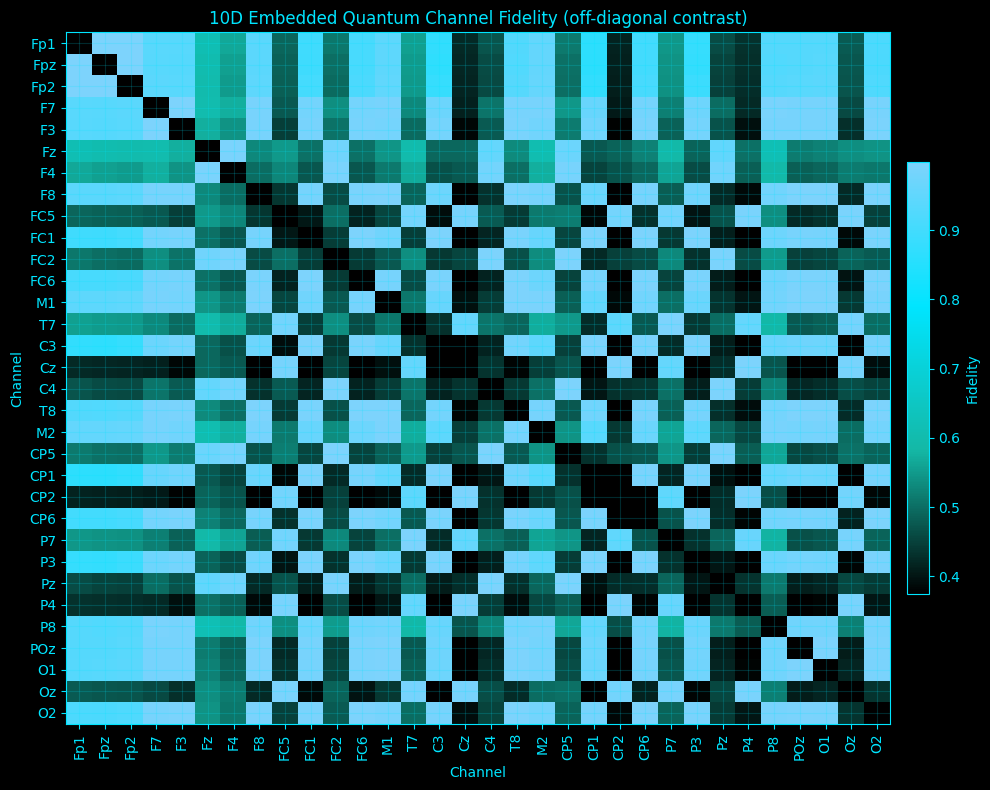

[   115.9s] Displayed plot: quantum_codebook_10d_fidelity_heatmap.png
[   115.9s] Saved cross-dim comparison CSV: quantum_codebook_dim_comparison.csv

Cross-dimension comparison:
   embedding_dim  n_states    sigma2  mean_channel_coherence  \
0              2        24  0.067832                0.026447   
1              3        24  0.214393                0.047826   
2              4        32  0.346378                0.051480   
3              5        32  0.497053                0.059027   
4              6        40  0.621898                0.058187   
5              7        40  0.841646                0.067622   
6              8        48  0.967515                0.059309   
7              9        48  1.133593                0.068469   
8             10        56  1.266609                0.064408   

   mean_channel_entropy  mean_channel_purity  mean_channel_lambda_max  \
0              0.895320             0.029027                 0.118388   
1              0.852189           

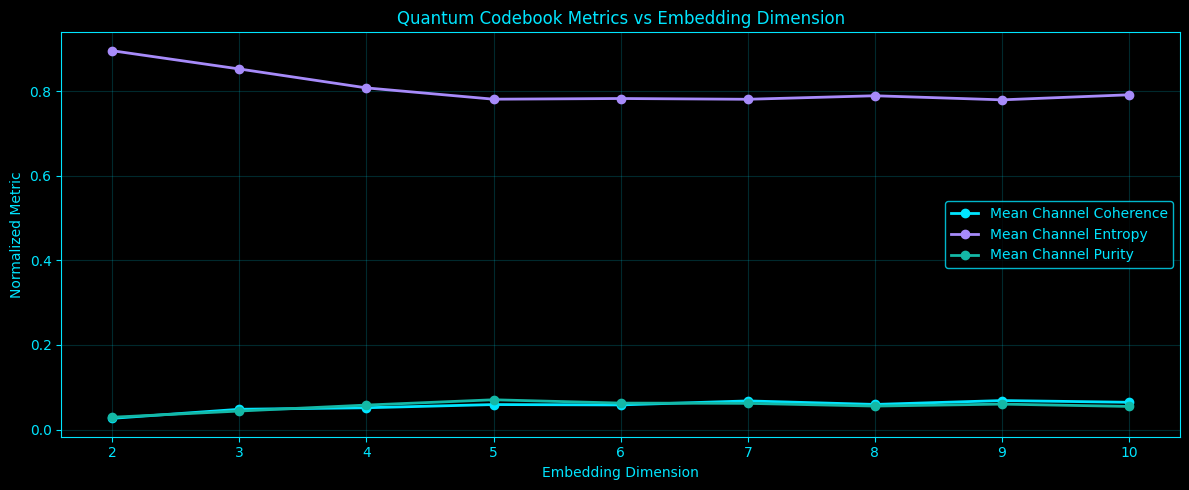

[   116.1s] Displayed plot: quantum_codebook_metrics_vs_dim.png
[   116.2s] Saved plot: quantum_codebook_fidelity_vs_dim.png


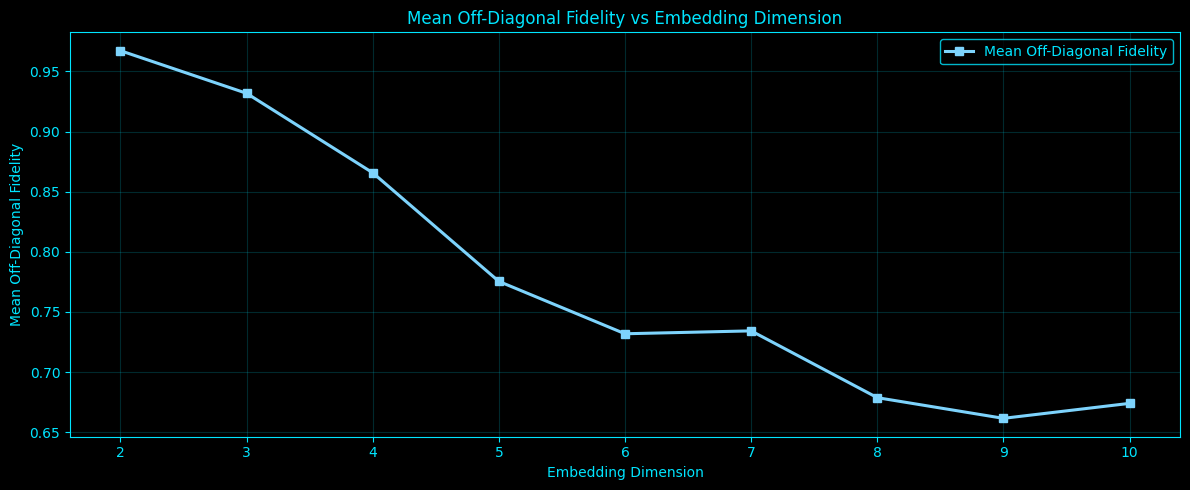

[   116.3s] Displayed plot: quantum_codebook_fidelity_vs_dim.png
[   116.3s] Done.


In [4]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.cluster import MiniBatchKMeans

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = Path("/home/a/projects/Complete-Neural-Signal-Analysis")

embedding_dirs = {
    2: base_dir / "embedding_data" / "2dembedding_data",
    3: base_dir / "embedding_data" / "3dembedding_data",
}
for d in range(4, 11):
    embedding_dirs[d] = base_dir / "embedding_data" / "embeddings_4to10"

output_directory = base_dir / "quantum_like_codebook_analysis"
plots_directory = output_directory / "plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Same EEG segment reference as your embedding scripts
sampling_rate = 1000
start_time, end_time = 814.571, 921.515

# Which embeddings to analyze
EMBEDDING_DIMS = list(range(2, 11))   # 2..10 inclusive

# Windowing in embedded-point index space
WINDOW_SEC = 4.0
STEP_SEC = 2.0

# Codebook / soft-state settings
CODEBOOK_SIZE_MAP = {
    2: 24,
    3: 24,
    4: 32,
    5: 32,
    6: 40,
    7: 40,
    8: 48,
    9: 48,
    10: 56,
}
FIT_SAMPLES_PER_CHANNEL = 2500
ALPHA_SMOOTH = 1e-3
USE_SOFT_ASSIGNMENT = True
SOFT_BETA_SCALE = 1.0   # larger -> sharper assignments

# Runtime controls
SHOW_PLOTS = True                    # ALWAYS save + display
SAVE_PARTIALS = True
HEARTBEAT = True
HEARTBEAT_EVERY_CHANNELS = 4
HEARTBEAT_EVERY_WINDOWS = 20
RANDOM_SEED = 0

# Plot only these dims for the heavier per-dim plots while still analyzing all dims
PLOT_DIMS = [2, 3, 10]

# -------------------------------------------------------
# COLOR PALETTE / STYLE
# -------------------------------------------------------
BG = "black"
ACCENT = "#00E5FF"
C_PRIMARY = "#00E5FF"
C_SECONDARY = "#14B8A6"
C_DIFF = "#A78BFA"
C_HIGHLIGHT = "#7DD3FC"
C_MUTED = "#67E8F9"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

QUANTUM_CMAP = LinearSegmentedColormap.from_list(
    "quantum_cmap",
    [BG, C_SECONDARY, C_PRIMARY, C_HIGHLIGHT]
)

# -------------------------------------------------------
# HEARTBEAT
# -------------------------------------------------------
rng = np.random.default_rng(RANDOM_SEED)
t0_global = time.perf_counter()

def hb(msg):
    if HEARTBEAT:
        dt = time.perf_counter() - t0_global
        print(f"[{dt:8.1f}s] {msg}", flush=True)

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    if cbar.ax.yaxis.label is not None:
        cbar.ax.yaxis.label.set_color(ACCENT)

def style_legend(legend):
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_facecolor(BG)
    frame.set_edgecolor(ACCENT)
    for text in legend.get_texts():
        text.set_color(ACCENT)

def save_and_show(fig, out_path):
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    hb(f"Saved plot: {out_path.name}")
    if SHOW_PLOTS:
        plt.show()
        hb(f"Displayed plot: {out_path.name}")
    plt.close(fig)

# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def load_embedded_channel(channel_name, emb_dim):
    emb_dir = embedding_dirs[emb_dim]

    if emb_dim == 2:
        candidates = [
            emb_dir / f"2dembedded_{channel_name}.npy",
            emb_dir / f"2dembedded_{channel_name}_data.npy",
        ]
    elif emb_dim == 3:
        candidates = [
            emb_dir / f"3dembedded_{channel_name}.npy",
            emb_dir / f"3dembedded_{channel_name}_data.npy",
        ]
    else:
        candidates = [
            emb_dir / f"{emb_dim}dembedded_{channel_name}.npy",
            emb_dir / f"{emb_dim}dembedded_{channel_name}_data.npy",
        ]

    for path in candidates:
        if path.exists():
            arr = np.load(path)
            arr = np.asarray(arr, dtype=float)
            if arr.ndim != 2 or arr.shape[1] != emb_dim:
                raise ValueError(f"{path.name} has shape {arr.shape}, expected (N, {emb_dim})")
            return arr

    raise FileNotFoundError(f"No embedding file found for channel {channel_name}, dim={emb_dim}")

# -------------------------------------------------------
# NUMERIC HELPERS
# -------------------------------------------------------
def zscore_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, ddof=1, keepdims=True)
    return np.divide(X - mu, sd, out=np.zeros_like(X), where=sd > 1e-12)

def sqrtm_psd(A):
    A = 0.5 * (A + A.T)
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals = np.clip(eigvals, 0.0, None)
    return (eigvecs * np.sqrt(eigvals)) @ eigvecs.T

def quantum_fidelity(rho, sigma):
    sr = sqrtm_psd(rho)
    middle = sr @ sigma @ sr
    sm = sqrtm_psd(middle)
    val = float(np.real(np.trace(sm)) ** 2)
    return max(0.0, min(1.0 + 1e-10, val))

def quantum_metrics(rho):
    rho = np.asarray(rho, dtype=float)
    d = rho.shape[0]

    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.clip(np.real(eigvals), 0.0, None)
    eigvals = eigvals / (eigvals.sum() + 1e-12)

    offdiag = rho - np.diag(np.diag(rho))
    coherence_l1 = float(np.sum(np.abs(offdiag)))
    coherence_l1_norm = float(coherence_l1 / (d - 1))

    purity = float(np.trace(rho @ rho))
    purity_norm = float((d * purity - 1.0) / (d - 1.0))

    entropy_vn = float(-np.sum(eigvals * np.log(eigvals + 1e-12)))
    entropy_vn_norm = float(entropy_vn / np.log(d))

    effective_rank = float(np.exp(entropy_vn))
    lambda_max = float(np.max(eigvals))

    return {
        "coherence_l1": coherence_l1,
        "coherence_l1_norm": coherence_l1_norm,
        "purity": purity,
        "purity_norm": purity_norm,
        "entropy_vn": entropy_vn,
        "entropy_vn_norm": entropy_vn_norm,
        "effective_rank": effective_rank,
        "lambda_max": lambda_max,
    }

# -------------------------------------------------------
# CODEBOOK QUANTUM STATE
# -------------------------------------------------------
def fit_shared_codebook(X_pool, n_states, random_state=0):
    """
    Shared codebook basis for one embedding dimension.
    """
    model = MiniBatchKMeans(
        n_clusters=n_states,
        random_state=random_state,
        batch_size=min(4096, max(256, n_states * 16)),
        n_init=10,
        max_iter=300
    )
    model.fit(X_pool)
    centers = np.asarray(model.cluster_centers_, dtype=float)

    # Estimate softness scale from training data -> assigned center distances
    labels = model.predict(X_pool)
    dist2 = np.sum((X_pool - centers[labels]) ** 2, axis=1)
    sigma2 = float(np.median(dist2) + 1e-12)

    return centers, sigma2

def soft_assignments(X, centers, sigma2, beta_scale=1.0):
    """
    Soft assignment of points to codebook states.
    """
    X = np.asarray(X, dtype=float)
    centers = np.asarray(centers, dtype=float)

    diff = X[:, None, :] - centers[None, :, :]
    dist2 = np.sum(diff * diff, axis=2)

    if USE_SOFT_ASSIGNMENT:
        logits = -dist2 / (2.0 * sigma2 * beta_scale + 1e-12)
        logits = logits - np.max(logits, axis=1, keepdims=True)
        A = np.exp(logits)
        A = A / (A.sum(axis=1, keepdims=True) + 1e-12)
    else:
        idx = np.argmin(dist2, axis=1)
        A = np.zeros((len(X), len(centers)), dtype=float)
        A[np.arange(len(X)), idx] = 1.0

    return A

def codebook_density_matrix(window_points, centers, sigma2, alpha=1e-3, beta_scale=1.0):
    """
    Quantum-like density matrix from soft state occupancy in a shared codebook basis.

    rho = (A^T A + alpha I) / trace(...)
    where A is the soft assignment matrix.
    """
    X = zscore_columns(window_points)
    A = soft_assignments(X, centers, sigma2=sigma2, beta_scale=beta_scale)

    rho = (A.T @ A) / max(len(A), 1)
    rho = rho + alpha * np.eye(rho.shape[0])
    rho = 0.5 * (rho + rho.T)
    rho = rho / np.trace(rho)

    return rho

# -------------------------------------------------------
# MAIN ANALYSIS FOR ONE EMBEDDING DIMENSION
# -------------------------------------------------------
def run_dim_analysis(emb_dim):
    hb(f"Starting codebook quantum-like analysis for {emb_dim}D")

    # -----------------------------
    # Load and standardize all channels
    # -----------------------------
    embedded = {}
    for idx, ch in enumerate(eeg_channels, start=1):
        X = load_embedded_channel(ch, emb_dim)
        embedded[ch] = zscore_columns(X)

        if idx == 1 or idx % HEARTBEAT_EVERY_CHANNELS == 0 or idx == len(eeg_channels):
            hb(f"{emb_dim}D loaded {idx}/{len(eeg_channels)}: {ch} shape={embedded[ch].shape}")

    common_length = min(len(embedded[ch]) for ch in eeg_channels)
    hb(f"{emb_dim}D common length: {common_length}")

    for ch in eeg_channels:
        embedded[ch] = embedded[ch][:common_length]

    window_size = int(WINDOW_SEC * sampling_rate)
    step_size = int(STEP_SEC * sampling_rate)

    if common_length < window_size:
        raise ValueError(f"{emb_dim}D embeddings shorter than window size")

    window_starts = np.arange(0, common_length - window_size + 1, step_size)
    hb(
        f"{emb_dim}D windowing | window={WINDOW_SEC:.2f}s ({window_size}) | "
        f"step={STEP_SEC:.2f}s ({step_size}) | n_windows={len(window_starts)}"
    )

    # -----------------------------
    # Fit shared codebook for this embedding dimension
    # -----------------------------
    n_states = CODEBOOK_SIZE_MAP[emb_dim]
    pool = []

    for ch in eeg_channels:
        X = embedded[ch]
        n = len(X)
        if n <= FIT_SAMPLES_PER_CHANNEL:
            pool.append(X)
        else:
            idx = np.sort(rng.choice(n, size=FIT_SAMPLES_PER_CHANNEL, replace=False))
            pool.append(X[idx])

    X_pool = np.vstack(pool)
    hb(f"{emb_dim}D fitting codebook | pool_shape={X_pool.shape} | states={n_states}")

    centers, sigma2 = fit_shared_codebook(
        X_pool,
        n_states=n_states,
        random_state=RANDOM_SEED + emb_dim
    )
    hb(f"{emb_dim}D codebook fit complete | sigma2={sigma2:.6f}")

    # Save codebook
    codebook_npz_path = output_directory / f"codebook_{emb_dim}d.npz"
    np.savez_compressed(
        codebook_npz_path,
        centers=centers,
        sigma2=sigma2
    )

    # -----------------------------
    # Window loop by channel
    # -----------------------------
    rows = []
    per_channel_rhos = {ch: [] for ch in eeg_channels}

    metrics_csv_path = output_directory / f"quantum_codebook_{emb_dim}d_window_metrics.csv"
    channel_summary_csv_path = output_directory / f"quantum_codebook_{emb_dim}d_channel_summary.csv"
    fidelity_csv_path = output_directory / f"quantum_codebook_{emb_dim}d_fidelity.csv"

    for ch_idx, ch in enumerate(eeg_channels, start=1):
        X = embedded[ch]

        for w_idx, start in enumerate(window_starts, start=1):
            end = start + window_size
            Xw = X[start:end]

            rho = codebook_density_matrix(
                Xw,
                centers=centers,
                sigma2=sigma2,
                alpha=ALPHA_SMOOTH,
                beta_scale=SOFT_BETA_SCALE
            )
            per_channel_rhos[ch].append(rho)

            metrics = quantum_metrics(rho)
            rows.append({
                "embedding_dim": emb_dim,
                "channel": ch,
                "window_index": w_idx,
                "start_sample": int(start),
                "end_sample": int(end),
                "center_time_sec": float(start_time + (start + window_size / 2) / sampling_rate),
                "n_states": n_states,
                "sigma2": sigma2,
                **metrics,
            })

            if w_idx == 1 or w_idx % HEARTBEAT_EVERY_WINDOWS == 0 or w_idx == len(window_starts):
                if ch_idx == 1:
                    hb(
                        f"{emb_dim}D {ch} window {w_idx}/{len(window_starts)} | "
                        f"C={metrics['coherence_l1_norm']:.5f} | "
                        f"S={metrics['entropy_vn_norm']:.5f}"
                    )

        if ch_idx == 1 or ch_idx % HEARTBEAT_EVERY_CHANNELS == 0 or ch_idx == len(eeg_channels):
            hb(f"{emb_dim}D processed channel {ch_idx}/{len(eeg_channels)}: {ch}")
            if SAVE_PARTIALS:
                pd.DataFrame(rows).to_csv(metrics_csv_path, index=False)
                hb(f"{emb_dim}D partial CSV saved after {ch}")

    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(metrics_csv_path, index=False)
    hb(f"{emb_dim}D metrics CSV saved: {metrics_csv_path.name}")

    # -----------------------------
    # Channel mean rho
    # -----------------------------
    mean_rhos = {
        ch: np.mean(np.stack(per_channel_rhos[ch], axis=0), axis=0)
        for ch in eeg_channels
    }

    # -----------------------------
    # Channel summary
    # -----------------------------
    channel_summary_df = (
        metrics_df
        .groupby("channel", as_index=False)[
            ["coherence_l1_norm", "purity_norm", "entropy_vn_norm", "effective_rank", "lambda_max"]
        ]
        .mean()
    )
    channel_summary_df["channel"] = pd.Categorical(
        channel_summary_df["channel"],
        categories=eeg_channels,
        ordered=True
    )
    channel_summary_df = channel_summary_df.sort_values("channel").reset_index(drop=True)
    channel_summary_df.to_csv(channel_summary_csv_path, index=False)

    # -----------------------------
    # Fidelity matrix
    # -----------------------------
    fidelity = np.zeros((len(eeg_channels), len(eeg_channels)), dtype=float)
    for i, ch_i in enumerate(eeg_channels):
        for j, ch_j in enumerate(eeg_channels):
            fidelity[i, j] = quantum_fidelity(mean_rhos[ch_i], mean_rhos[ch_j])

    fidelity_df = pd.DataFrame(fidelity, index=eeg_channels, columns=eeg_channels)
    fidelity_df.to_csv(fidelity_csv_path)

    # Mean off-diagonal fidelity
    F_off = fidelity.copy()
    np.fill_diagonal(F_off, np.nan)
    mean_offdiag_fidelity = float(np.nanmean(F_off))

    # -----------------------------
    # Time summary across channels
    # -----------------------------
    time_summary_df = (
        metrics_df
        .groupby("center_time_sec", as_index=False)[
            ["coherence_l1_norm", "purity_norm", "entropy_vn_norm", "effective_rank", "lambda_max"]
        ]
        .mean()
    )

    # -----------------------------
    # Print quick summary
    # -----------------------------
    print(f"\n{emb_dim}D summary head:")
    print(channel_summary_df.head())

    print(f"\n{emb_dim}D top channels by coherence:")
    print(
        channel_summary_df[["channel", "coherence_l1_norm"]]
        .sort_values("coherence_l1_norm", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    # -----------------------------
    # Plots
    # -----------------------------
    if emb_dim in PLOT_DIMS:
        # 1) Channel metrics
        fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
        style_ax(ax)

        x = np.arange(len(eeg_channels))
        width = 0.38

        ax.bar(
            x - width / 2,
            channel_summary_df["coherence_l1_norm"].to_numpy(dtype=float),
            width=width,
            color=C_PRIMARY,
            alpha=0.90,
            label="Mean Coherence"
        )
        ax.bar(
            x + width / 2,
            channel_summary_df["entropy_vn_norm"].to_numpy(dtype=float),
            width=width,
            color=C_DIFF,
            alpha=0.90,
            label="Mean Entropy"
        )

        ax.set_title(f"{emb_dim}D Codebook Quantum-Like Metrics by Channel")
        ax.set_xlabel("EEG Channel")
        ax.set_ylabel("Normalized Metric")
        ax.set_xticks(x)
        ax.set_xticklabels(eeg_channels, rotation=90)

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"quantum_codebook_{emb_dim}d_channel_metrics.png")

        # 2) Mean metrics over time
        fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
        style_ax(ax)

        ax.plot(
            time_summary_df["center_time_sec"].to_numpy(),
            time_summary_df["coherence_l1_norm"].to_numpy(),
            linewidth=2.0,
            color=C_PRIMARY,
            label="Mean Coherence"
        )
        ax.plot(
            time_summary_df["center_time_sec"].to_numpy(),
            time_summary_df["entropy_vn_norm"].to_numpy(),
            linewidth=2.0,
            color=C_DIFF,
            label="Mean Entropy"
        )
        ax.plot(
            time_summary_df["center_time_sec"].to_numpy(),
            time_summary_df["purity_norm"].to_numpy(),
            linewidth=1.8,
            linestyle="--",
            color=C_SECONDARY,
            label="Mean Purity"
        )

        ax.set_title(f"{emb_dim}D Codebook Quantum-Like Metrics Over Time")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Normalized Metric")

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"quantum_codebook_{emb_dim}d_time_summary.png")

        # 3) Fidelity heatmap with diagonal masked and off-diagonal contrast
        F_plot = fidelity.copy()
        np.fill_diagonal(F_plot, np.nan)
        vmin = float(np.nanpercentile(F_plot, 5))
        vmax = float(np.nanpercentile(F_plot, 95))

        fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
        style_ax(ax)

        im = ax.imshow(
            F_plot,
            cmap=QUANTUM_CMAP,
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(f"{emb_dim}D Embedded Quantum Channel Fidelity (off-diagonal contrast)")
        ax.set_xlabel("Channel")
        ax.set_ylabel("Channel")
        ax.set_xticks(np.arange(len(eeg_channels)))
        ax.set_xticklabels(eeg_channels, rotation=90)
        ax.set_yticks(np.arange(len(eeg_channels)))
        ax.set_yticklabels(eeg_channels)

        cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
        cbar.set_label("Fidelity", color=ACCENT)
        style_colorbar(cbar)

        save_and_show(fig, plots_directory / f"quantum_codebook_{emb_dim}d_fidelity_heatmap.png")

    return {
        "emb_dim": emb_dim,
        "n_states": n_states,
        "sigma2": sigma2,
        "metrics_df": metrics_df,
        "channel_summary_df": channel_summary_df,
        "time_summary_df": time_summary_df,
        "fidelity_df": fidelity_df,
        "mean_offdiag_fidelity": mean_offdiag_fidelity,
    }

# -------------------------------------------------------
# RUN ALL EMBEDDING DIMS
# -------------------------------------------------------
all_results = {}
comparison_rows = []

for emb_dim in EMBEDDING_DIMS:
    res = run_dim_analysis(emb_dim)
    all_results[emb_dim] = res

    summary = res["channel_summary_df"]
    comparison_rows.append({
        "embedding_dim": emb_dim,
        "n_states": res["n_states"],
        "sigma2": res["sigma2"],
        "mean_channel_coherence": float(summary["coherence_l1_norm"].mean()),
        "mean_channel_entropy": float(summary["entropy_vn_norm"].mean()),
        "mean_channel_purity": float(summary["purity_norm"].mean()),
        "mean_channel_lambda_max": float(summary["lambda_max"].mean()),
        "mean_offdiag_fidelity": float(res["mean_offdiag_fidelity"]),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("embedding_dim").reset_index(drop=True)
comparison_csv_path = output_directory / "quantum_codebook_dim_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
hb(f"Saved cross-dim comparison CSV: {comparison_csv_path.name}")

print("\nCross-dimension comparison:")
print(comparison_df)

# -------------------------------------------------------
# CROSS-DIM PLOTS
# -------------------------------------------------------
# 1) Mean coherence / entropy / purity across embedding dimension
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

x = comparison_df["embedding_dim"].to_numpy()

ax.plot(
    x,
    comparison_df["mean_channel_coherence"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_PRIMARY,
    label="Mean Channel Coherence"
)
ax.plot(
    x,
    comparison_df["mean_channel_entropy"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_DIFF,
    label="Mean Channel Entropy"
)
ax.plot(
    x,
    comparison_df["mean_channel_purity"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_SECONDARY,
    label="Mean Channel Purity"
)

ax.set_title("Quantum Codebook Metrics vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Normalized Metric")
ax.set_xticks(x)

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "quantum_codebook_metrics_vs_dim.png")

# 2) Mean off-diagonal fidelity vs embedding dimension
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    comparison_df["mean_offdiag_fidelity"].to_numpy(),
    linewidth=2.2,
    marker="s",
    color=C_HIGHLIGHT,
    label="Mean Off-Diagonal Fidelity"
)

ax.set_title("Mean Off-Diagonal Fidelity vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Mean Off-Diagonal Fidelity")
ax.set_xticks(x)

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "quantum_codebook_fidelity_vs_dim.png")

hb("Done.")

[     0.0s] Starting advanced operator analysis for 2D
[     0.0s] 2D loaded 1/32: Fp1 shape=(106940, 2)
[     0.0s] 2D loaded 4/32: F7 shape=(106940, 2)
[     0.1s] 2D loaded 8/32: F8 shape=(106940, 2)
[     0.1s] 2D loaded 12/32: FC6 shape=(106940, 2)
[     0.1s] 2D loaded 16/32: Cz shape=(106942, 2)
[     0.1s] 2D loaded 20/32: CP5 shape=(106941, 2)
[     0.2s] 2D loaded 24/32: P7 shape=(106942, 2)
[     0.2s] 2D loaded 28/32: P8 shape=(106940, 2)
[     0.2s] 2D loaded 32/32: O2 shape=(106940, 2)
[     0.2s] 2D common length across channels: 106940
[     0.2s] 2D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[     0.2s] 2D fitting codebook | pool_shape=(80000, 2) | states=24
[     0.3s] 2D codebook fit complete | sigma2=0.067832
[     0.3s] 2D Hamiltonian built | graph_sigma=1.823255
[     0.3s] 2D Fp1 window 1/52 | gap=0.12988 | PR=9.344 | E=0.93472
[     0.3s] 2D Fp1 window 20/52 | gap=0.00859 | PR=15.830 | E=0.96176
[     0.4s] 2D Fp1 window 40/52 | gap=0.006

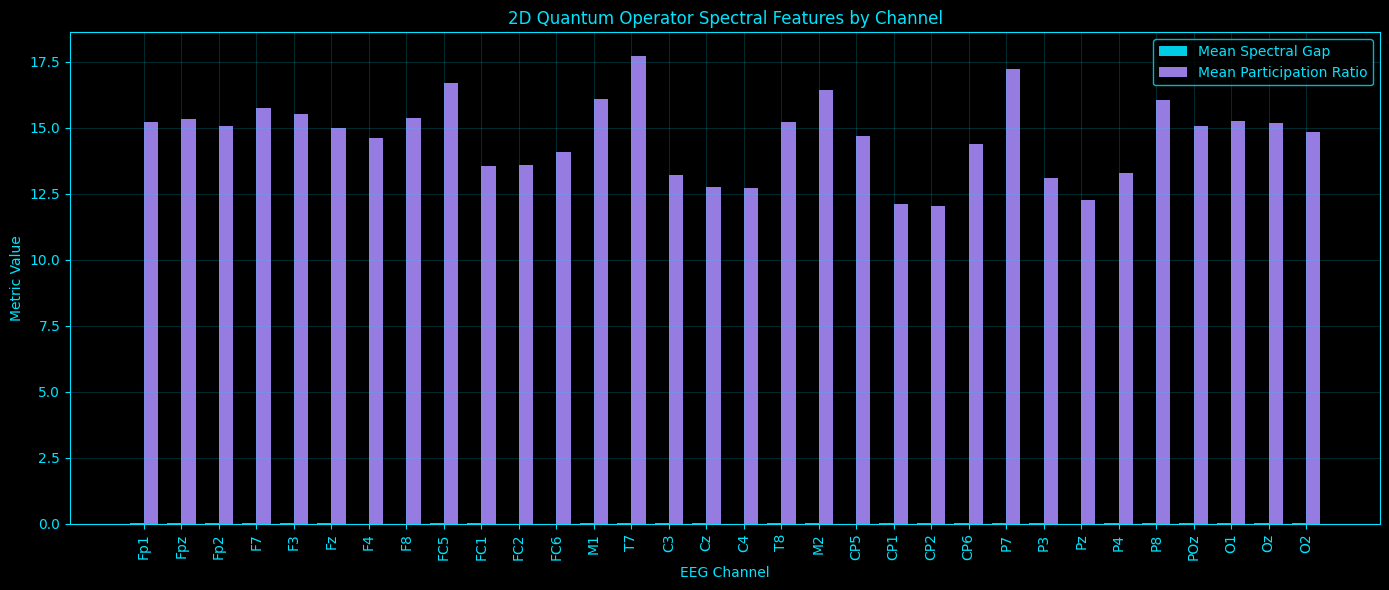

[     6.5s] Displayed plot: operator_2d_channel_spectral_features.png
[     6.7s] Saved plot: operator_2d_channel_energy_localization.png


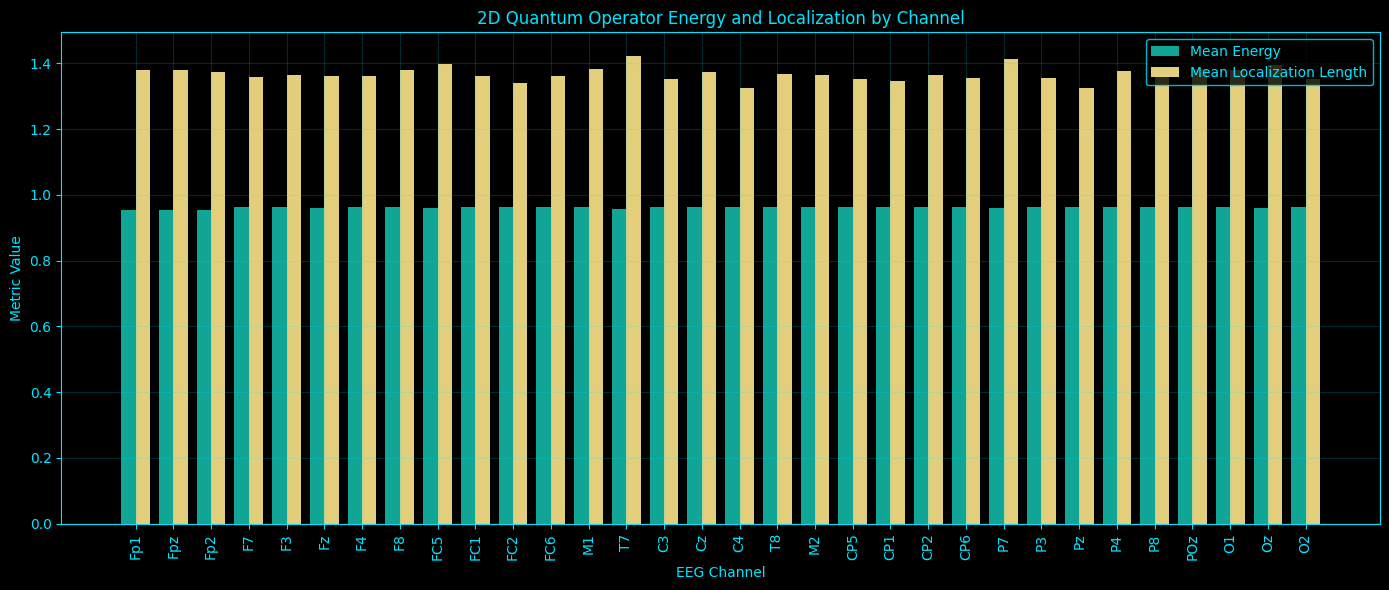

[     6.8s] Displayed plot: operator_2d_channel_energy_localization.png
[     7.2s] Saved plot: operator_2d_channel_eigenspectrum.png


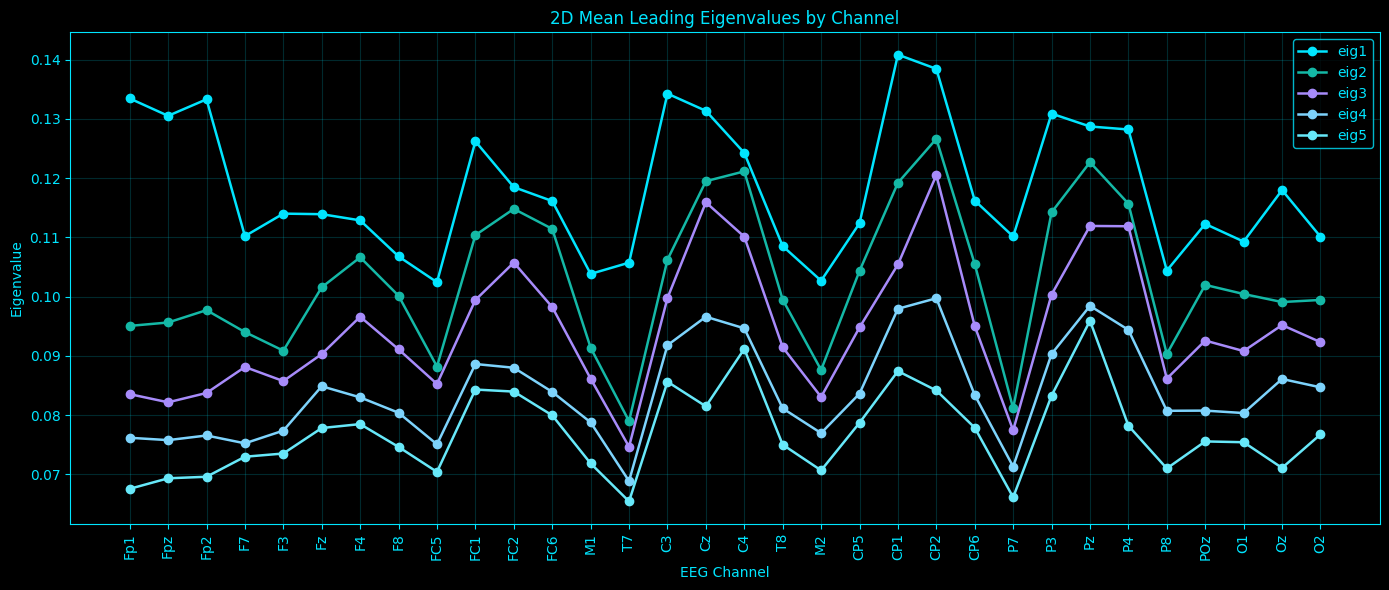

[     7.3s] Displayed plot: operator_2d_channel_eigenspectrum.png
[     7.4s] Saved plot: operator_2d_selected_spectral_gap_time.png


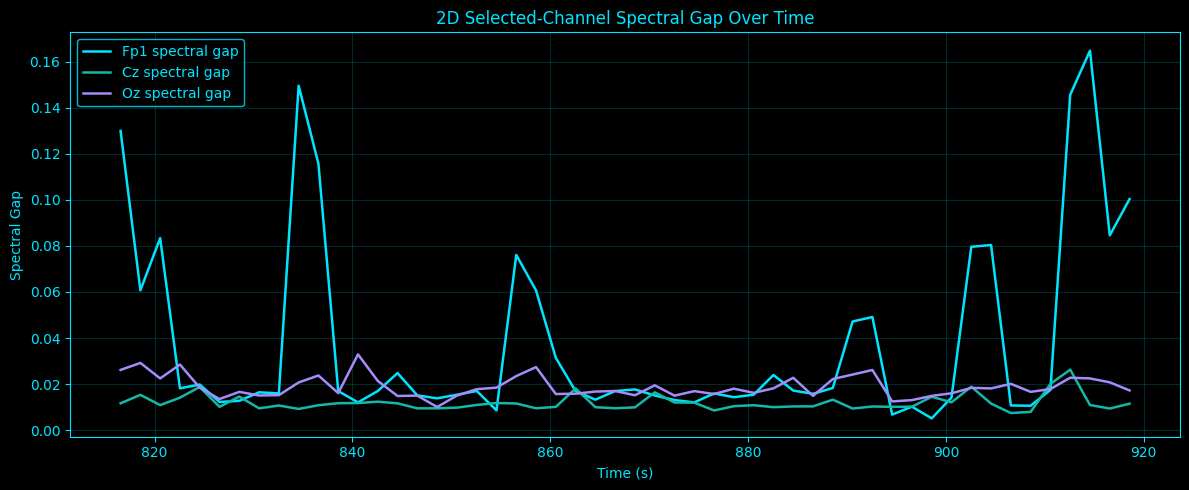

[     7.5s] Displayed plot: operator_2d_selected_spectral_gap_time.png
[     7.7s] Saved plot: operator_2d_selected_energy_time.png


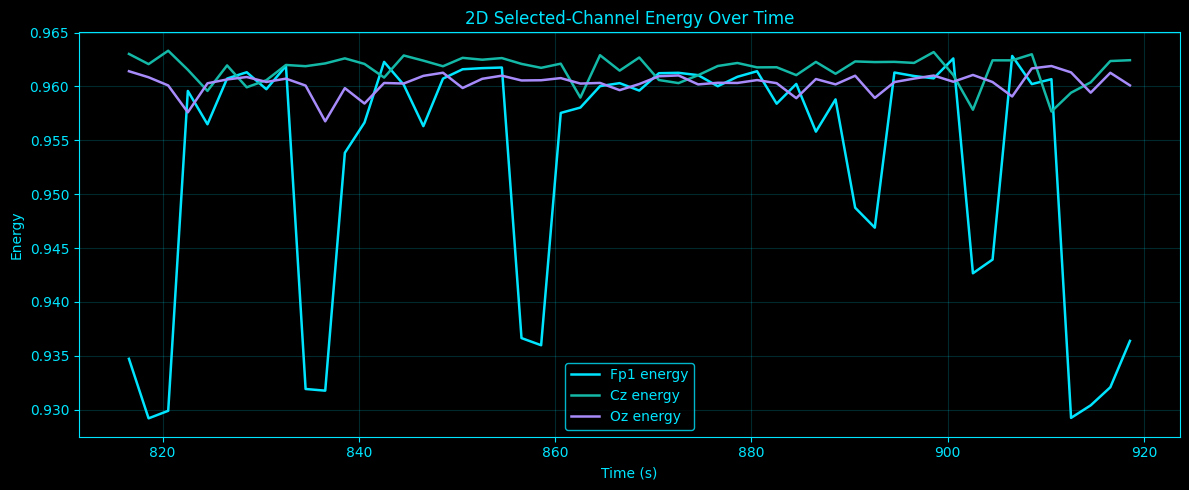

[     7.7s] Displayed plot: operator_2d_selected_energy_time.png
[     8.0s] Saved plot: operator_2d_channel_flow_features.png


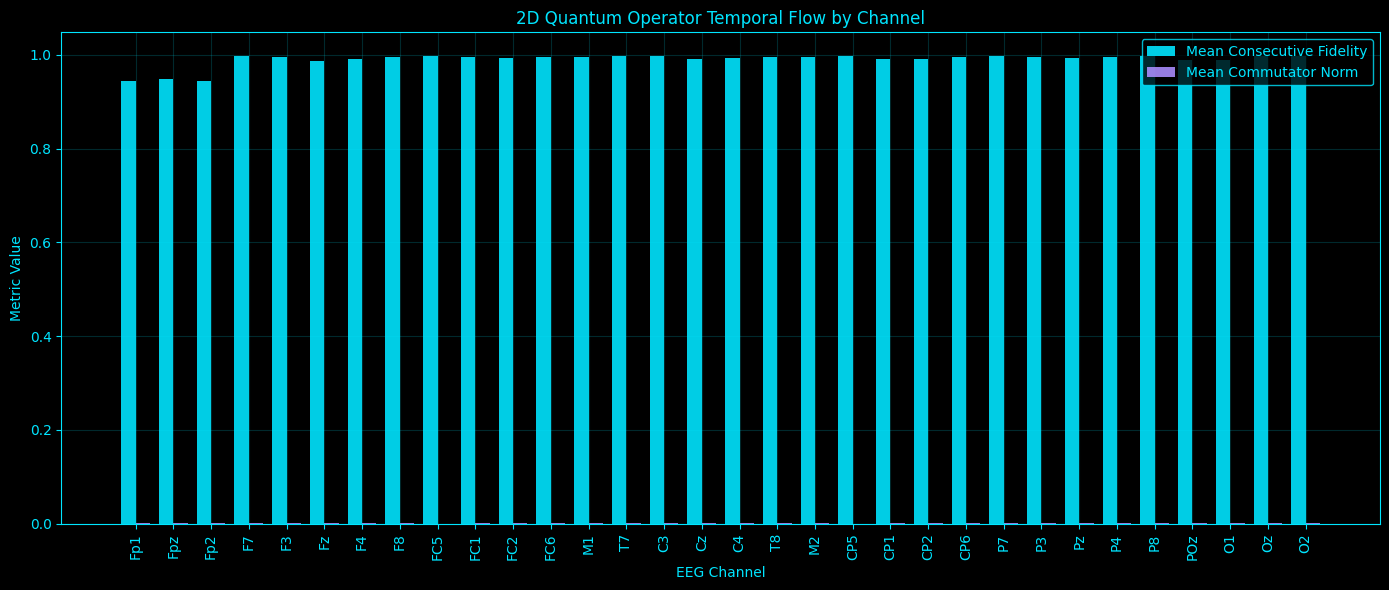

[     8.1s] Displayed plot: operator_2d_channel_flow_features.png
[     8.2s] Saved plot: operator_2d_time_summary.png


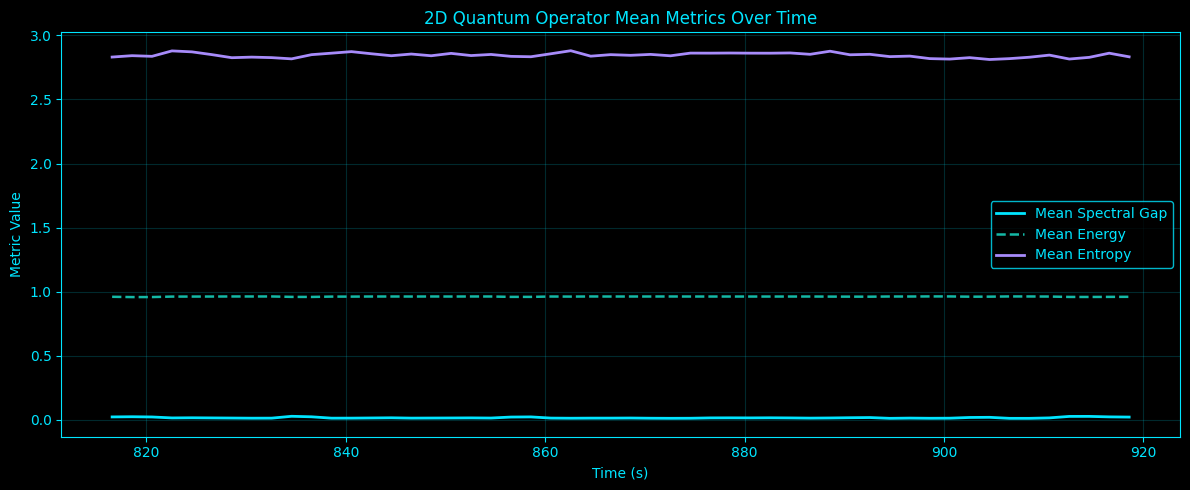

[     8.3s] Displayed plot: operator_2d_time_summary.png
[     8.4s] Saved plot: operator_2d_flow_time_summary.png


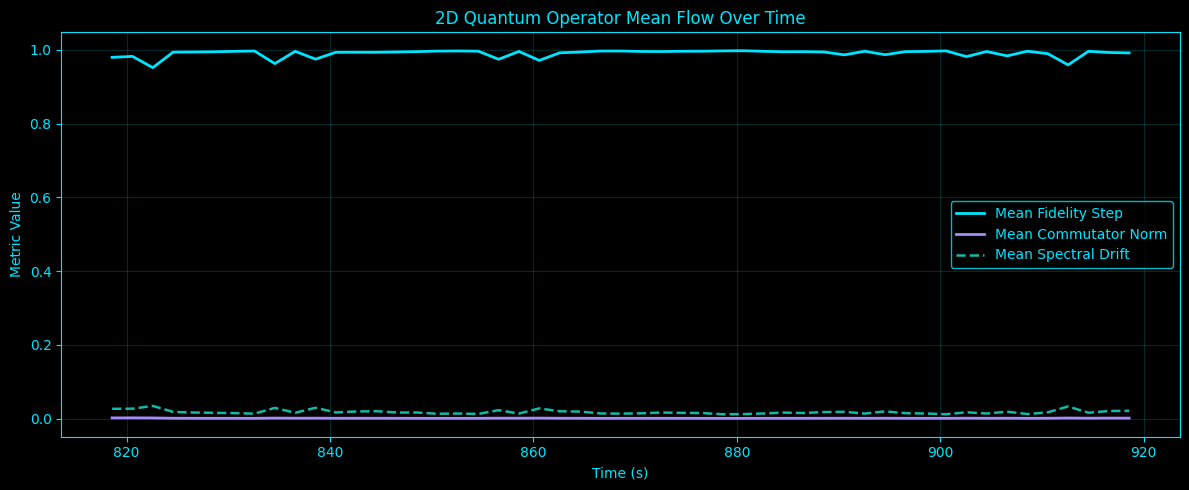

[     8.5s] Displayed plot: operator_2d_flow_time_summary.png
[     8.8s] Saved plot: operator_2d_channel_fidelity_heatmap.png


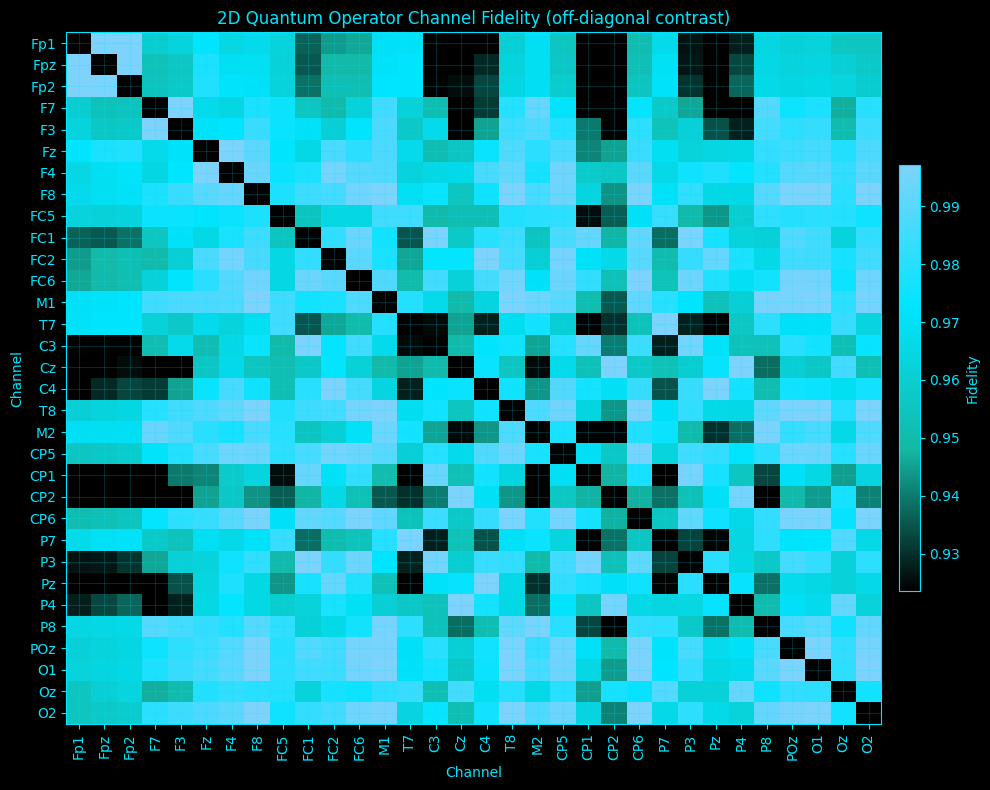

[     9.0s] Displayed plot: operator_2d_channel_fidelity_heatmap.png
[     9.0s] Starting advanced operator analysis for 3D
[     9.0s] 3D loaded 1/32: Fp1 shape=(106936, 3)
[     9.0s] 3D loaded 4/32: F7 shape=(106936, 3)
[     9.0s] 3D loaded 8/32: F8 shape=(106936, 3)
[     9.1s] 3D loaded 12/32: FC6 shape=(106936, 3)
[     9.1s] 3D loaded 16/32: Cz shape=(106940, 3)
[     9.1s] 3D loaded 20/32: CP5 shape=(106938, 3)
[     9.1s] 3D loaded 24/32: P7 shape=(106940, 3)
[     9.2s] 3D loaded 28/32: P8 shape=(106936, 3)
[     9.2s] 3D loaded 32/32: O2 shape=(106936, 3)
[     9.2s] 3D common length across channels: 106936
[     9.2s] 3D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[     9.2s] 3D fitting codebook | pool_shape=(80000, 3) | states=24
[     9.3s] 3D codebook fit complete | sigma2=0.214393
[     9.3s] 3D Hamiltonian built | graph_sigma=2.088268
[     9.3s] 3D Fp1 window 1/52 | gap=0.18616 | PR=7.324 | E=0.88091
[     9.4s] 3D Fp1 window 20/52 | gap=0.0204

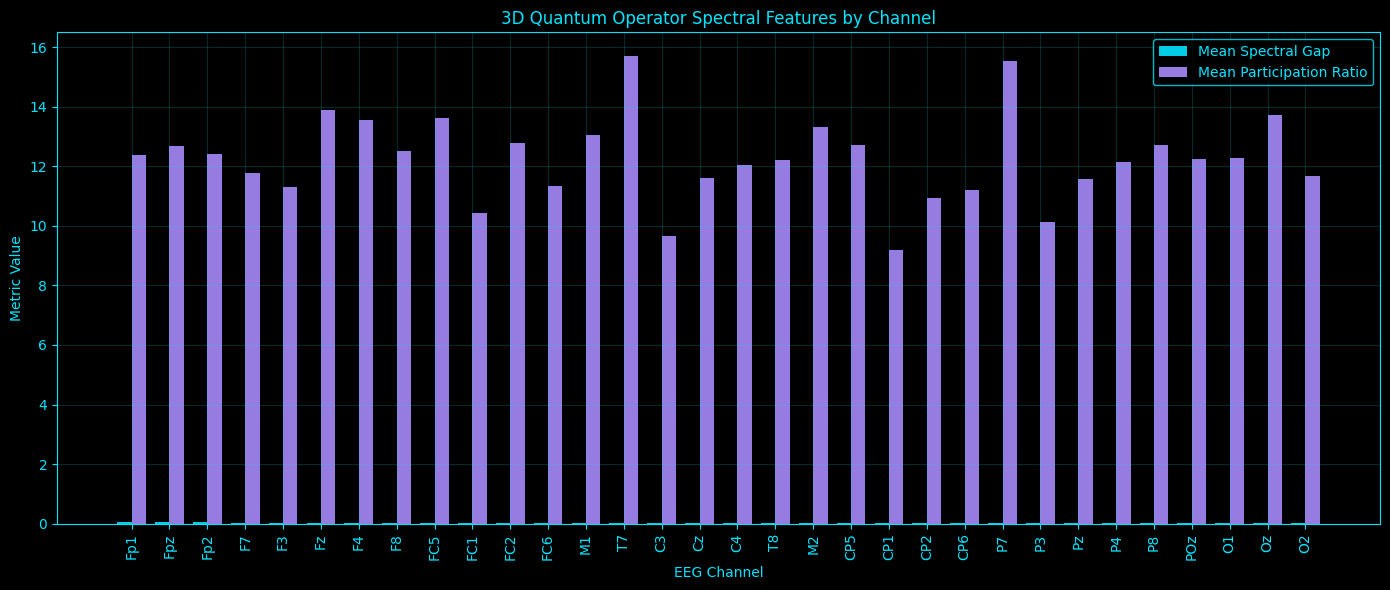

[    15.7s] Displayed plot: operator_3d_channel_spectral_features.png
[    15.9s] Saved plot: operator_3d_channel_energy_localization.png


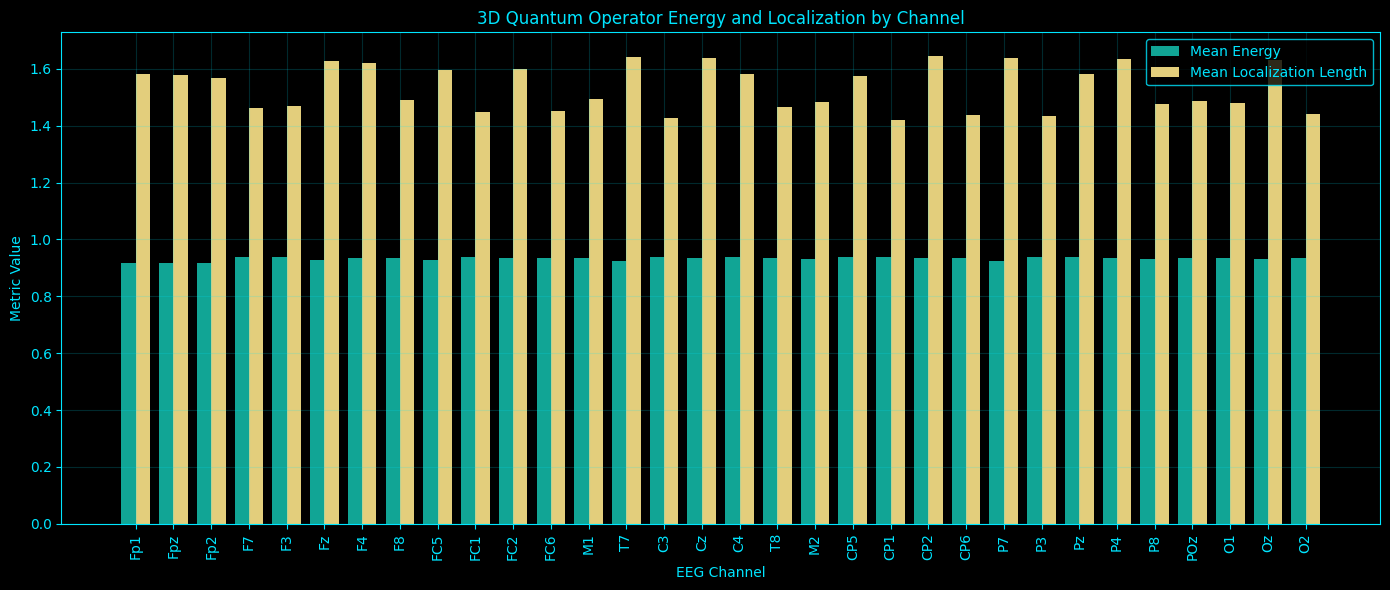

[    16.0s] Displayed plot: operator_3d_channel_energy_localization.png
[    16.4s] Saved plot: operator_3d_channel_eigenspectrum.png


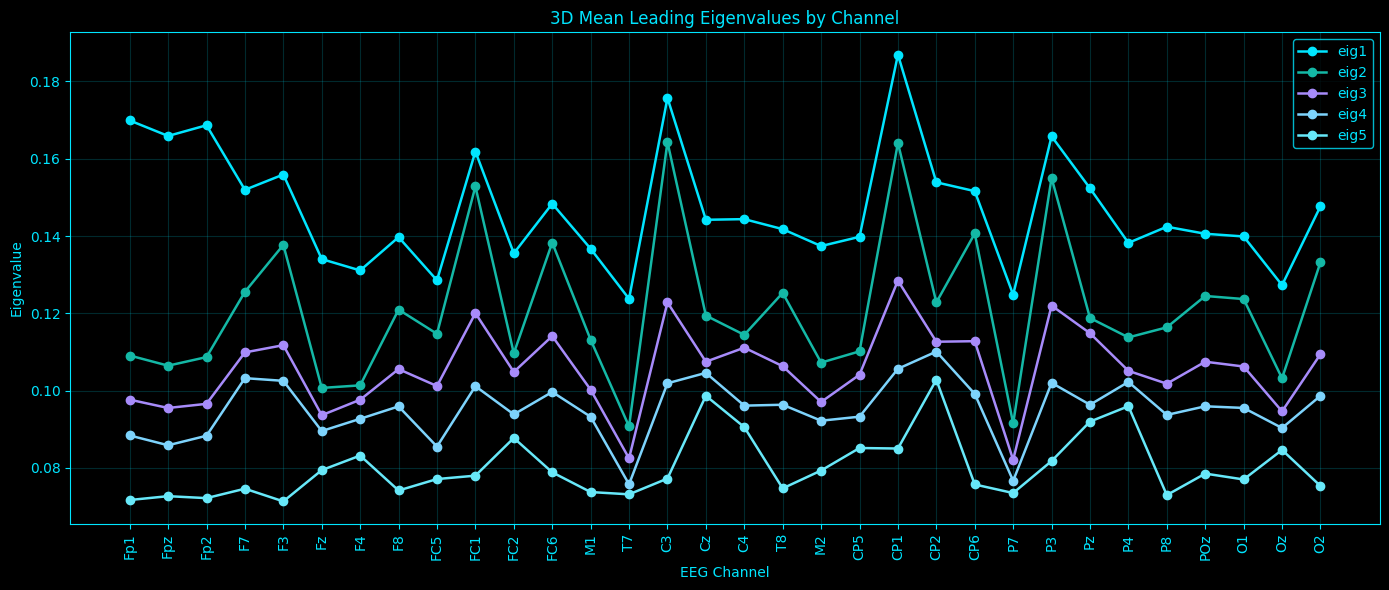

[    16.5s] Displayed plot: operator_3d_channel_eigenspectrum.png
[    16.7s] Saved plot: operator_3d_selected_spectral_gap_time.png


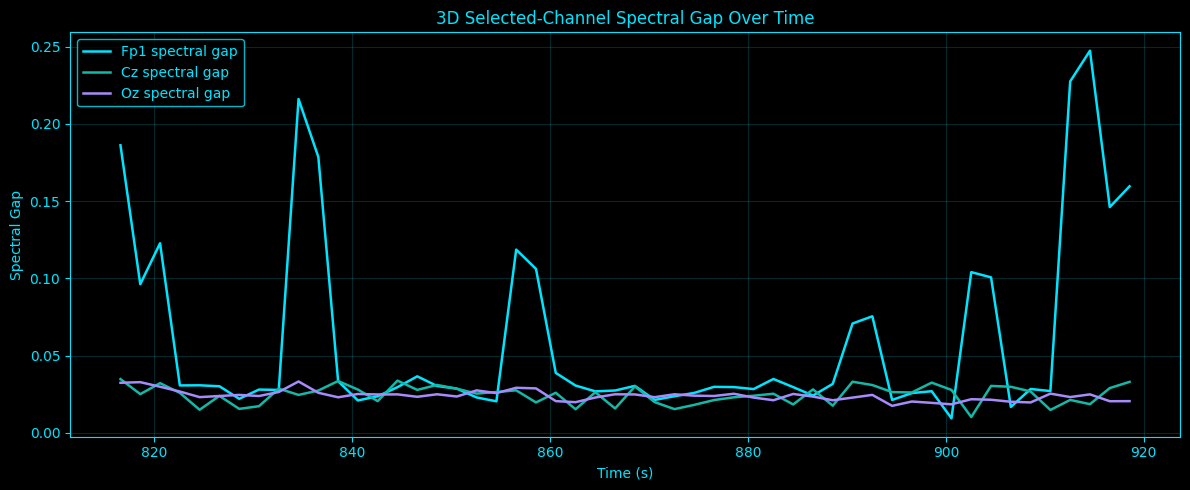

[    16.7s] Displayed plot: operator_3d_selected_spectral_gap_time.png
[    16.9s] Saved plot: operator_3d_selected_energy_time.png


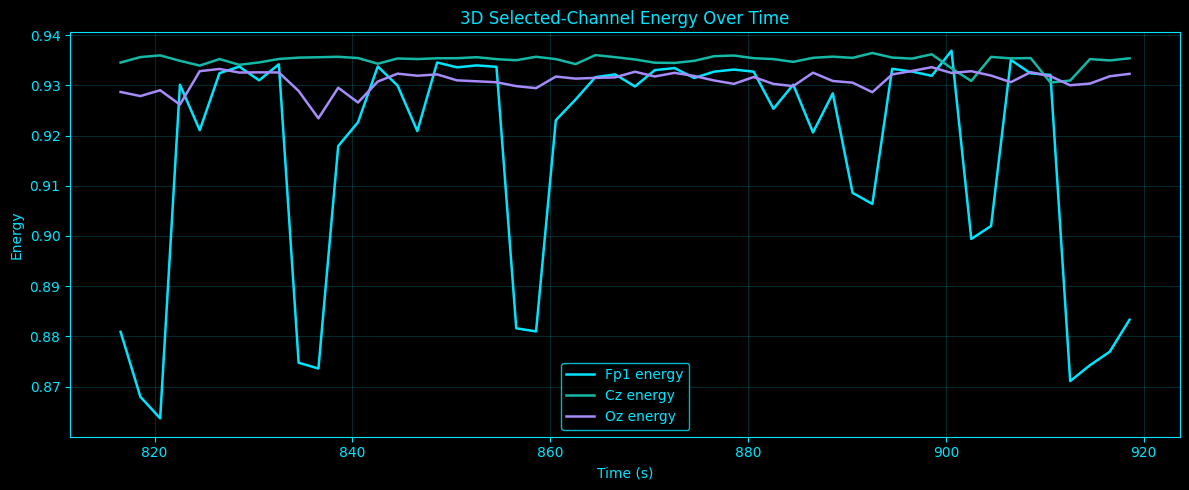

[    16.9s] Displayed plot: operator_3d_selected_energy_time.png
[    17.2s] Saved plot: operator_3d_channel_flow_features.png


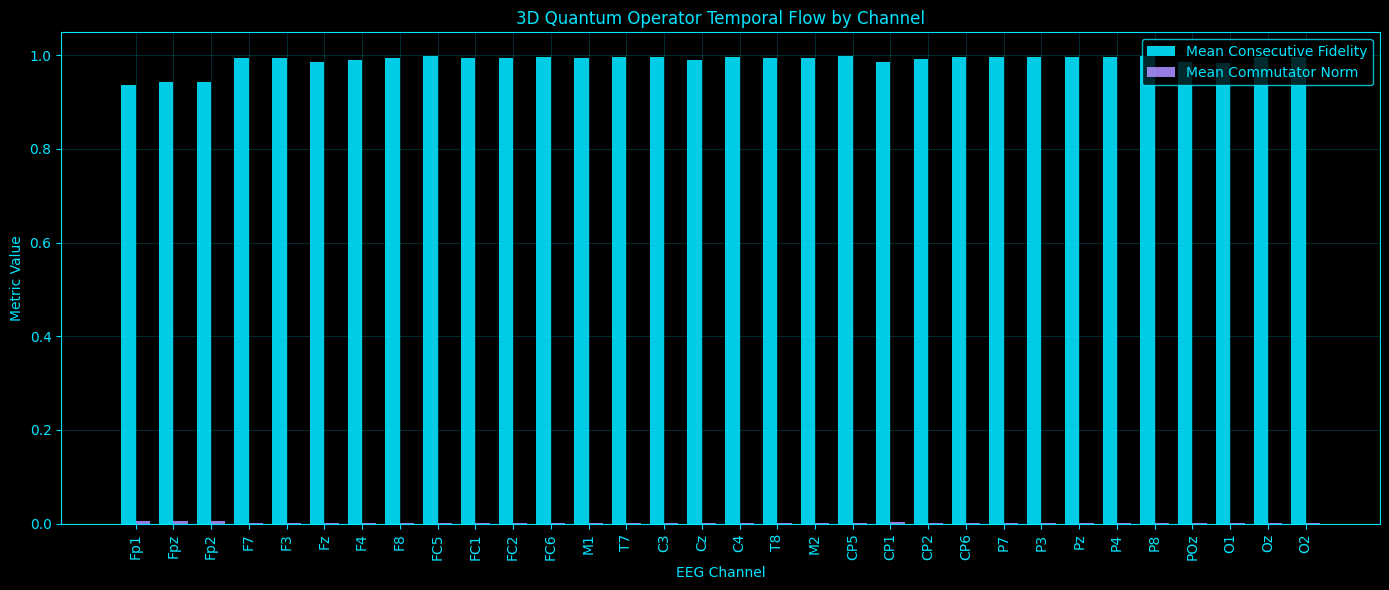

[    17.3s] Displayed plot: operator_3d_channel_flow_features.png
[    17.4s] Saved plot: operator_3d_time_summary.png


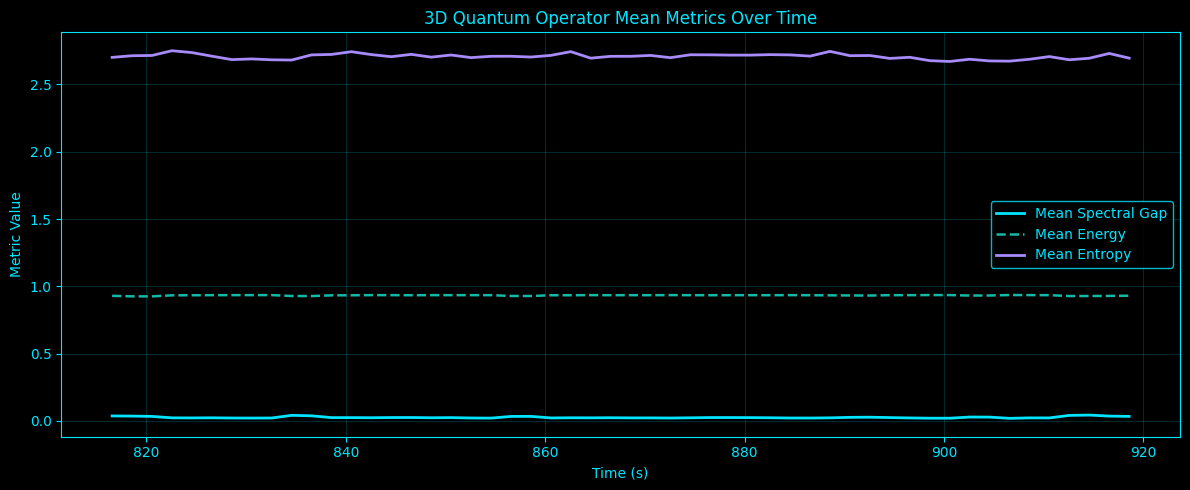

[    17.5s] Displayed plot: operator_3d_time_summary.png
[    17.6s] Saved plot: operator_3d_flow_time_summary.png


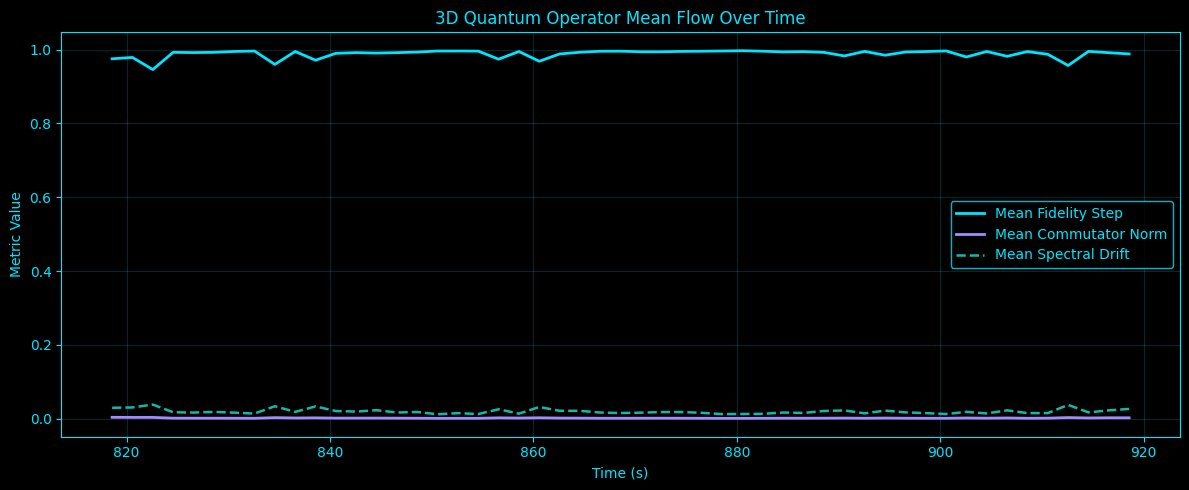

[    17.7s] Displayed plot: operator_3d_flow_time_summary.png
[    18.1s] Saved plot: operator_3d_channel_fidelity_heatmap.png


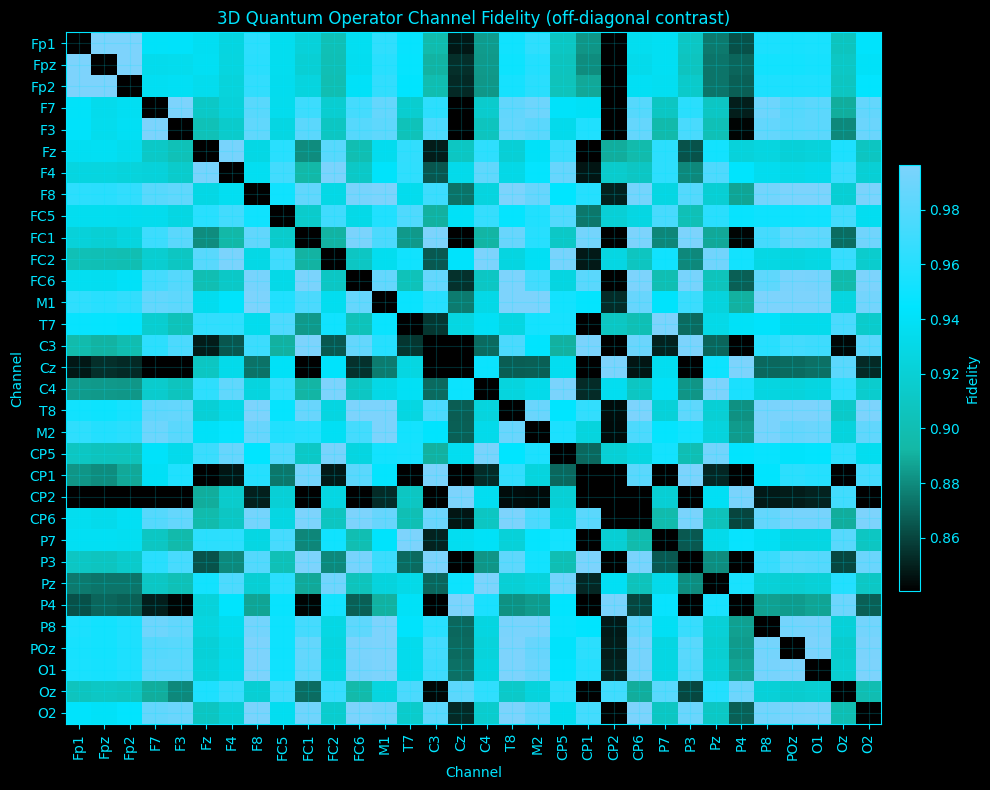

[    18.2s] Displayed plot: operator_3d_channel_fidelity_heatmap.png
[    18.2s] Starting advanced operator analysis for 4D
[    18.2s] 4D loaded 1/32: Fp1 shape=(106932, 4)
[    18.2s] 4D loaded 4/32: F7 shape=(106932, 4)
[    18.3s] 4D loaded 8/32: F8 shape=(106932, 4)
[    18.3s] 4D loaded 12/32: FC6 shape=(106932, 4)
[    18.3s] 4D loaded 16/32: Cz shape=(106938, 4)
[    18.3s] 4D loaded 20/32: CP5 shape=(106935, 4)
[    18.4s] 4D loaded 24/32: P7 shape=(106938, 4)
[    18.4s] 4D loaded 28/32: P8 shape=(106932, 4)
[    18.4s] 4D loaded 32/32: O2 shape=(106932, 4)
[    18.4s] 4D common length across channels: 106932
[    18.4s] 4D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[    18.4s] 4D fitting codebook | pool_shape=(80000, 4) | states=32
[    18.6s] 4D codebook fit complete | sigma2=0.346378
[    18.6s] 4D Hamiltonian built | graph_sigma=2.380412
[    18.6s] 4D Fp1 window 1/52 | gap=0.14505 | PR=8.447 | E=0.86105
[    18.8s] 4D Fp1 window 20/52 | gap=0.0087

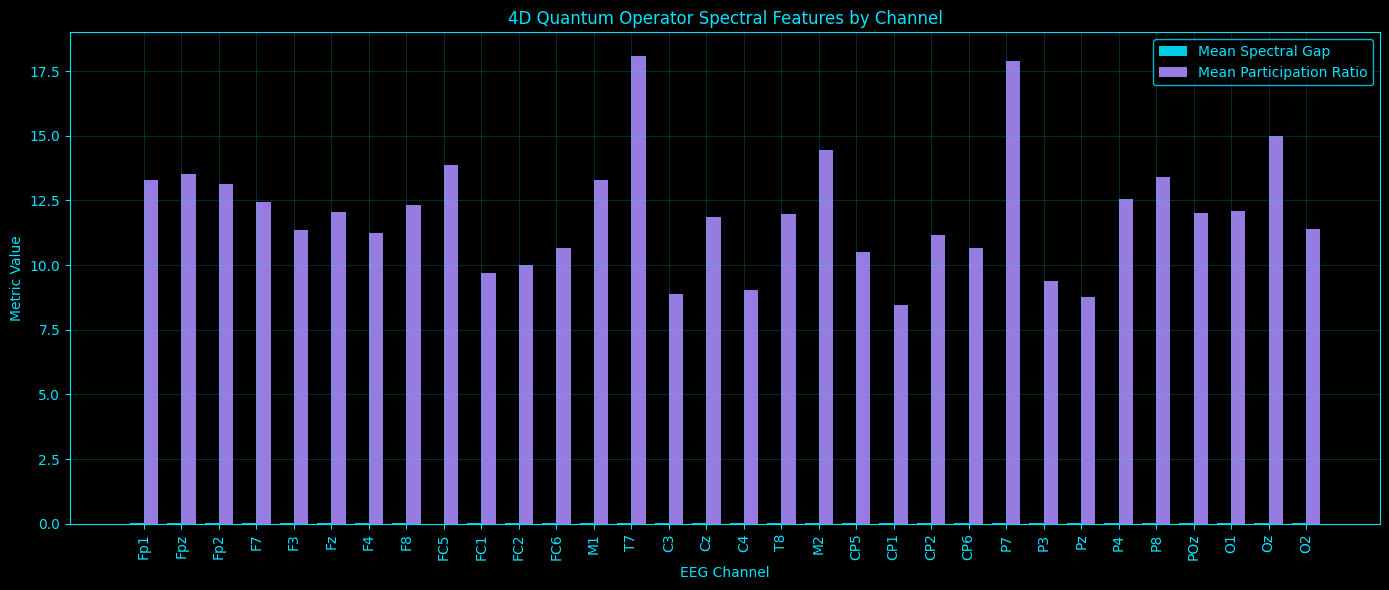

[    29.9s] Displayed plot: operator_4d_channel_spectral_features.png
[    30.2s] Saved plot: operator_4d_channel_energy_localization.png


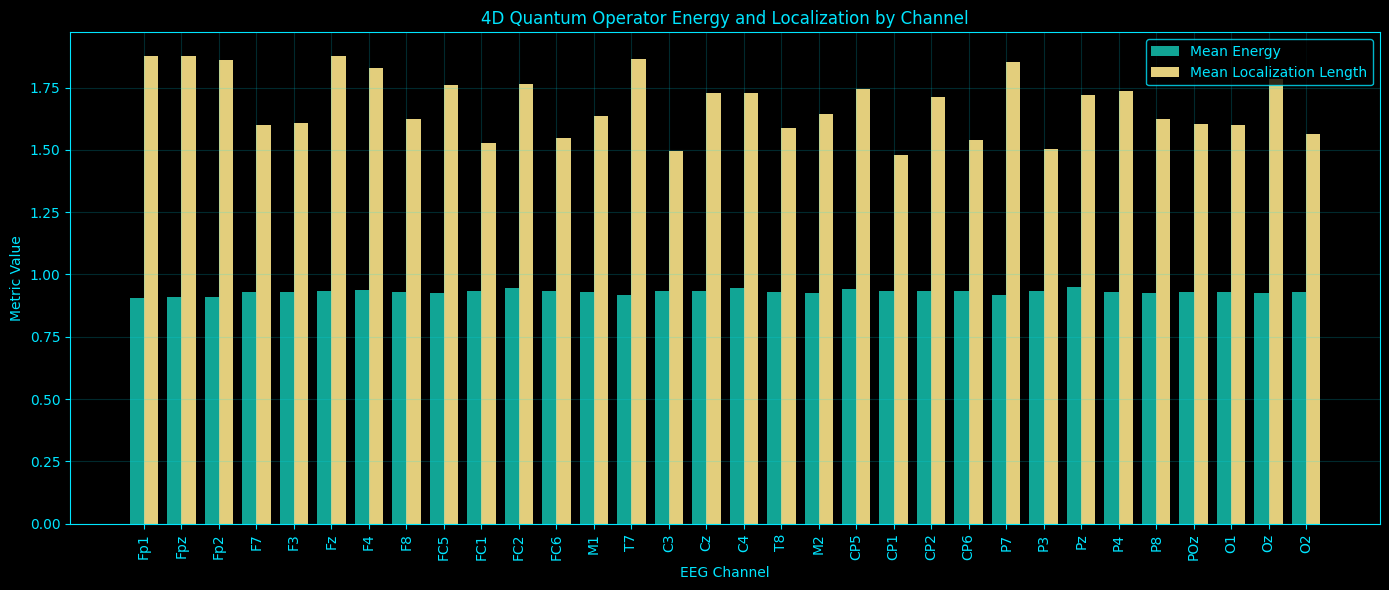

[    30.3s] Displayed plot: operator_4d_channel_energy_localization.png
[    30.6s] Saved plot: operator_4d_channel_eigenspectrum.png


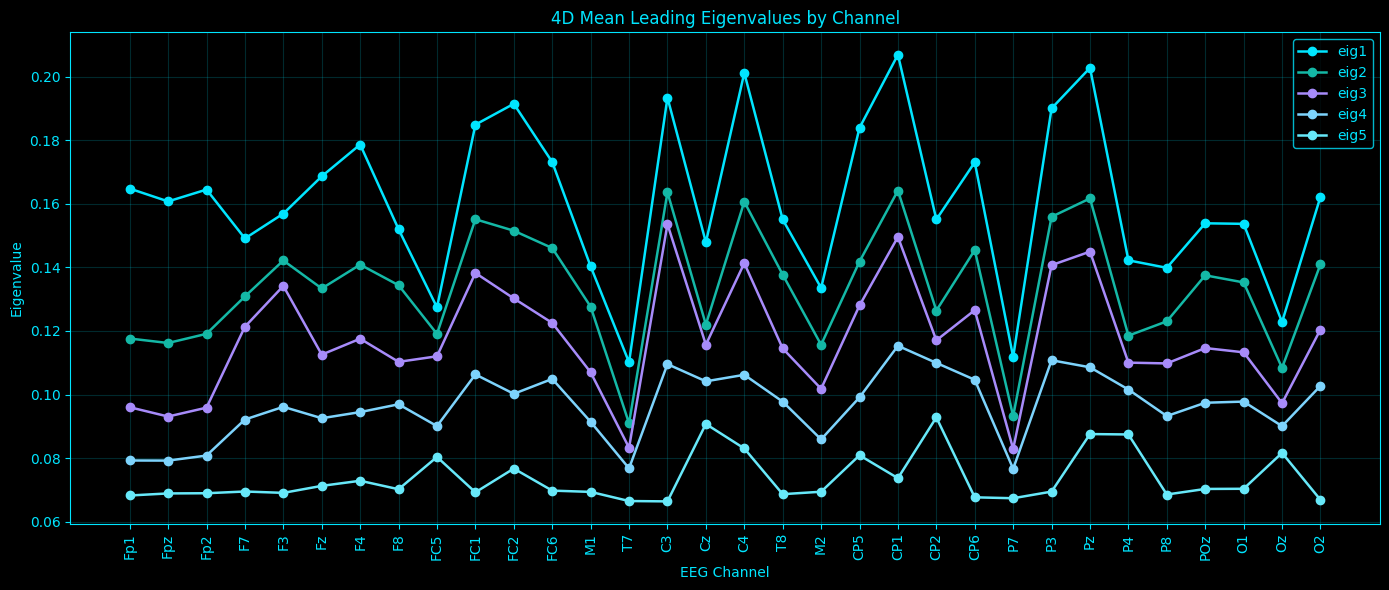

[    30.7s] Displayed plot: operator_4d_channel_eigenspectrum.png
[    31.0s] Saved plot: operator_4d_selected_spectral_gap_time.png


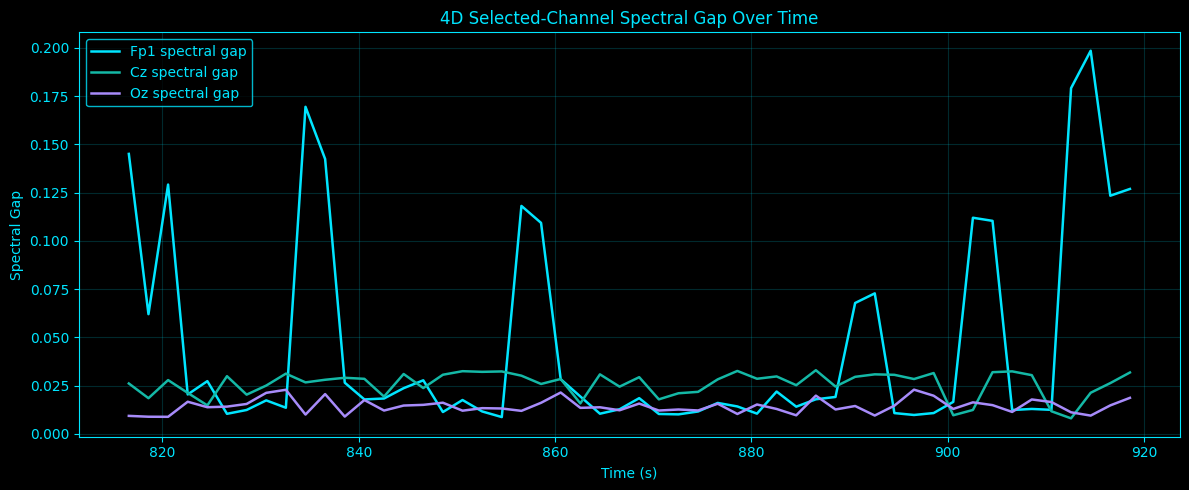

[    31.1s] Displayed plot: operator_4d_selected_spectral_gap_time.png
[    31.2s] Saved plot: operator_4d_selected_energy_time.png


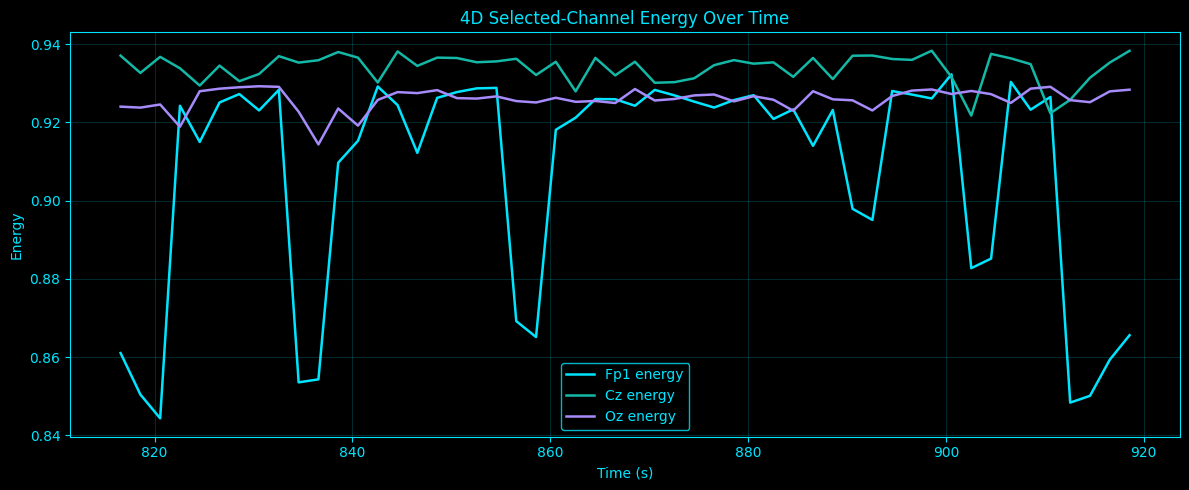

[    31.3s] Displayed plot: operator_4d_selected_energy_time.png
[    31.5s] Saved plot: operator_4d_channel_flow_features.png


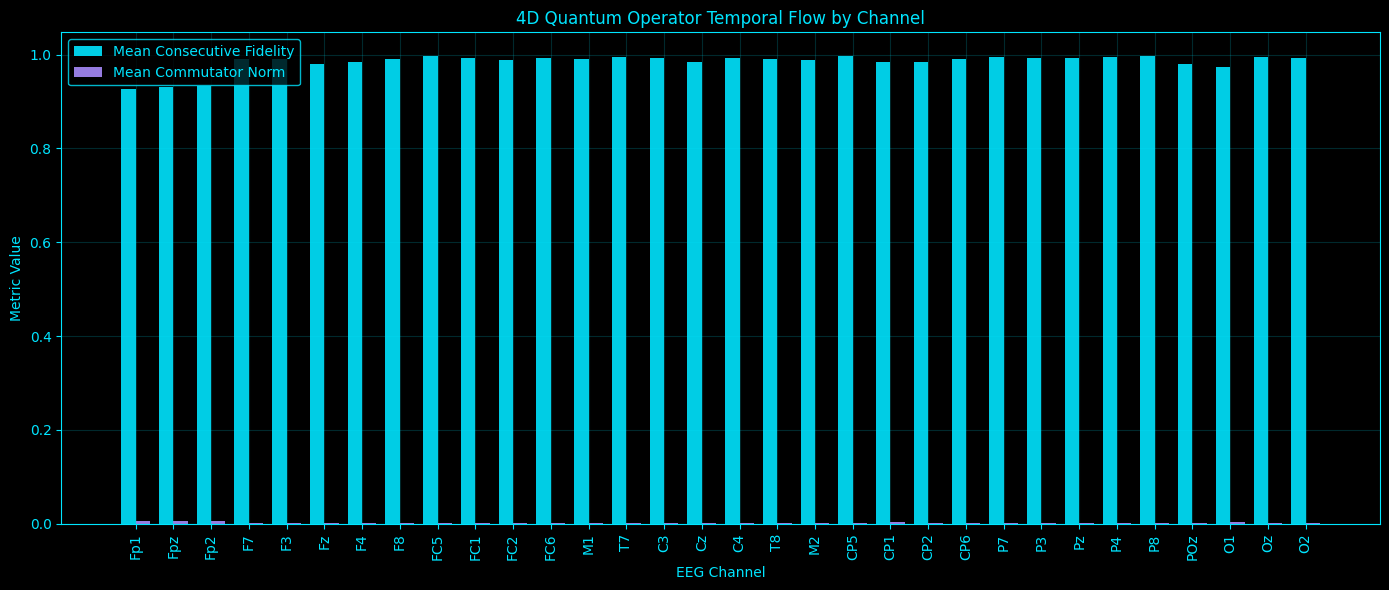

[    31.6s] Displayed plot: operator_4d_channel_flow_features.png
[    31.8s] Saved plot: operator_4d_time_summary.png


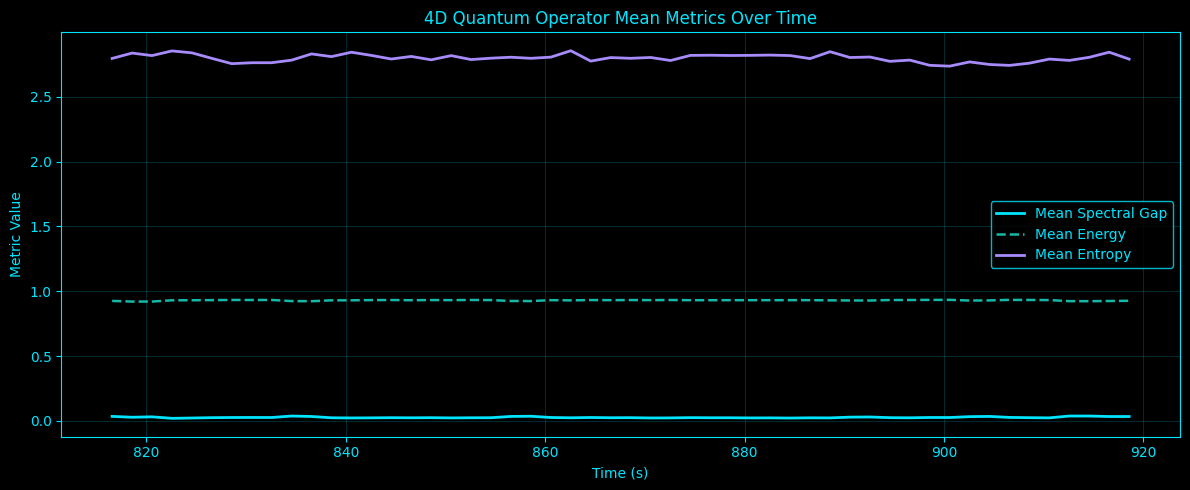

[    31.8s] Displayed plot: operator_4d_time_summary.png
[    32.0s] Saved plot: operator_4d_flow_time_summary.png


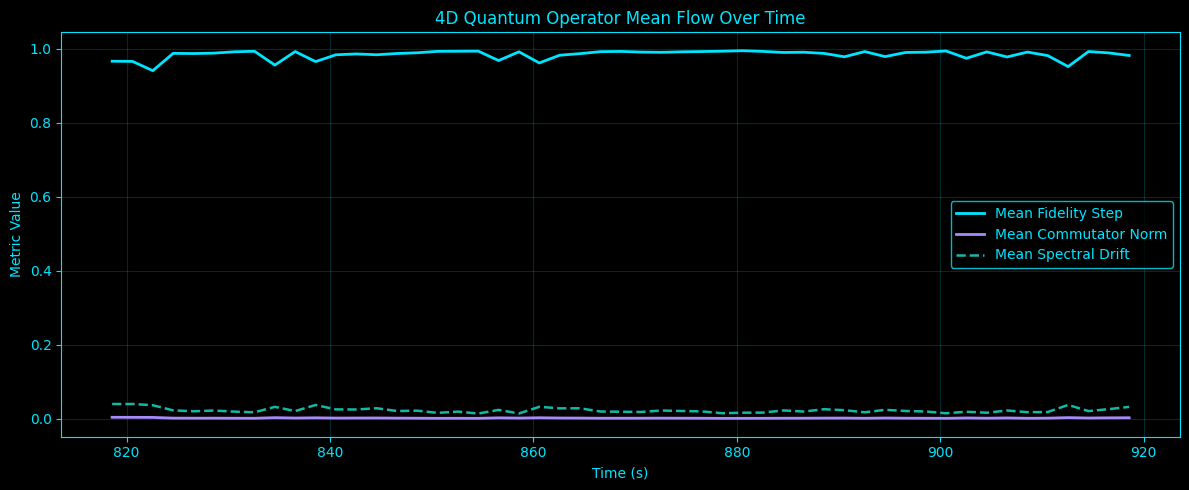

[    32.0s] Displayed plot: operator_4d_flow_time_summary.png
[    32.4s] Saved plot: operator_4d_channel_fidelity_heatmap.png


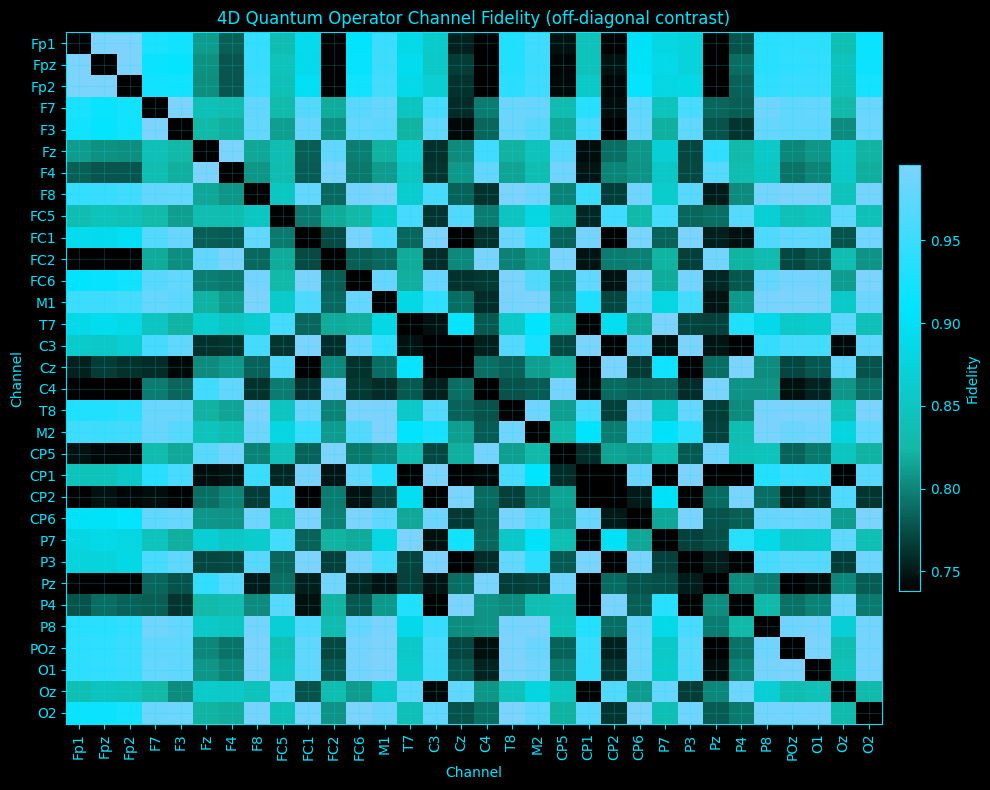

[    32.5s] Displayed plot: operator_4d_channel_fidelity_heatmap.png
[    32.5s] Starting advanced operator analysis for 5D
[    32.5s] 5D loaded 1/32: Fp1 shape=(106928, 5)
[    32.6s] 5D loaded 4/32: F7 shape=(106928, 5)
[    32.6s] 5D loaded 8/32: F8 shape=(106928, 5)
[    32.6s] 5D loaded 12/32: FC6 shape=(106928, 5)
[    32.7s] 5D loaded 16/32: Cz shape=(106936, 5)
[    32.7s] 5D loaded 20/32: CP5 shape=(106932, 5)
[    32.7s] 5D loaded 24/32: P7 shape=(106936, 5)
[    32.8s] 5D loaded 28/32: P8 shape=(106928, 5)
[    32.8s] 5D loaded 32/32: O2 shape=(106928, 5)
[    32.8s] 5D common length across channels: 106928
[    32.8s] 5D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[    32.8s] 5D fitting codebook | pool_shape=(80000, 5) | states=32
[    32.9s] 5D codebook fit complete | sigma2=0.497053
[    32.9s] 5D Hamiltonian built | graph_sigma=2.628191
[    32.9s] 5D Fp1 window 1/52 | gap=0.15047 | PR=7.432 | E=0.85146
[    33.1s] 5D Fp1 window 20/52 | gap=0.0638

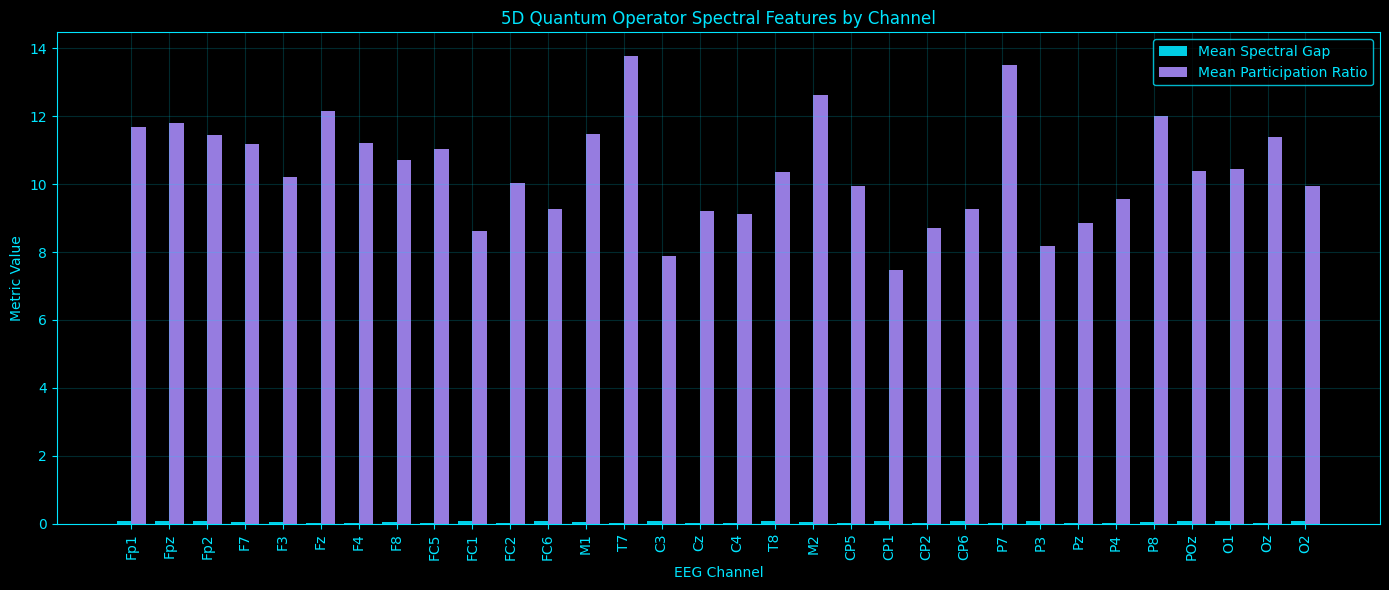

[    45.0s] Displayed plot: operator_5d_channel_spectral_features.png
[    45.3s] Saved plot: operator_5d_channel_energy_localization.png


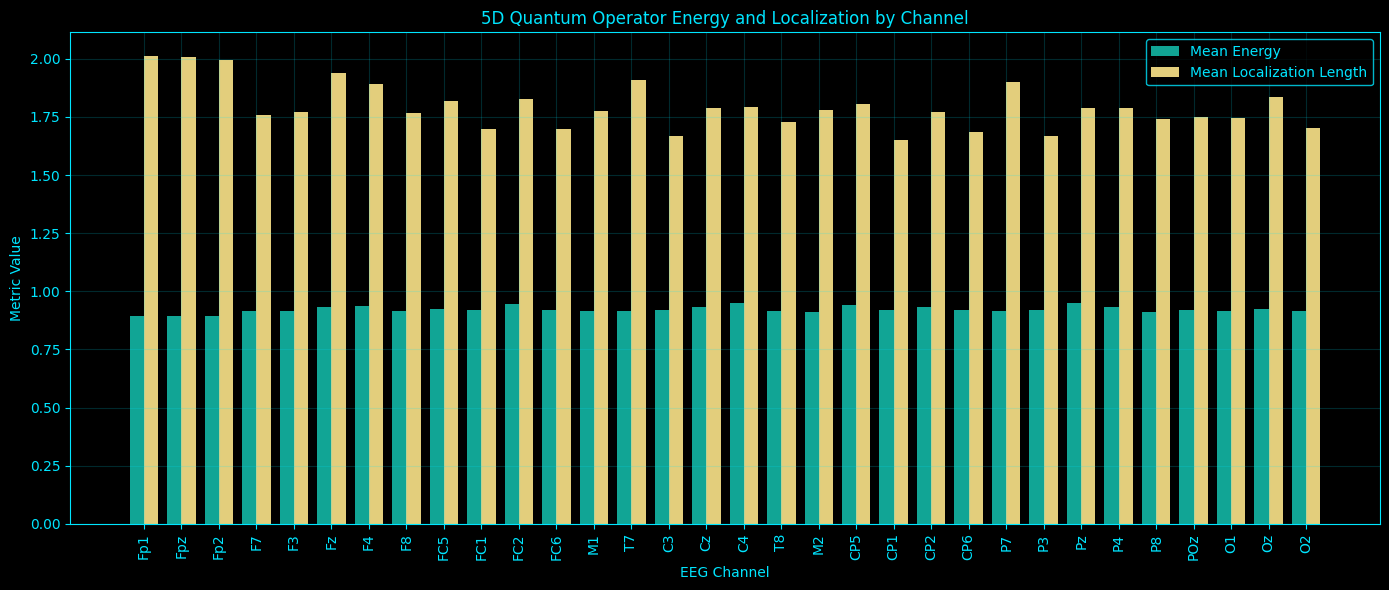

[    45.4s] Displayed plot: operator_5d_channel_energy_localization.png
[    45.6s] Saved plot: operator_5d_channel_eigenspectrum.png


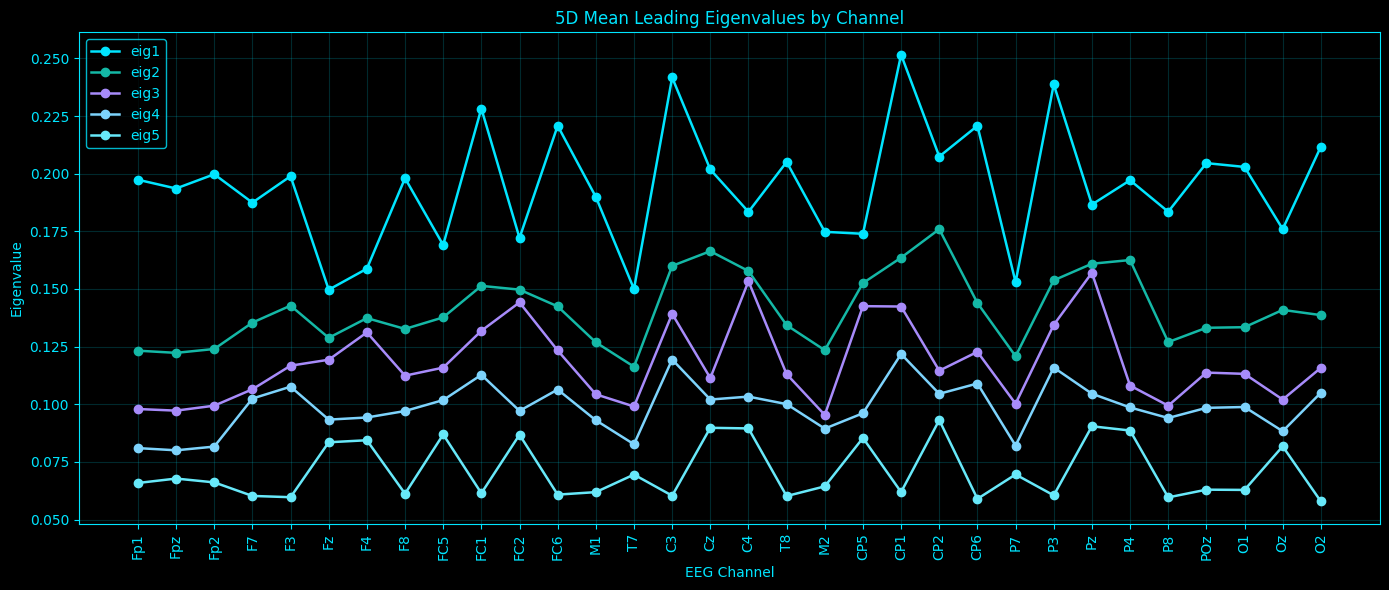

[    45.7s] Displayed plot: operator_5d_channel_eigenspectrum.png
[    45.9s] Saved plot: operator_5d_selected_spectral_gap_time.png


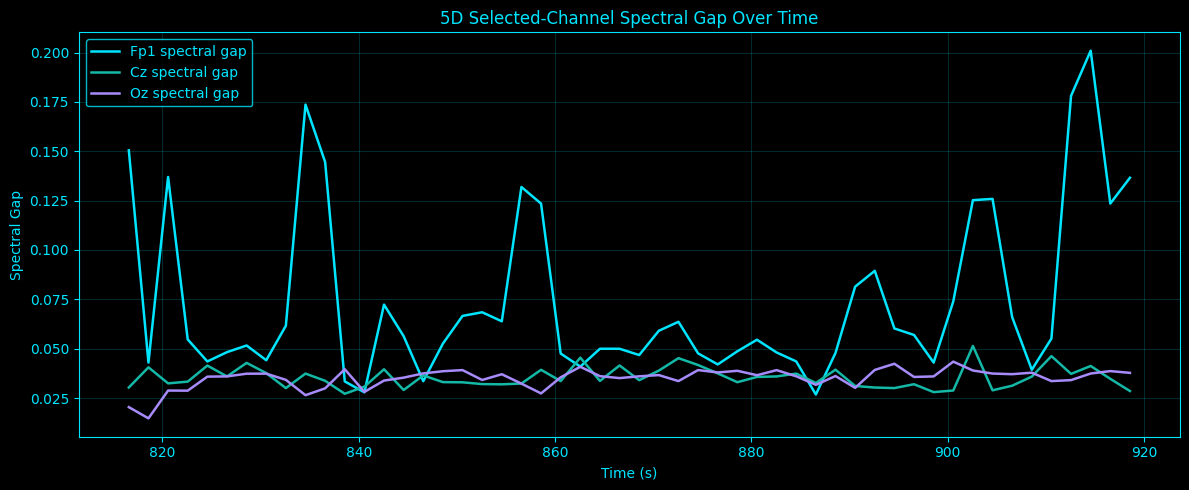

[    46.0s] Displayed plot: operator_5d_selected_spectral_gap_time.png
[    46.2s] Saved plot: operator_5d_selected_energy_time.png


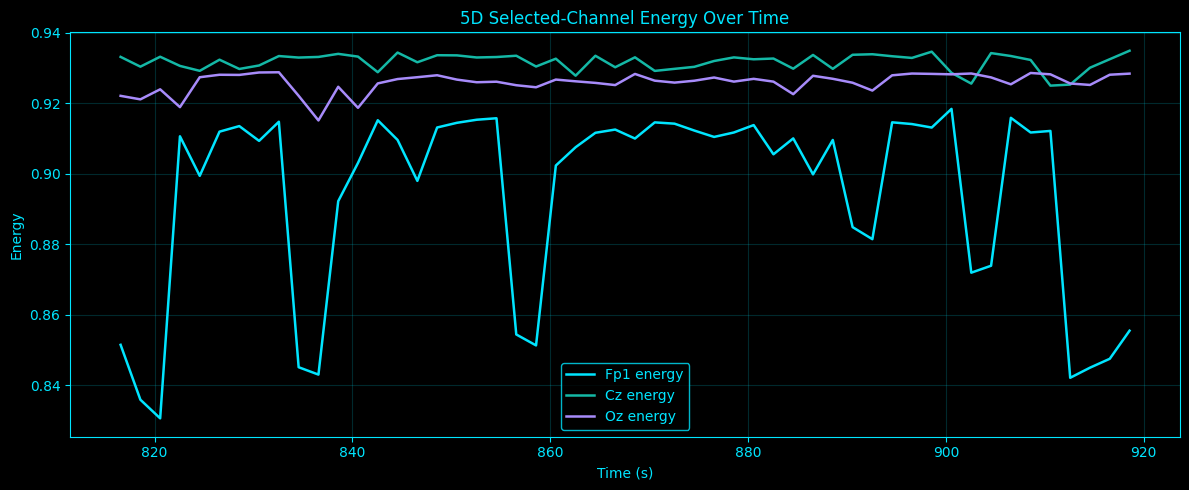

[    46.3s] Displayed plot: operator_5d_selected_energy_time.png
[    46.5s] Saved plot: operator_5d_channel_flow_features.png


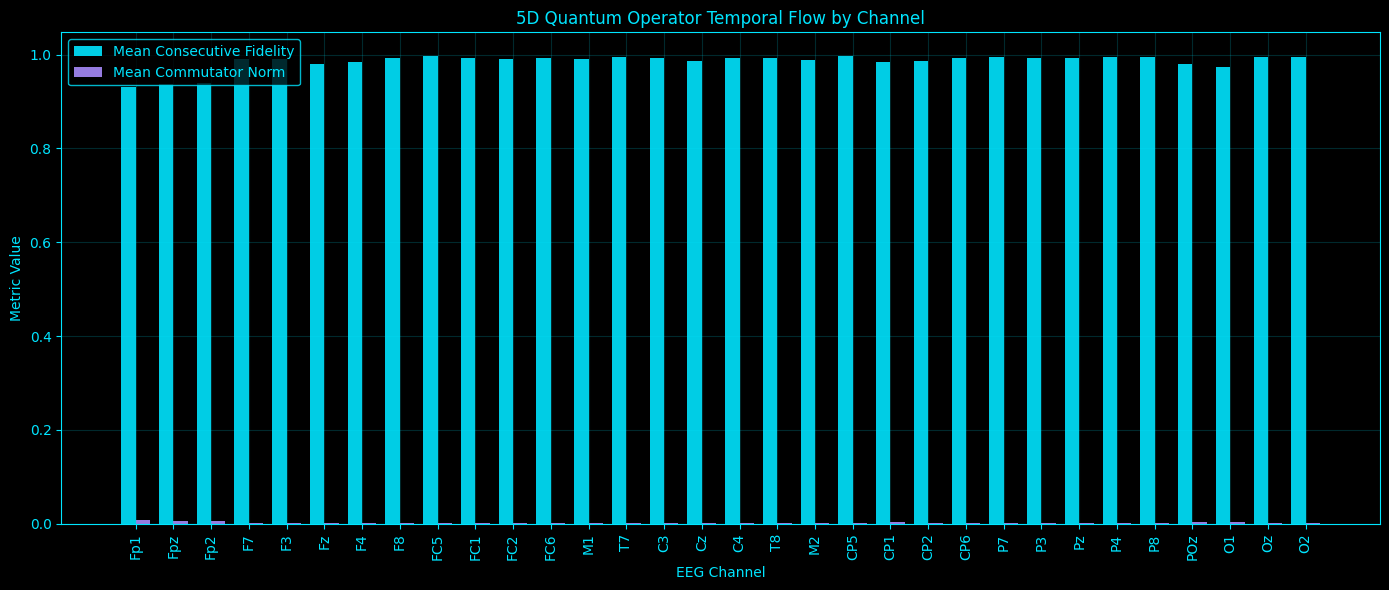

[    46.6s] Displayed plot: operator_5d_channel_flow_features.png
[    46.7s] Saved plot: operator_5d_time_summary.png


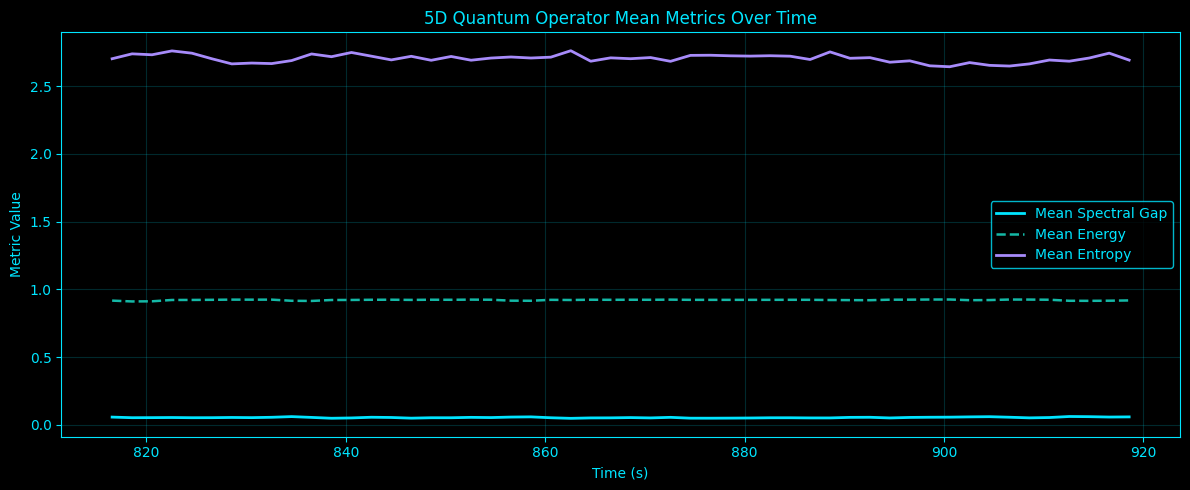

[    46.8s] Displayed plot: operator_5d_time_summary.png
[    46.9s] Saved plot: operator_5d_flow_time_summary.png


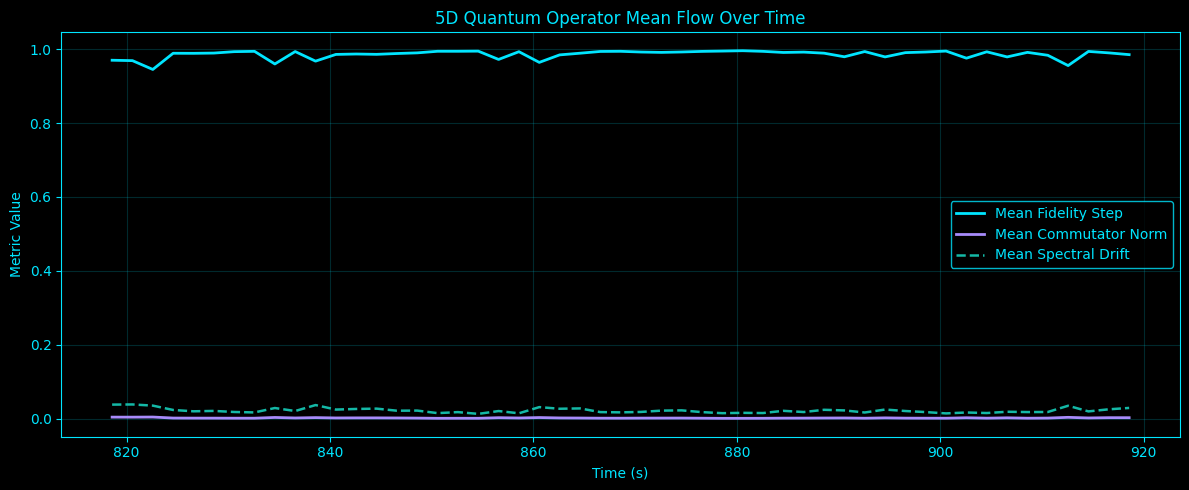

[    47.0s] Displayed plot: operator_5d_flow_time_summary.png
[    47.4s] Saved plot: operator_5d_channel_fidelity_heatmap.png


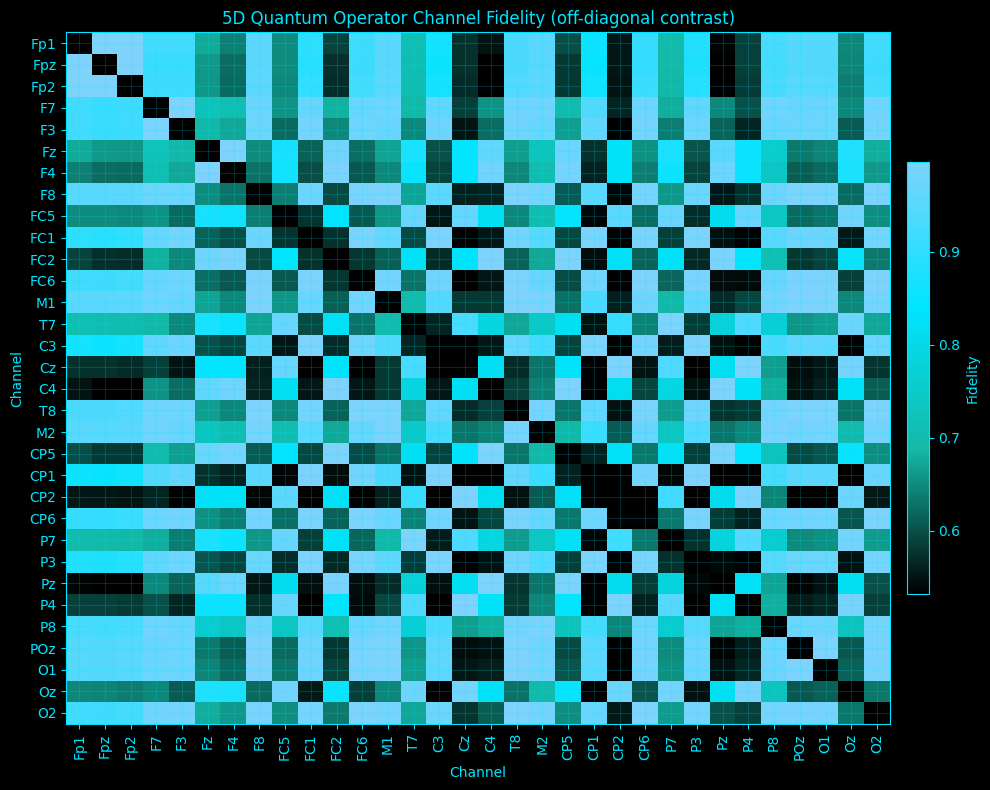

[    47.5s] Displayed plot: operator_5d_channel_fidelity_heatmap.png
[    47.5s] Starting advanced operator analysis for 6D
[    47.5s] 6D loaded 1/32: Fp1 shape=(106924, 6)
[    47.5s] 6D loaded 4/32: F7 shape=(106924, 6)
[    47.6s] 6D loaded 8/32: F8 shape=(106924, 6)
[    47.6s] 6D loaded 12/32: FC6 shape=(106924, 6)
[    47.6s] 6D loaded 16/32: Cz shape=(106934, 6)
[    47.7s] 6D loaded 20/32: CP5 shape=(106929, 6)
[    47.7s] 6D loaded 24/32: P7 shape=(106934, 6)
[    47.7s] 6D loaded 28/32: P8 shape=(106924, 6)
[    47.8s] 6D loaded 32/32: O2 shape=(106924, 6)
[    47.8s] 6D common length across channels: 106924
[    47.8s] 6D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[    47.8s] 6D fitting codebook | pool_shape=(80000, 6) | states=40
[    47.9s] 6D codebook fit complete | sigma2=0.621898
[    47.9s] 6D Hamiltonian built | graph_sigma=2.732232
[    47.9s] 6D Fp1 window 1/52 | gap=0.08145 | PR=7.653 | E=0.84781
[    48.0s] 6D Fp1 window 20/52 | gap=0.0282

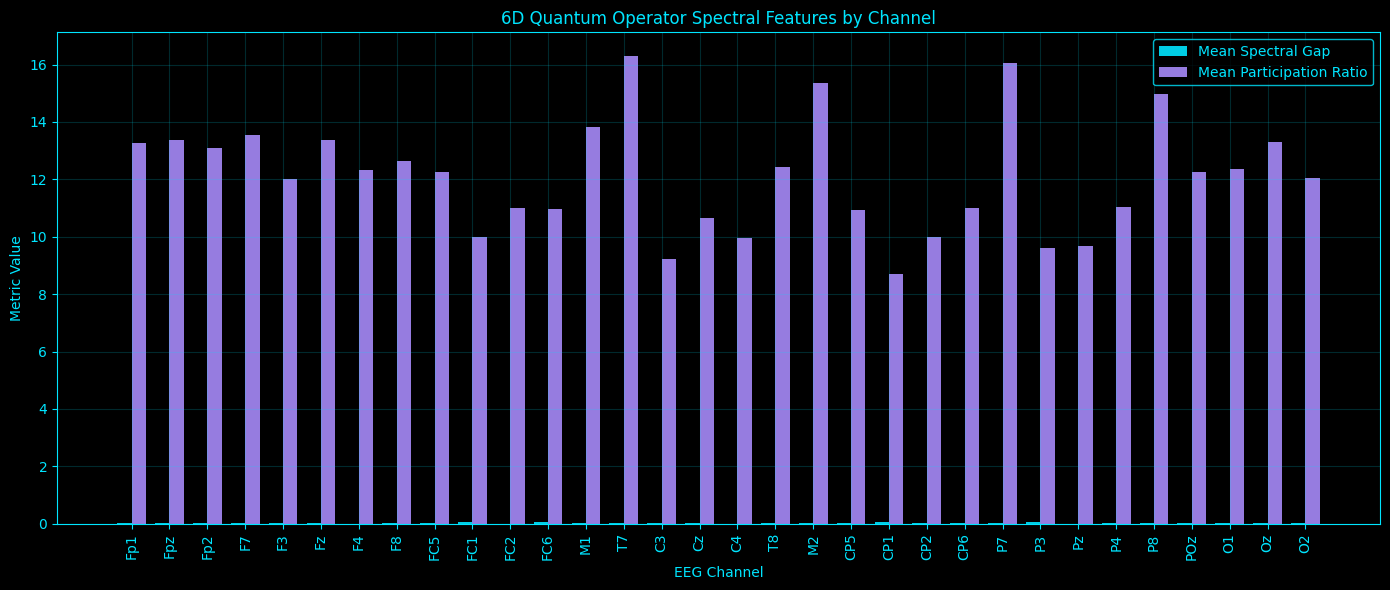

[    70.4s] Displayed plot: operator_6d_channel_spectral_features.png
[    70.6s] Saved plot: operator_6d_channel_energy_localization.png


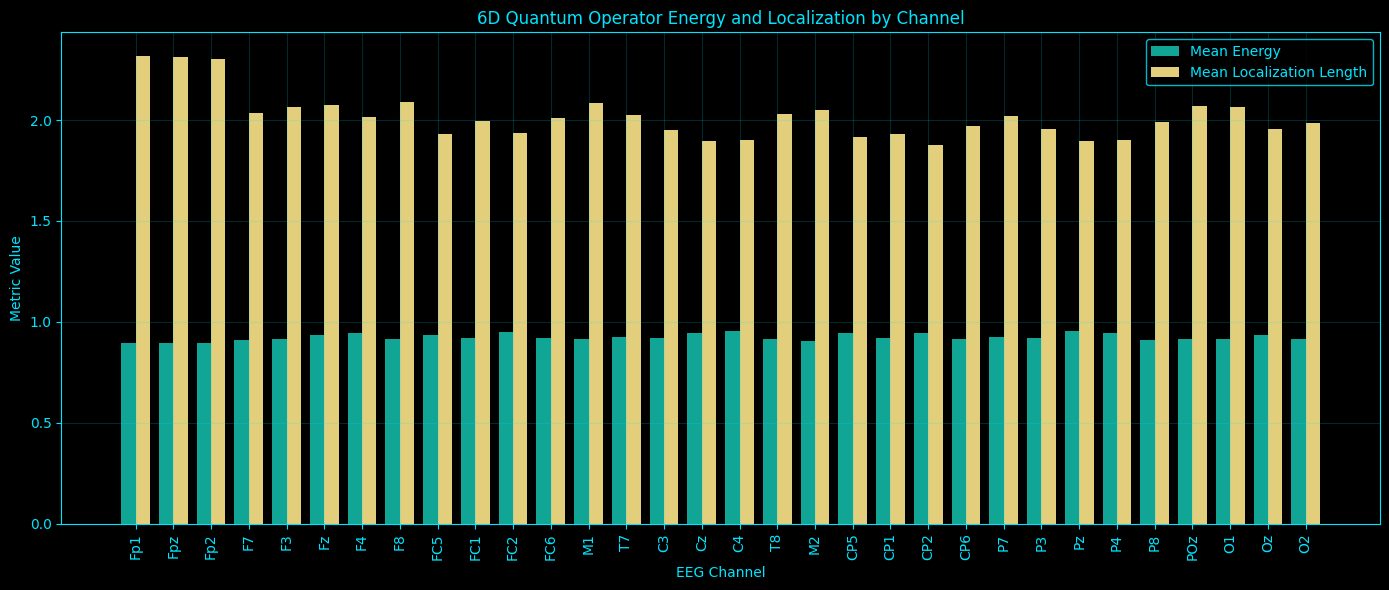

[    70.7s] Displayed plot: operator_6d_channel_energy_localization.png
[    71.0s] Saved plot: operator_6d_channel_eigenspectrum.png


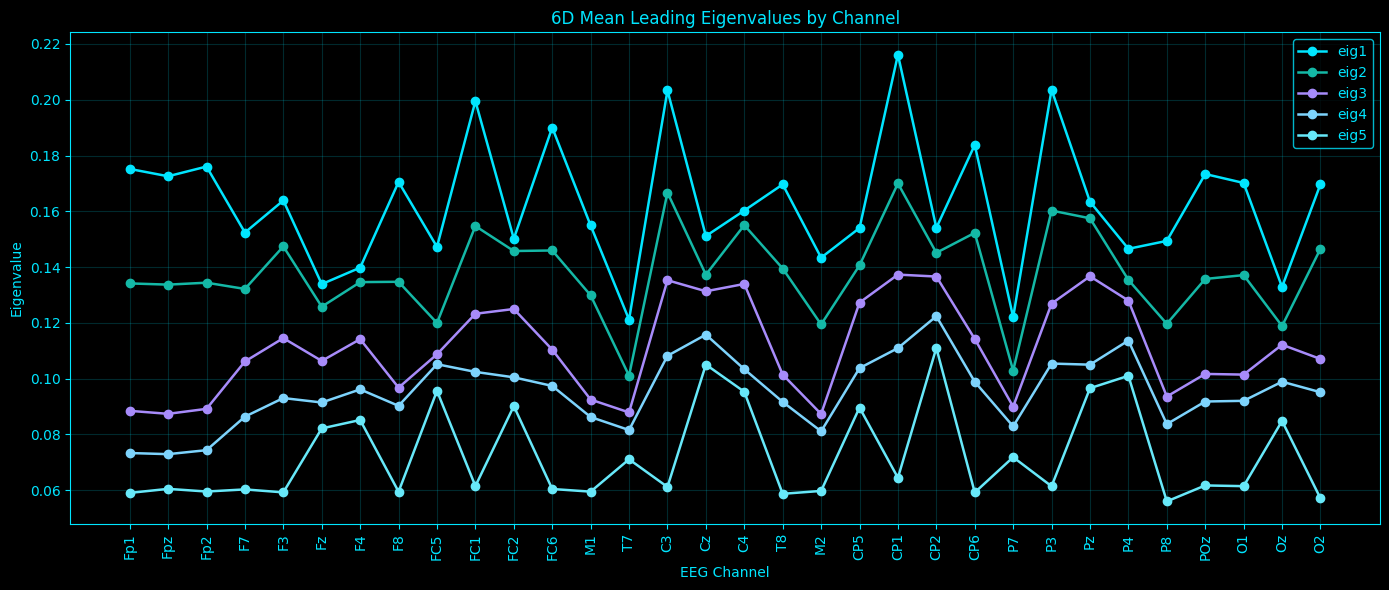

[    71.1s] Displayed plot: operator_6d_channel_eigenspectrum.png
[    71.3s] Saved plot: operator_6d_selected_spectral_gap_time.png


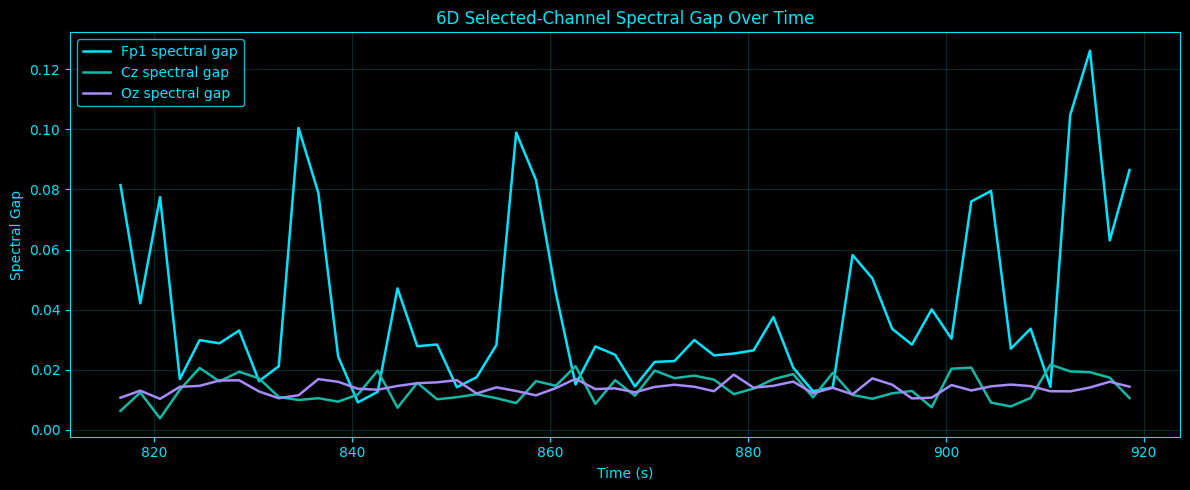

[    71.3s] Displayed plot: operator_6d_selected_spectral_gap_time.png
[    71.5s] Saved plot: operator_6d_selected_energy_time.png


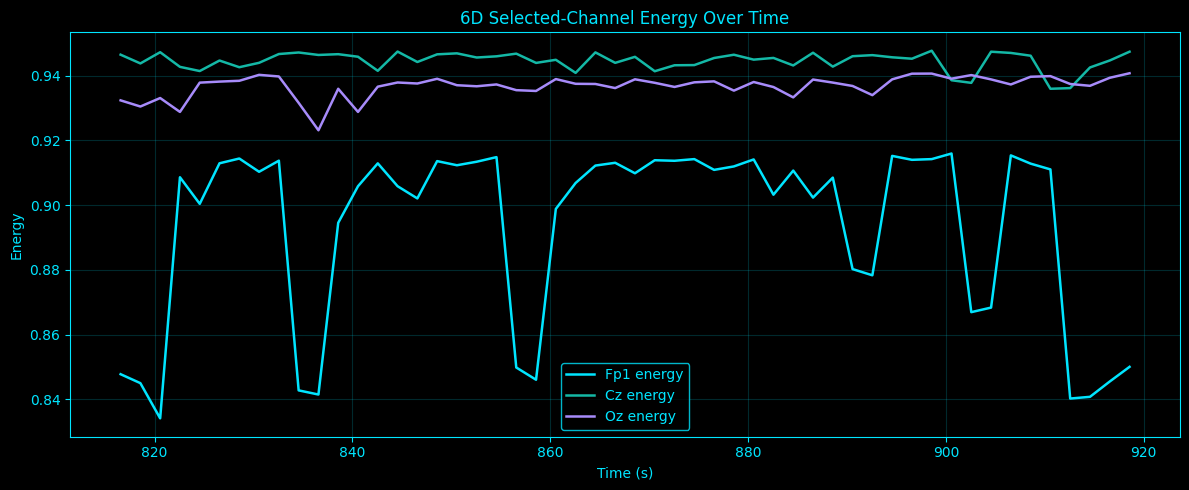

[    71.5s] Displayed plot: operator_6d_selected_energy_time.png
[    71.9s] Saved plot: operator_6d_channel_flow_features.png


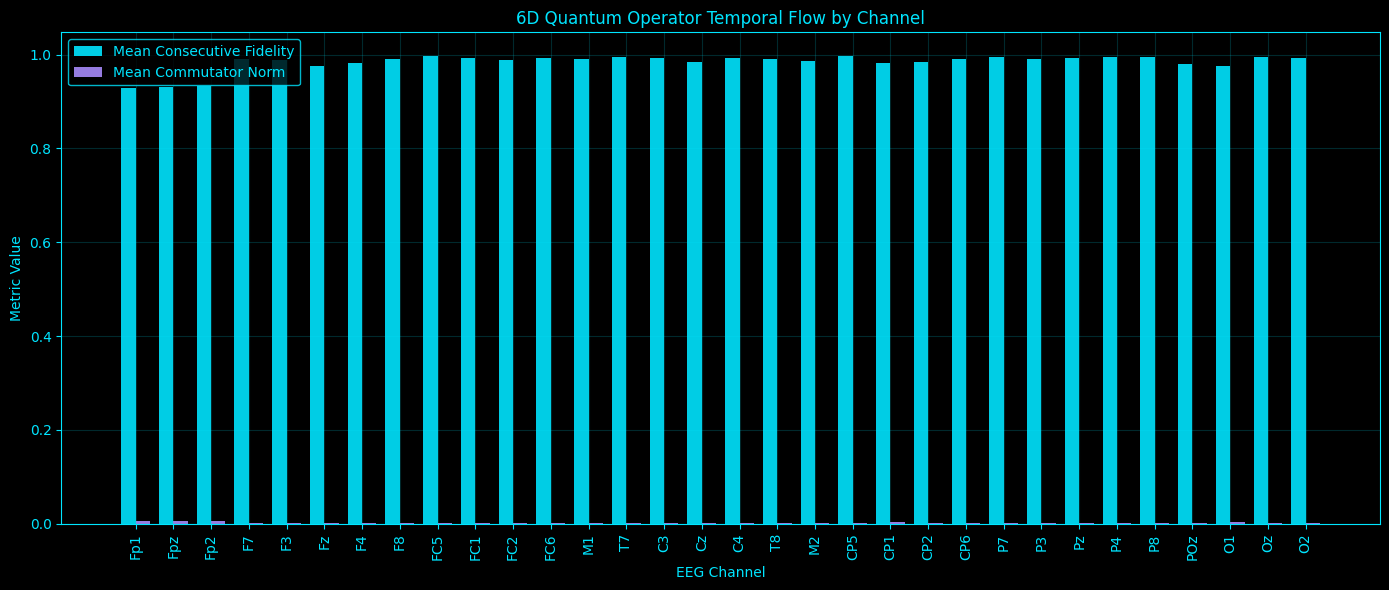

[    72.0s] Displayed plot: operator_6d_channel_flow_features.png
[    72.1s] Saved plot: operator_6d_time_summary.png


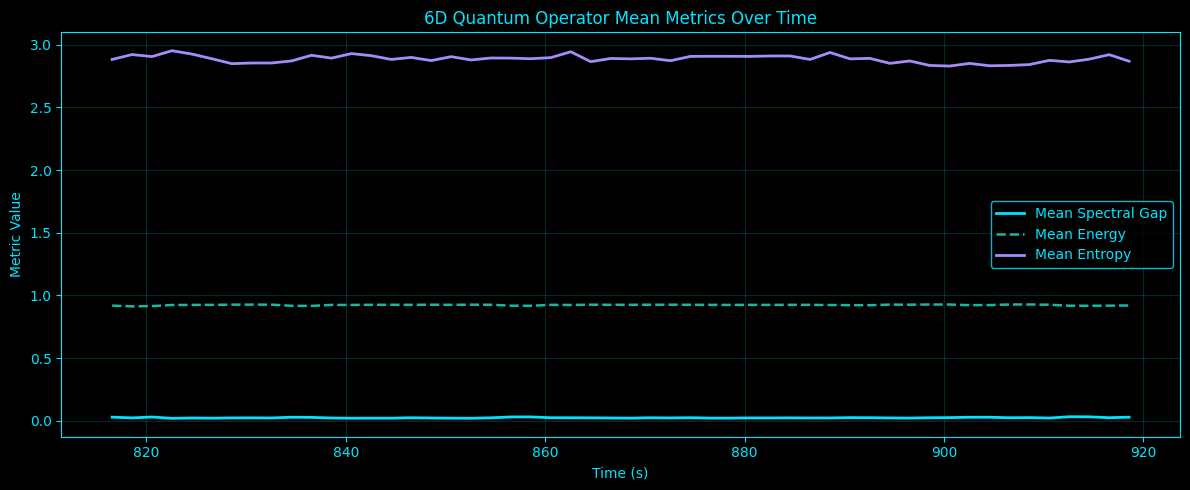

[    72.2s] Displayed plot: operator_6d_time_summary.png
[    72.3s] Saved plot: operator_6d_flow_time_summary.png


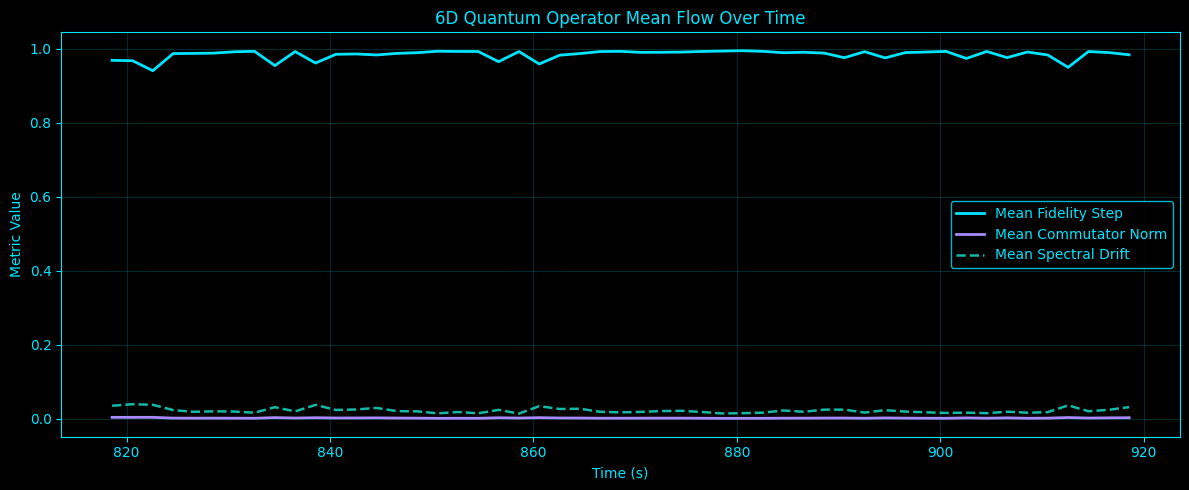

[    72.4s] Displayed plot: operator_6d_flow_time_summary.png
[    72.8s] Saved plot: operator_6d_channel_fidelity_heatmap.png


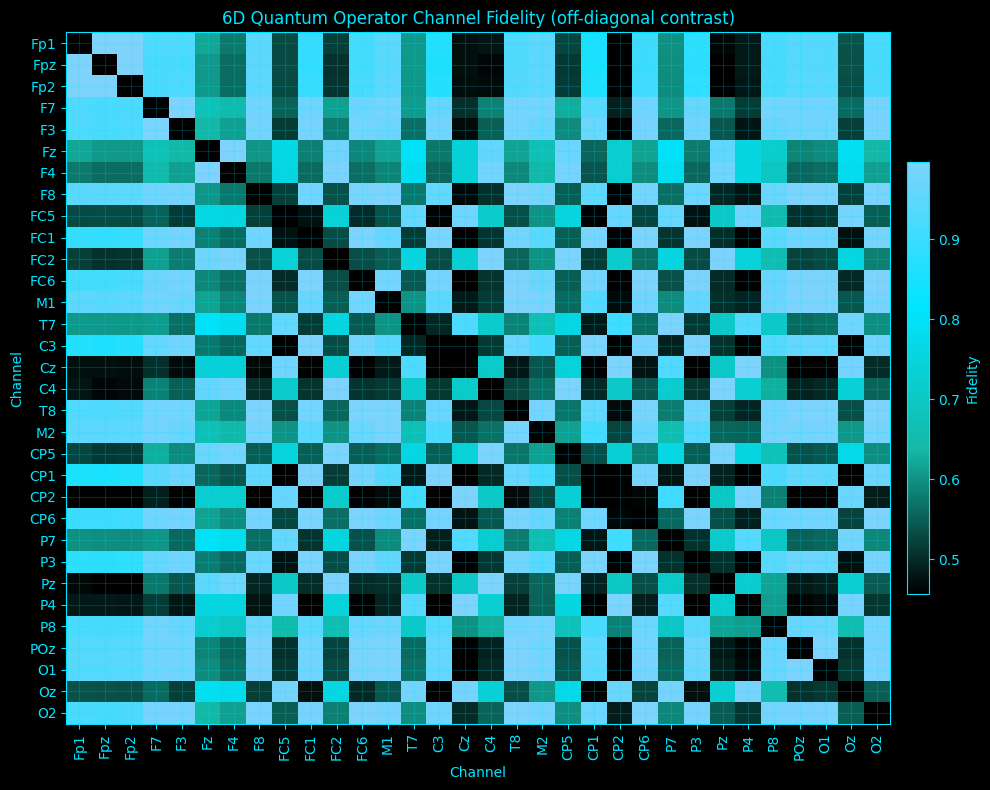

[    72.9s] Displayed plot: operator_6d_channel_fidelity_heatmap.png
[    72.9s] Starting advanced operator analysis for 7D
[    72.9s] 7D loaded 1/32: Fp1 shape=(106920, 7)
[    73.0s] 7D loaded 4/32: F7 shape=(106920, 7)
[    73.0s] 7D loaded 8/32: F8 shape=(106920, 7)
[    73.0s] 7D loaded 12/32: FC6 shape=(106920, 7)
[    73.1s] 7D loaded 16/32: Cz shape=(106932, 7)
[    73.1s] 7D loaded 20/32: CP5 shape=(106926, 7)
[    73.1s] 7D loaded 24/32: P7 shape=(106932, 7)
[    73.2s] 7D loaded 28/32: P8 shape=(106920, 7)
[    73.2s] 7D loaded 32/32: O2 shape=(106920, 7)
[    73.2s] 7D common length across channels: 106920
[    73.2s] 7D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[    73.2s] 7D fitting codebook | pool_shape=(80000, 7) | states=40
[    73.3s] 7D codebook fit complete | sigma2=0.841646
[    73.3s] 7D Hamiltonian built | graph_sigma=2.854333
[    73.3s] 7D Fp1 window 1/52 | gap=0.05929 | PR=6.969 | E=0.83078
[    73.5s] 7D Fp1 window 20/52 | gap=0.0272

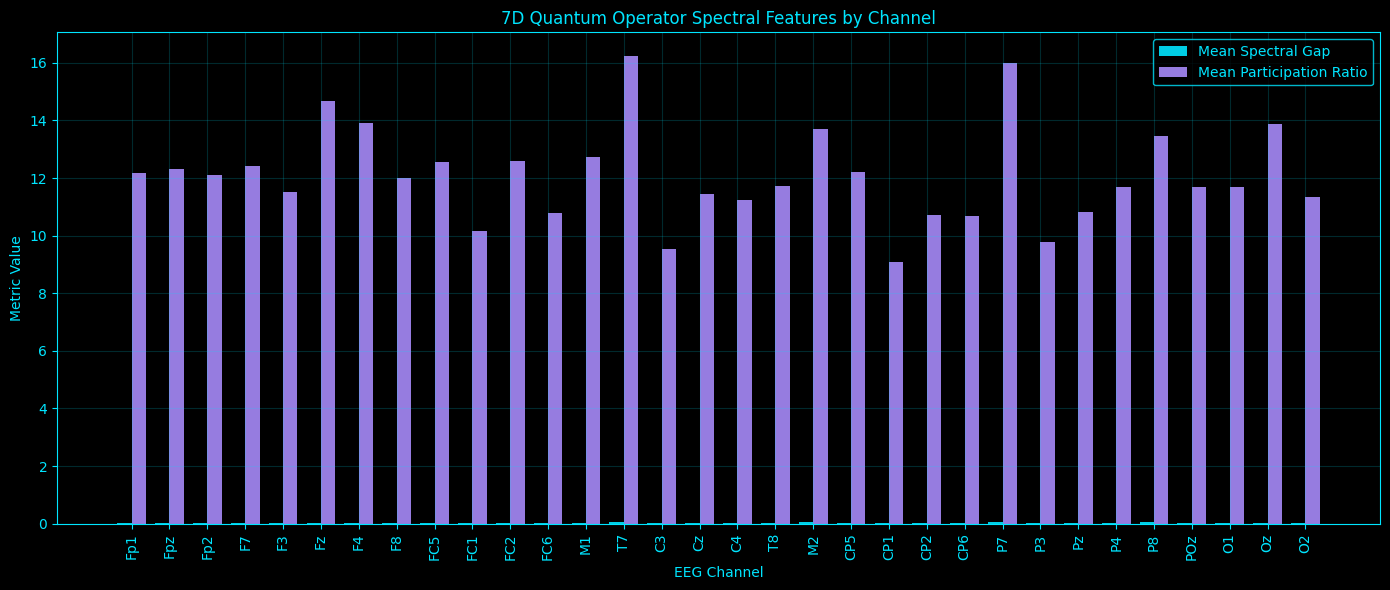

[    89.4s] Displayed plot: operator_7d_channel_spectral_features.png
[    89.7s] Saved plot: operator_7d_channel_energy_localization.png


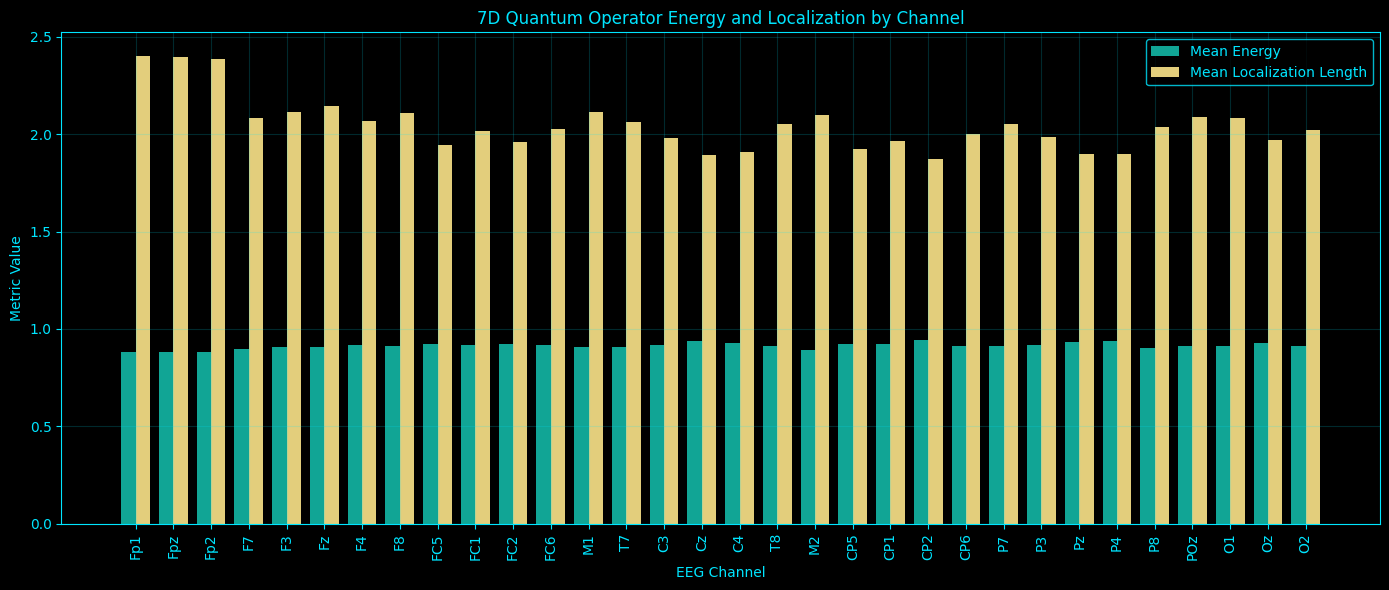

[    89.8s] Displayed plot: operator_7d_channel_energy_localization.png
[    90.0s] Saved plot: operator_7d_channel_eigenspectrum.png


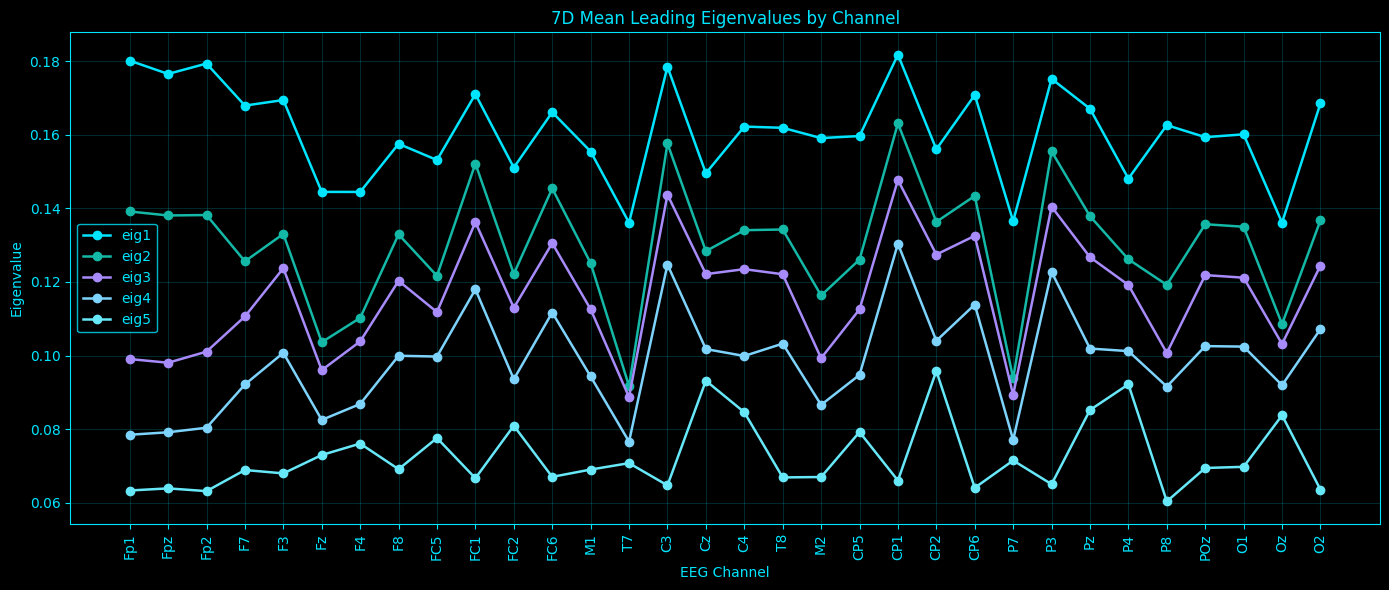

[    90.1s] Displayed plot: operator_7d_channel_eigenspectrum.png
[    90.3s] Saved plot: operator_7d_selected_spectral_gap_time.png


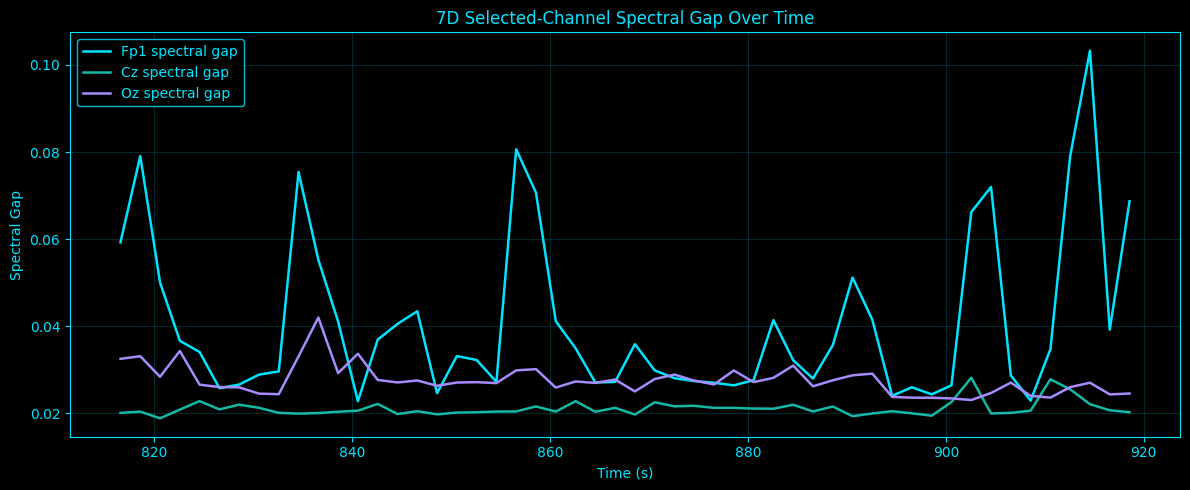

[    90.3s] Displayed plot: operator_7d_selected_spectral_gap_time.png
[    90.5s] Saved plot: operator_7d_selected_energy_time.png


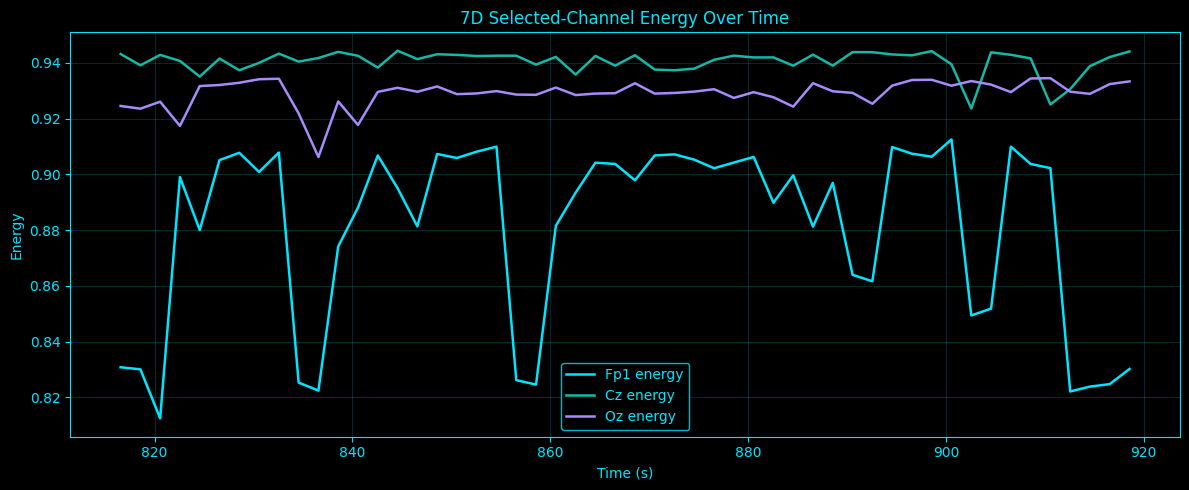

[    90.6s] Displayed plot: operator_7d_selected_energy_time.png
[    90.9s] Saved plot: operator_7d_channel_flow_features.png


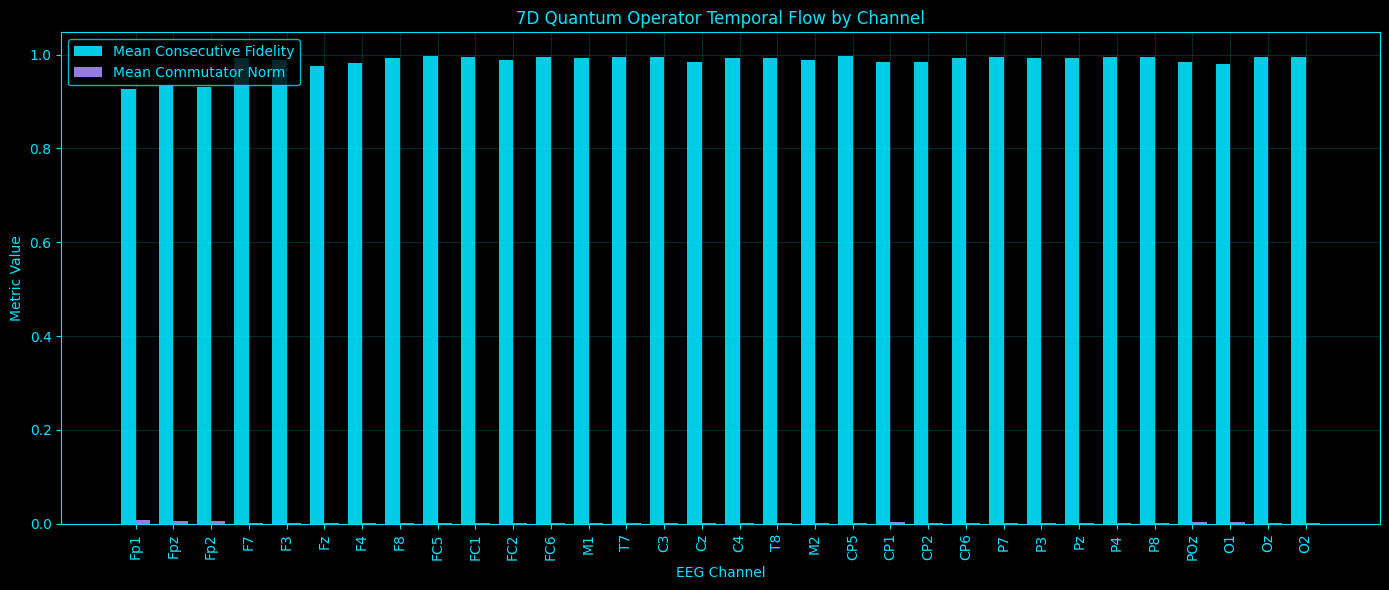

[    91.0s] Displayed plot: operator_7d_channel_flow_features.png
[    91.2s] Saved plot: operator_7d_time_summary.png


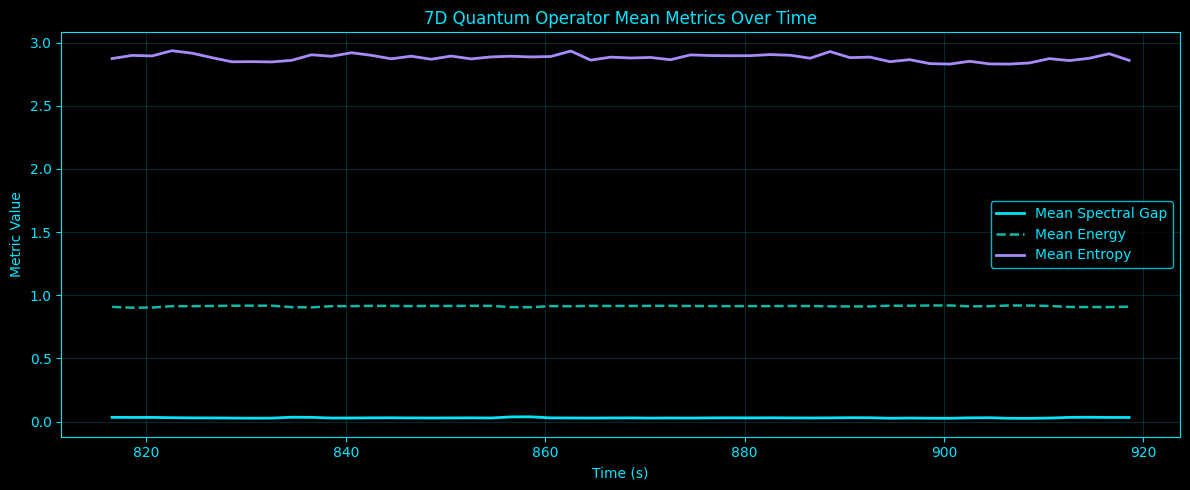

[    91.2s] Displayed plot: operator_7d_time_summary.png
[    91.4s] Saved plot: operator_7d_flow_time_summary.png


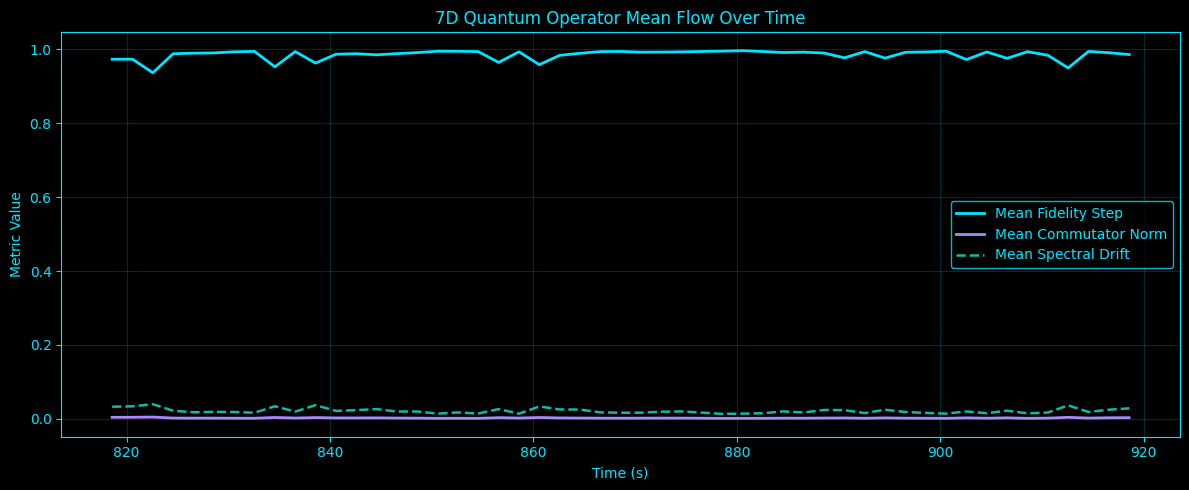

[    91.4s] Displayed plot: operator_7d_flow_time_summary.png
[    91.8s] Saved plot: operator_7d_channel_fidelity_heatmap.png


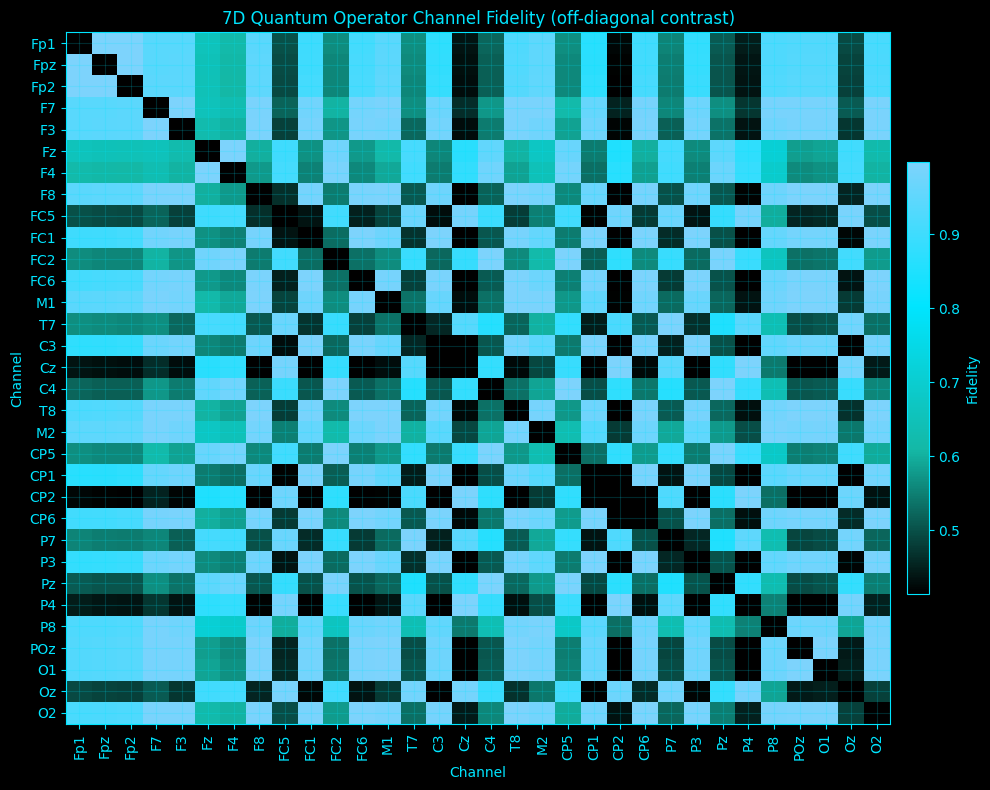

[    91.9s] Displayed plot: operator_7d_channel_fidelity_heatmap.png
[    91.9s] Starting advanced operator analysis for 8D
[    92.0s] 8D loaded 1/32: Fp1 shape=(106916, 8)
[    92.0s] 8D loaded 4/32: F7 shape=(106916, 8)
[    92.0s] 8D loaded 8/32: F8 shape=(106916, 8)
[    92.0s] 8D loaded 12/32: FC6 shape=(106916, 8)
[    92.1s] 8D loaded 16/32: Cz shape=(106930, 8)
[    92.1s] 8D loaded 20/32: CP5 shape=(106923, 8)
[    92.1s] 8D loaded 24/32: P7 shape=(106930, 8)
[    92.2s] 8D loaded 28/32: P8 shape=(106916, 8)
[    92.2s] 8D loaded 32/32: O2 shape=(106916, 8)
[    92.2s] 8D common length across channels: 106916
[    92.2s] 8D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[    92.2s] 8D fitting codebook | pool_shape=(80000, 8) | states=48
[    92.4s] 8D codebook fit complete | sigma2=0.967515
[    92.4s] 8D Hamiltonian built | graph_sigma=3.103990
[    92.4s] 8D Fp1 window 1/52 | gap=0.07429 | PR=9.420 | E=0.85197
[    92.6s] 8D Fp1 window 20/52 | gap=0.0309

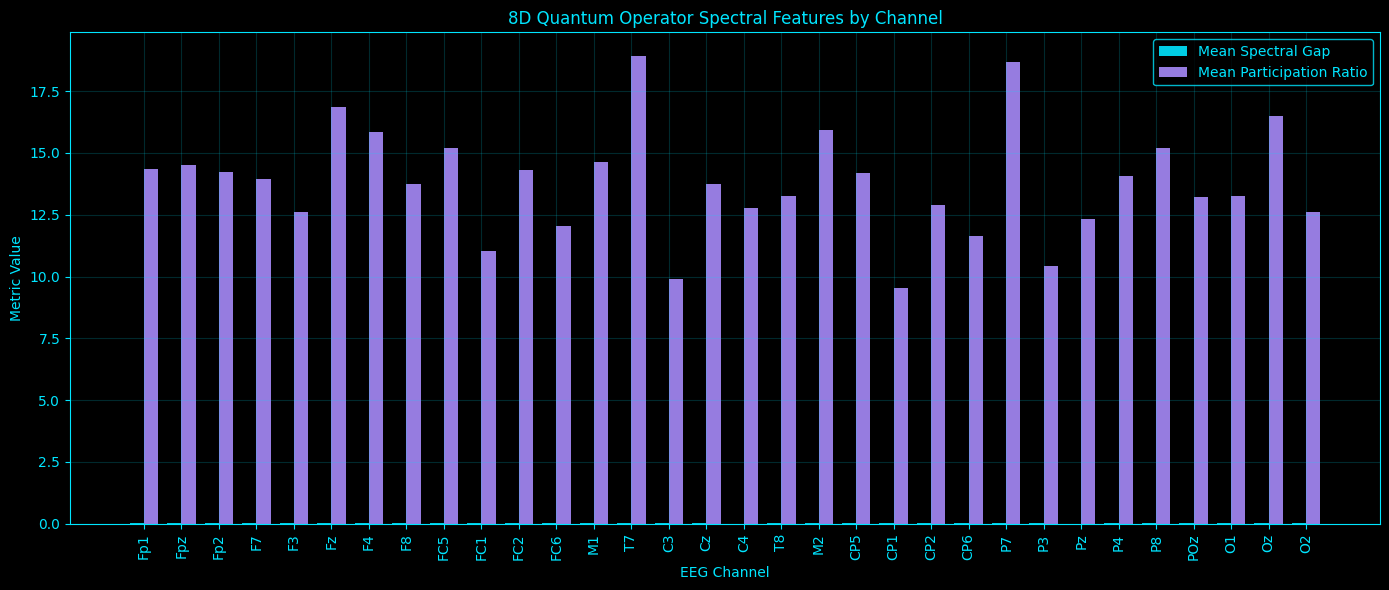

[   118.0s] Displayed plot: operator_8d_channel_spectral_features.png
[   118.2s] Saved plot: operator_8d_channel_energy_localization.png


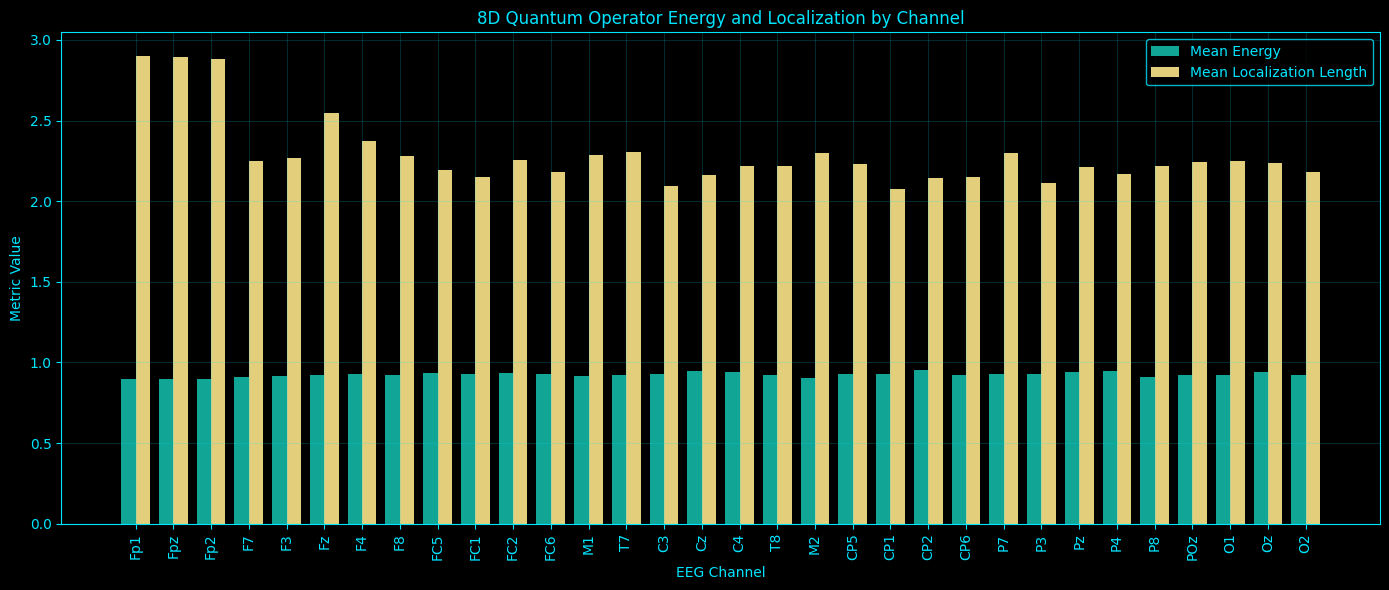

[   118.4s] Displayed plot: operator_8d_channel_energy_localization.png
[   118.6s] Saved plot: operator_8d_channel_eigenspectrum.png


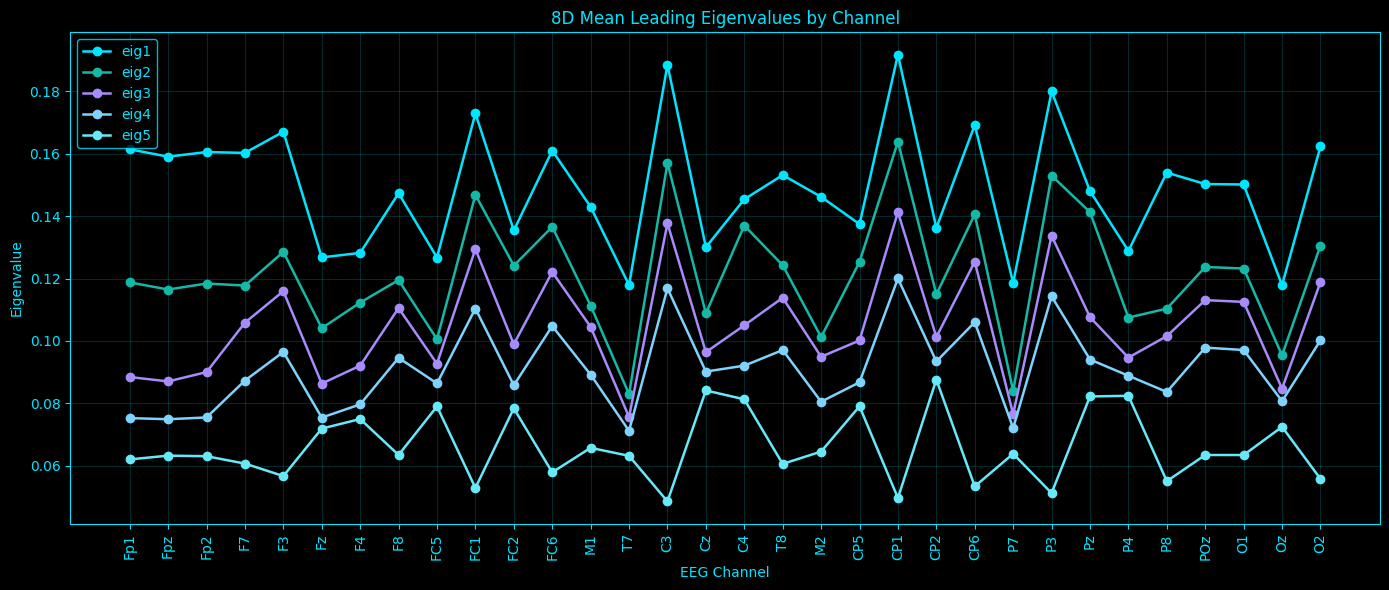

[   118.7s] Displayed plot: operator_8d_channel_eigenspectrum.png
[   118.9s] Saved plot: operator_8d_selected_spectral_gap_time.png


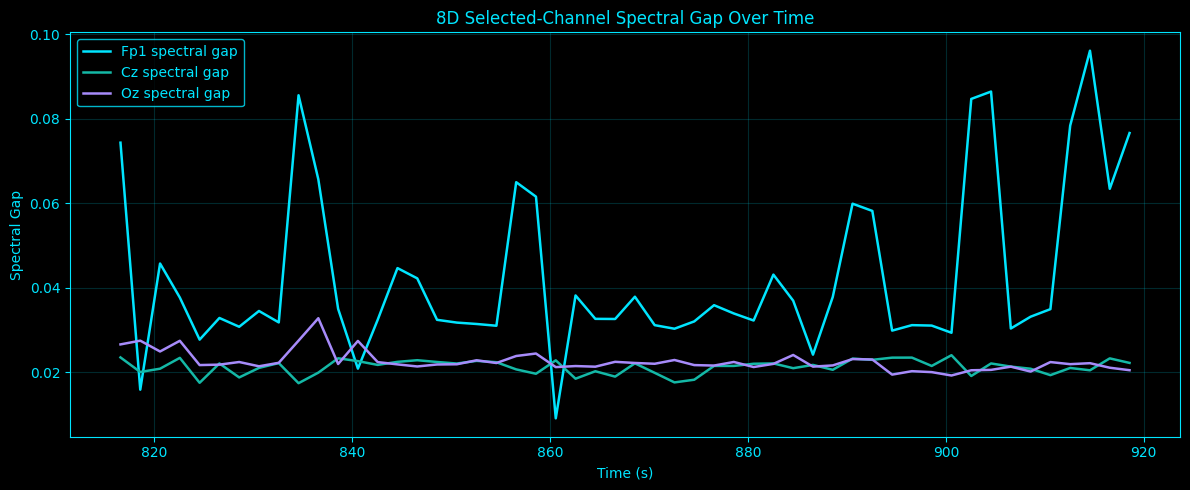

[   118.9s] Displayed plot: operator_8d_selected_spectral_gap_time.png
[   119.1s] Saved plot: operator_8d_selected_energy_time.png


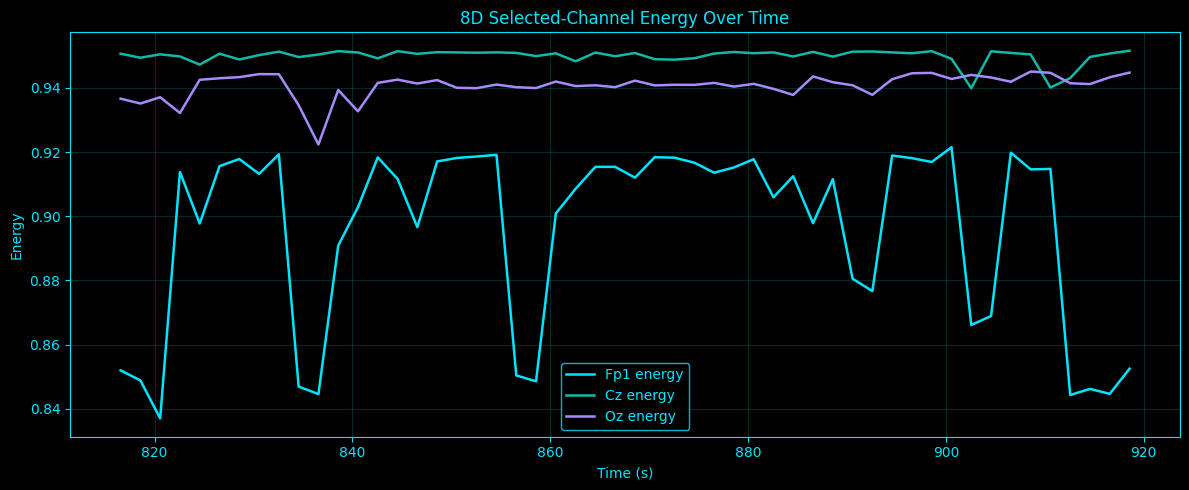

[   119.1s] Displayed plot: operator_8d_selected_energy_time.png
[   119.4s] Saved plot: operator_8d_channel_flow_features.png


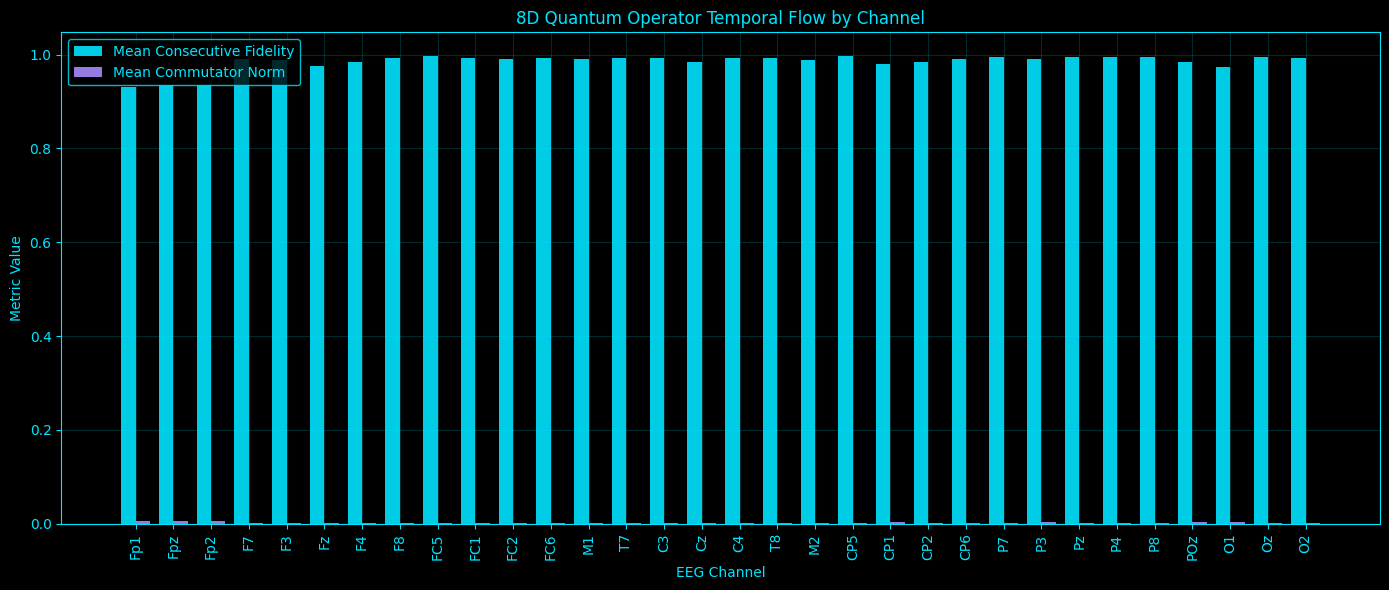

[   119.5s] Displayed plot: operator_8d_channel_flow_features.png
[   119.6s] Saved plot: operator_8d_time_summary.png


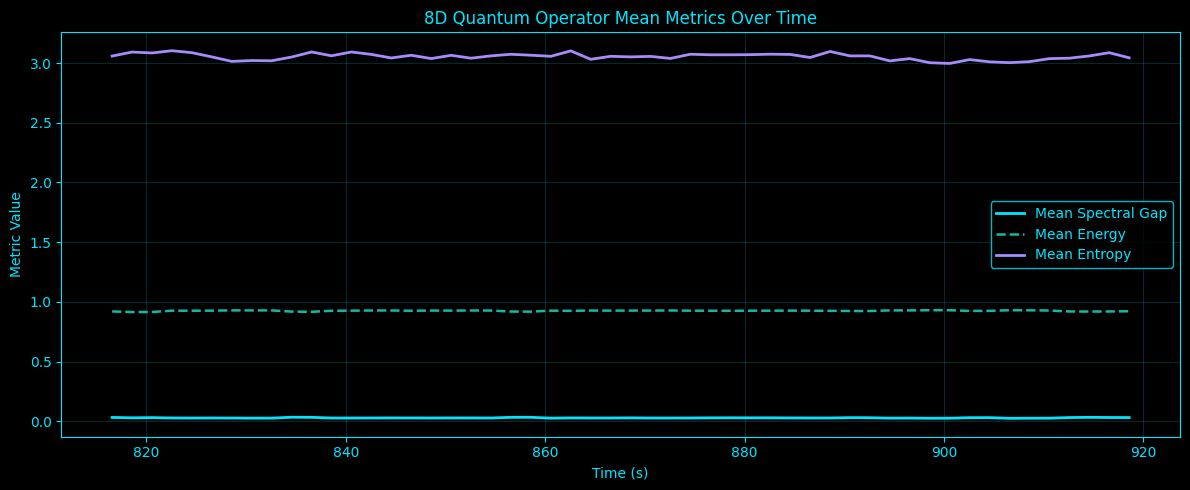

[   119.7s] Displayed plot: operator_8d_time_summary.png
[   120.0s] Saved plot: operator_8d_flow_time_summary.png


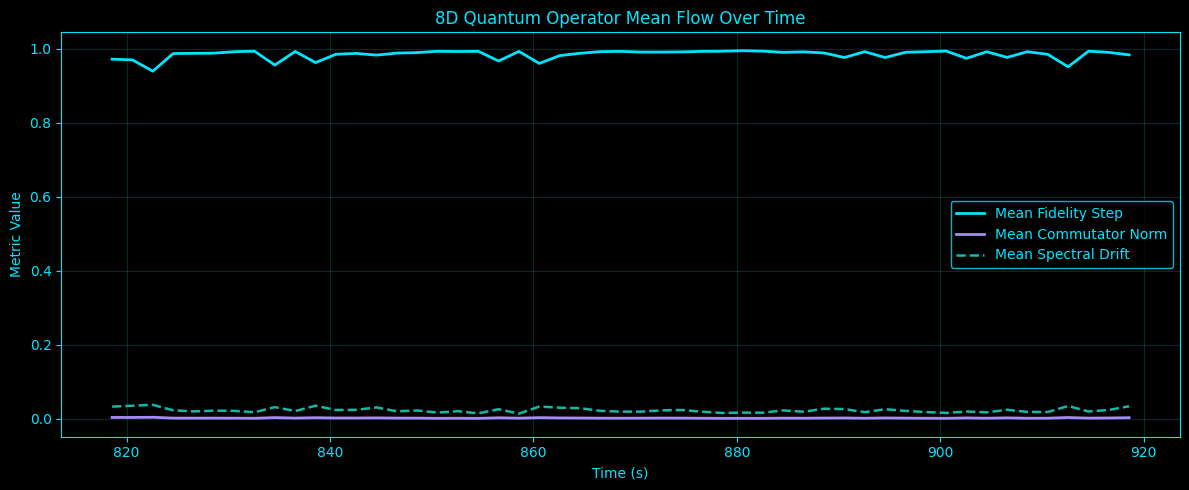

[   120.0s] Displayed plot: operator_8d_flow_time_summary.png
[   120.4s] Saved plot: operator_8d_channel_fidelity_heatmap.png


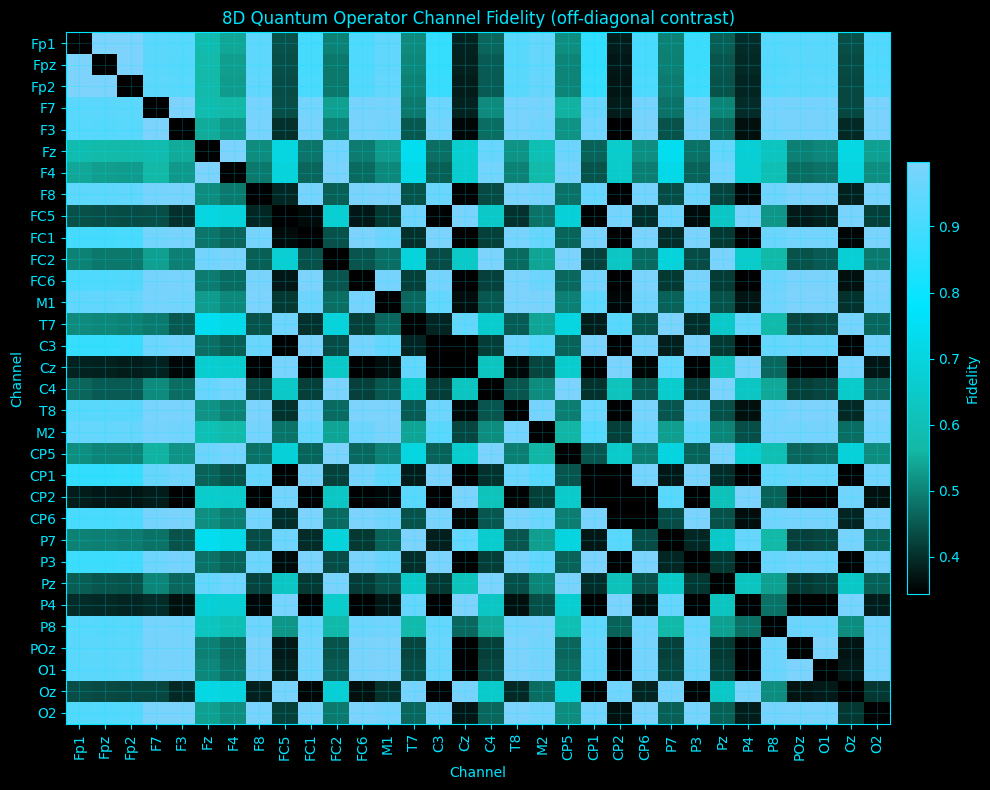

[   120.6s] Displayed plot: operator_8d_channel_fidelity_heatmap.png
[   120.6s] Starting advanced operator analysis for 9D
[   120.6s] 9D loaded 1/32: Fp1 shape=(106912, 9)
[   120.6s] 9D loaded 4/32: F7 shape=(106912, 9)
[   120.7s] 9D loaded 8/32: F8 shape=(106912, 9)
[   120.7s] 9D loaded 12/32: FC6 shape=(106912, 9)
[   120.7s] 9D loaded 16/32: Cz shape=(106928, 9)
[   120.8s] 9D loaded 20/32: CP5 shape=(106920, 9)
[   120.8s] 9D loaded 24/32: P7 shape=(106928, 9)
[   120.9s] 9D loaded 28/32: P8 shape=(106912, 9)
[   120.9s] 9D loaded 32/32: O2 shape=(106912, 9)
[   120.9s] 9D common length across channels: 106912
[   120.9s] 9D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[   120.9s] 9D fitting codebook | pool_shape=(80000, 9) | states=48
[   121.1s] 9D codebook fit complete | sigma2=1.133593
[   121.1s] 9D Hamiltonian built | graph_sigma=3.154544
[   121.1s] 9D Fp1 window 1/52 | gap=0.00576 | PR=7.983 | E=0.84586
[   121.4s] 9D Fp1 window 20/52 | gap=0.0395

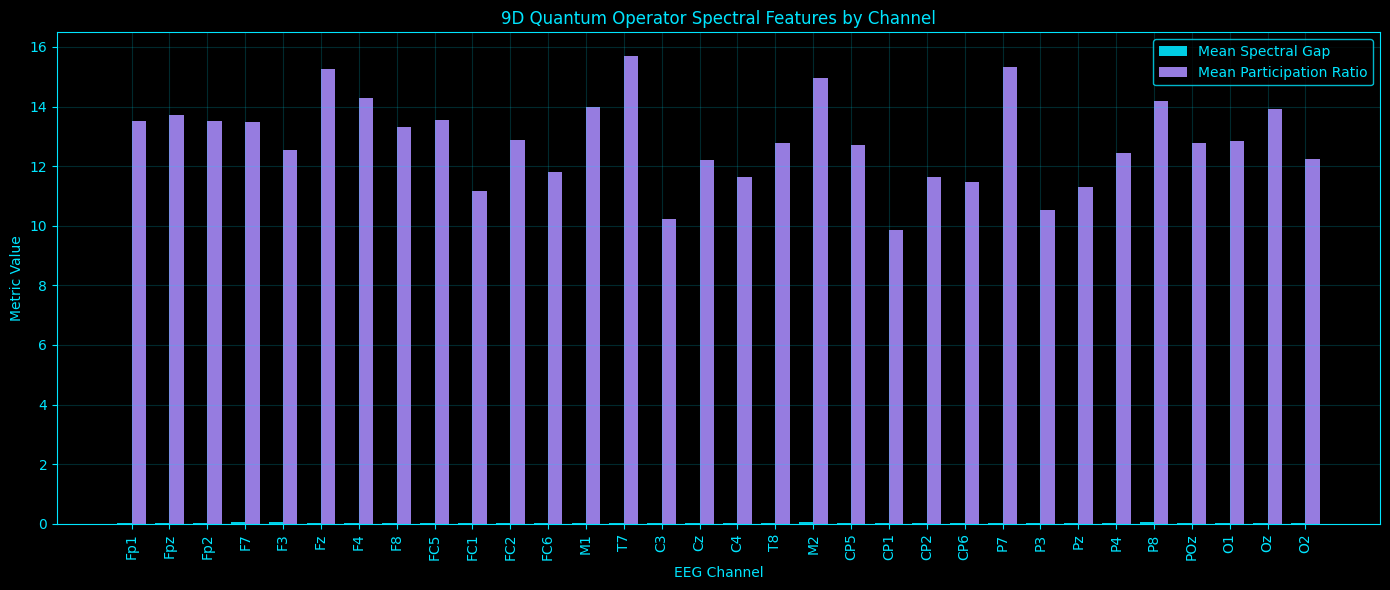

[   148.4s] Displayed plot: operator_9d_channel_spectral_features.png
[   148.7s] Saved plot: operator_9d_channel_energy_localization.png


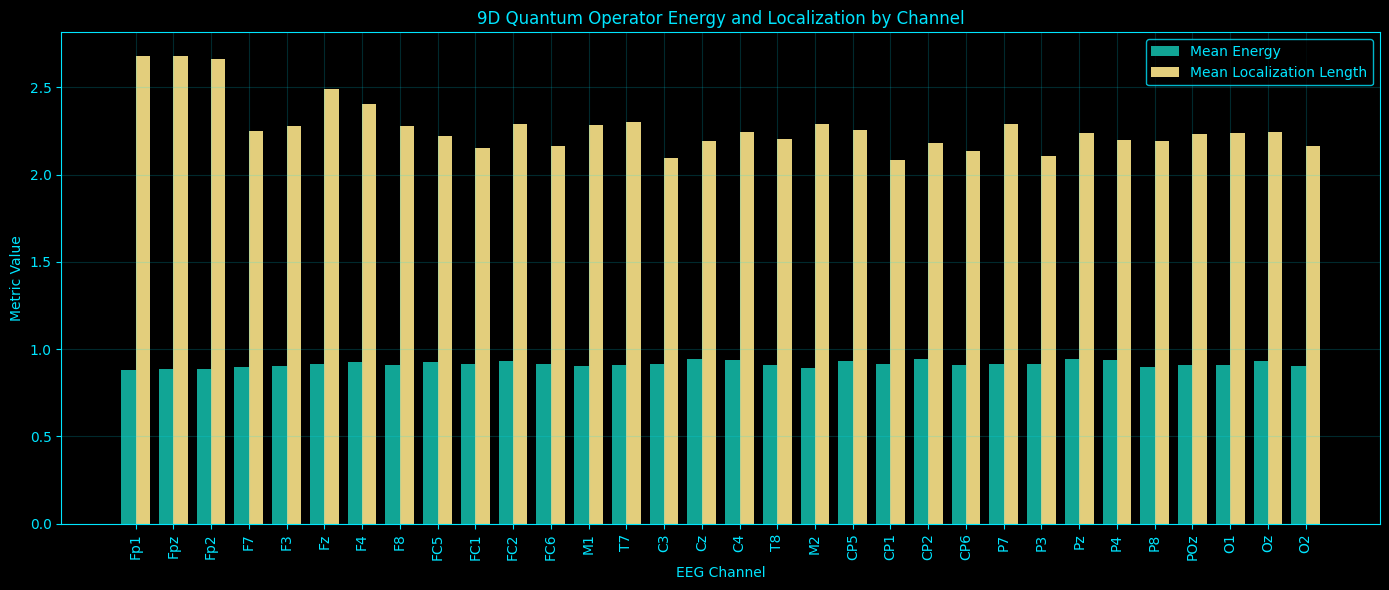

[   148.8s] Displayed plot: operator_9d_channel_energy_localization.png
[   149.1s] Saved plot: operator_9d_channel_eigenspectrum.png


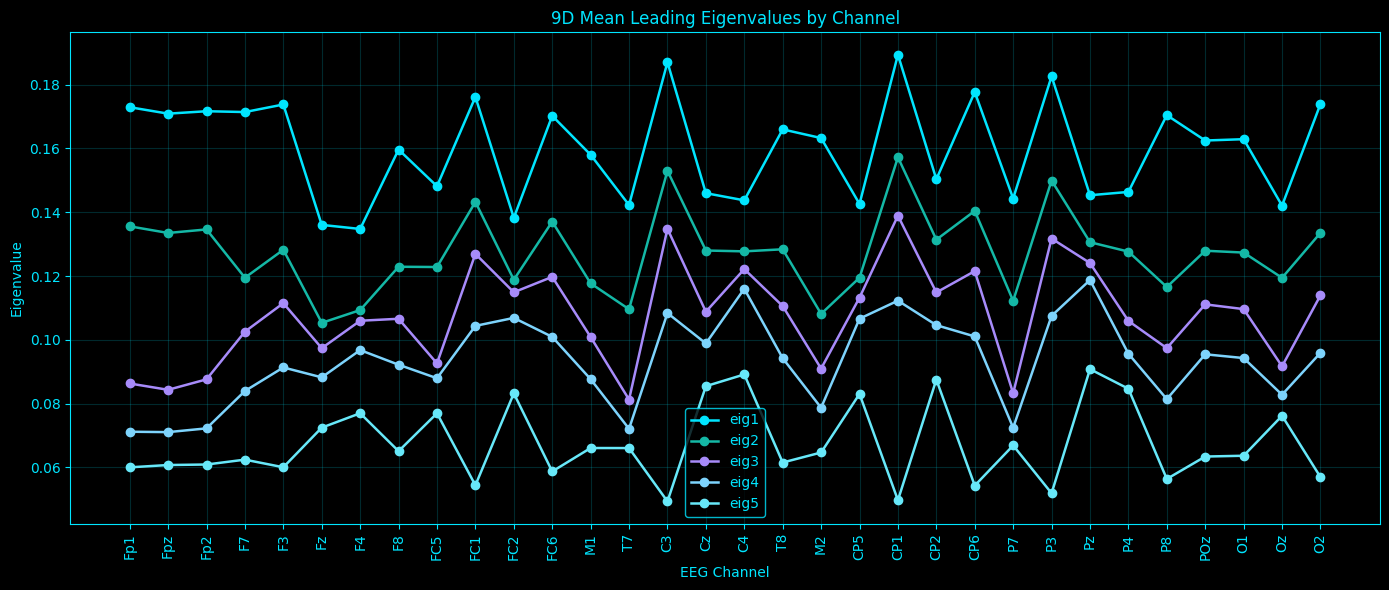

[   149.2s] Displayed plot: operator_9d_channel_eigenspectrum.png
[   149.3s] Saved plot: operator_9d_selected_spectral_gap_time.png


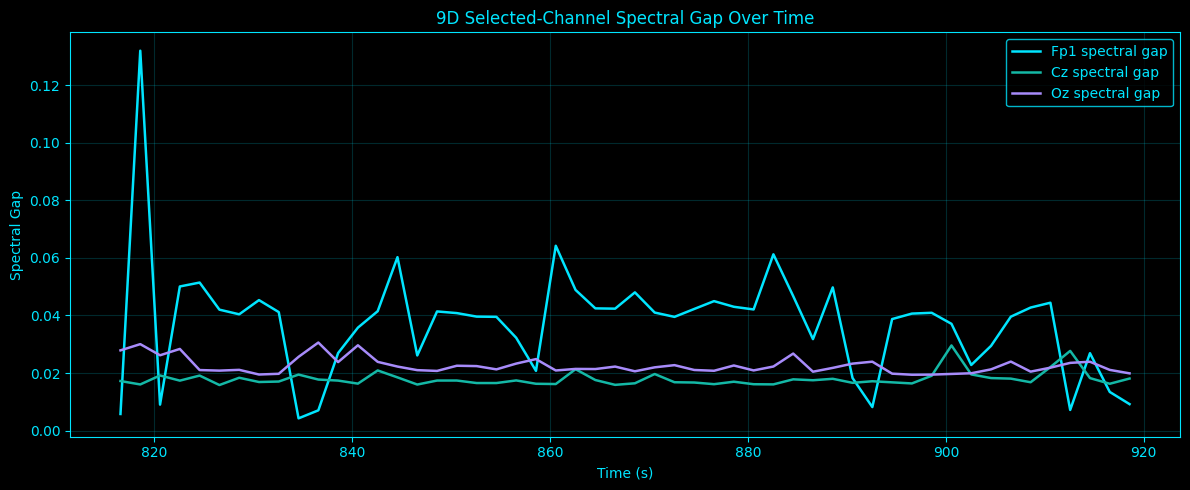

[   149.4s] Displayed plot: operator_9d_selected_spectral_gap_time.png
[   149.5s] Saved plot: operator_9d_selected_energy_time.png


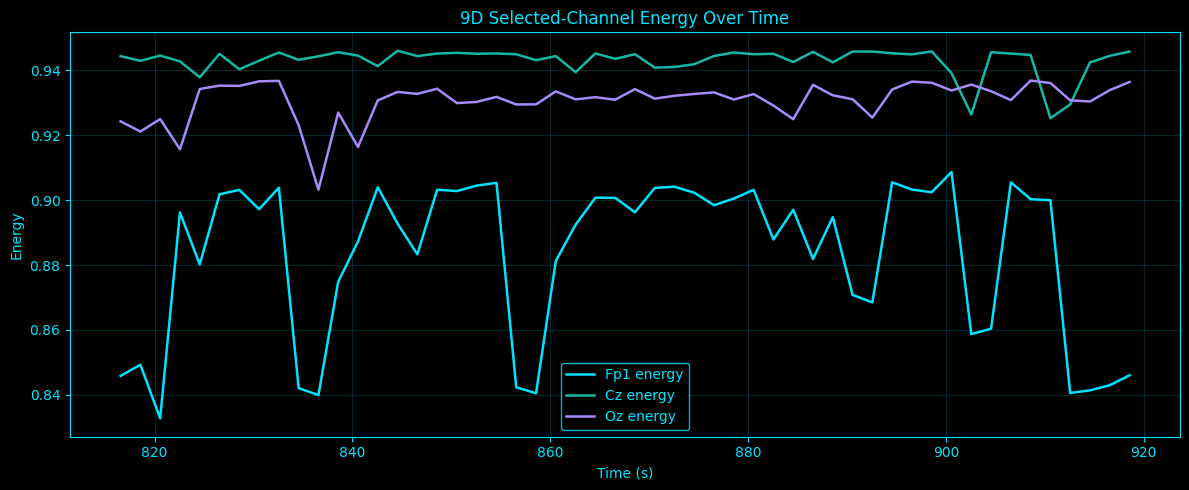

[   149.6s] Displayed plot: operator_9d_selected_energy_time.png
[   149.9s] Saved plot: operator_9d_channel_flow_features.png


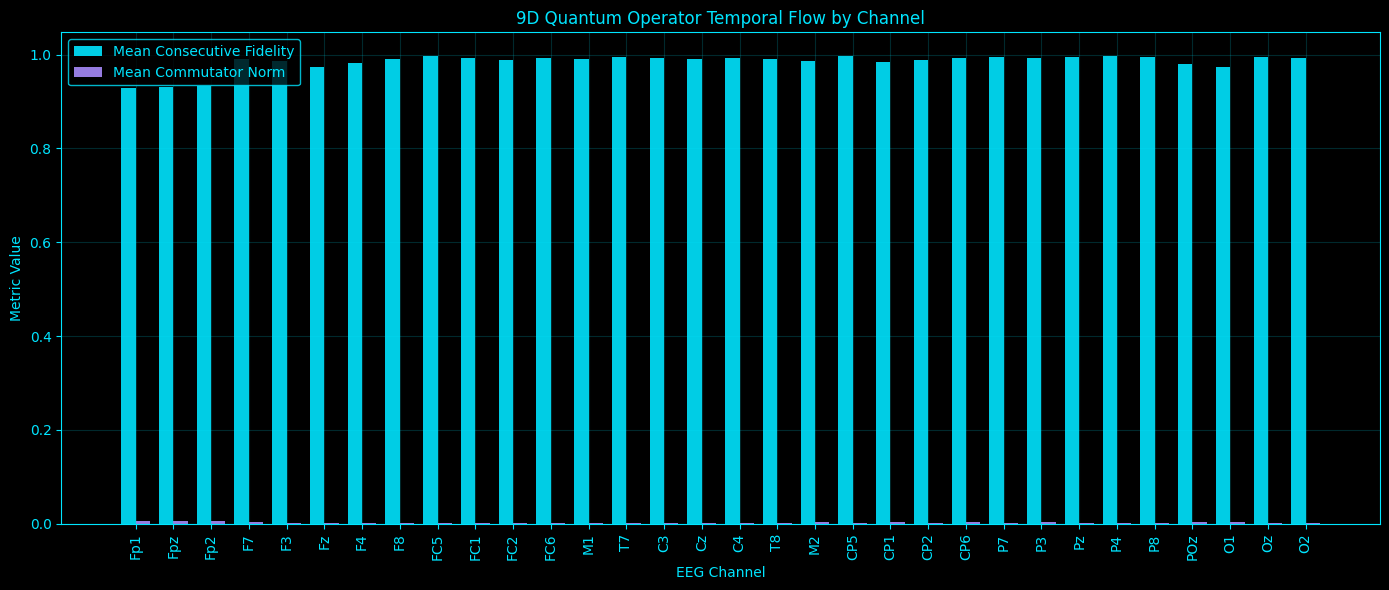

[   150.0s] Displayed plot: operator_9d_channel_flow_features.png
[   150.1s] Saved plot: operator_9d_time_summary.png


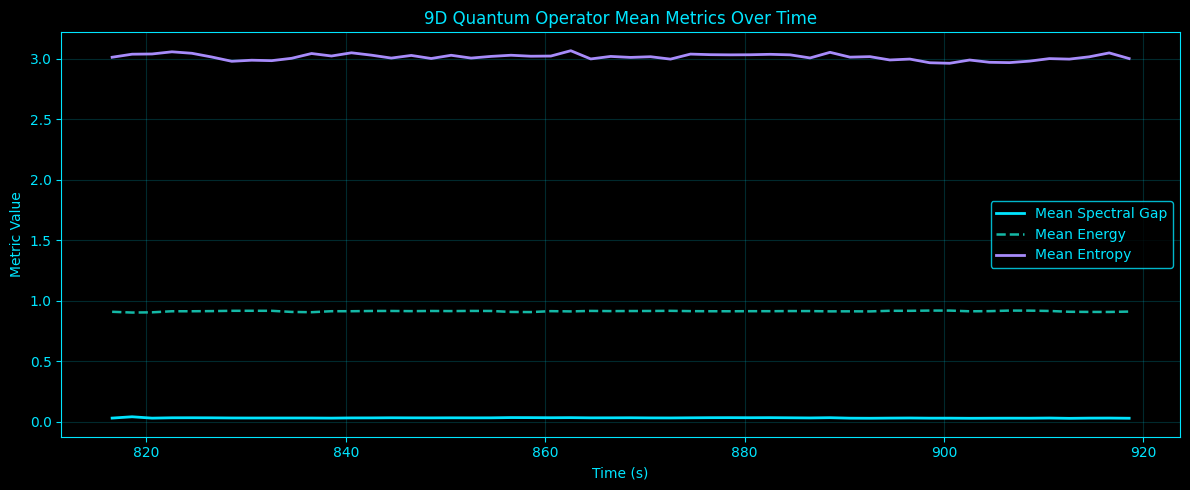

[   150.2s] Displayed plot: operator_9d_time_summary.png
[   150.3s] Saved plot: operator_9d_flow_time_summary.png


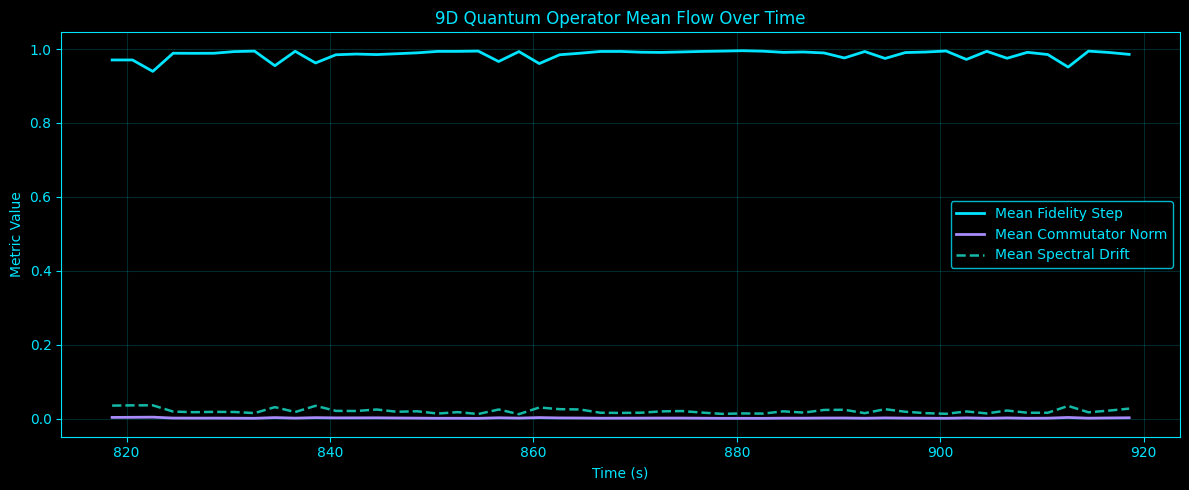

[   150.4s] Displayed plot: operator_9d_flow_time_summary.png
[   150.9s] Saved plot: operator_9d_channel_fidelity_heatmap.png


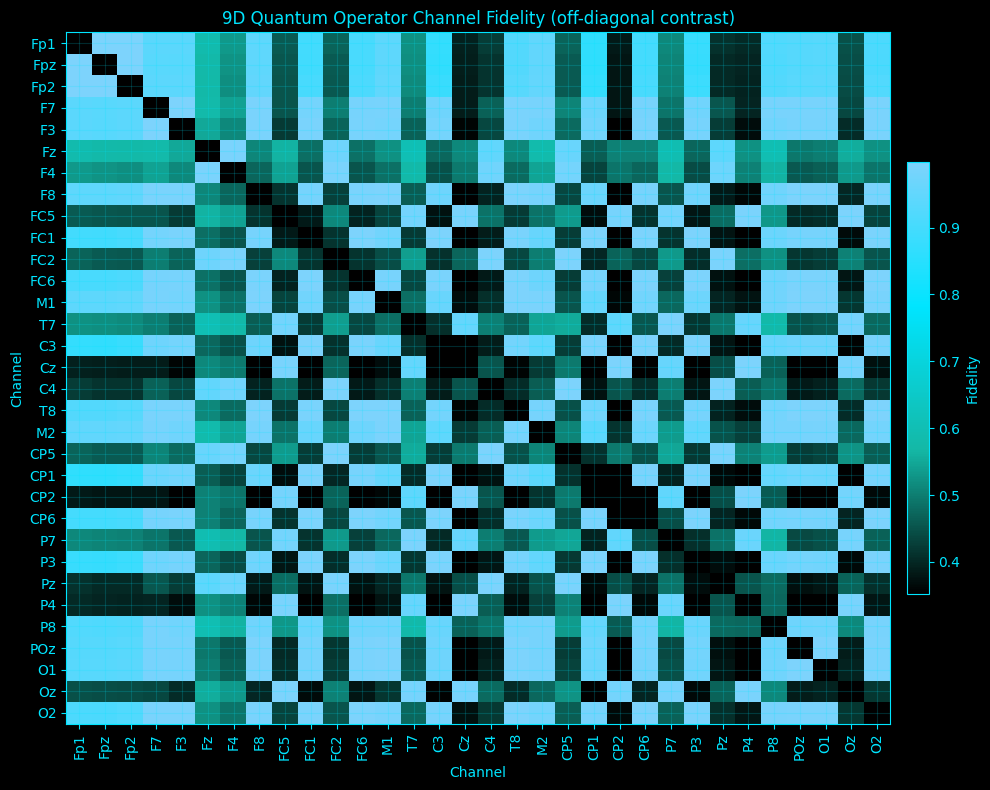

[   151.0s] Displayed plot: operator_9d_channel_fidelity_heatmap.png
[   151.0s] Starting advanced operator analysis for 10D
[   151.0s] 10D loaded 1/32: Fp1 shape=(106908, 10)
[   151.1s] 10D loaded 4/32: F7 shape=(106908, 10)
[   151.1s] 10D loaded 8/32: F8 shape=(106908, 10)
[   151.1s] 10D loaded 12/32: FC6 shape=(106908, 10)
[   151.2s] 10D loaded 16/32: Cz shape=(106926, 10)
[   151.2s] 10D loaded 20/32: CP5 shape=(106917, 10)
[   151.3s] 10D loaded 24/32: P7 shape=(106926, 10)
[   151.3s] 10D loaded 28/32: P8 shape=(106908, 10)
[   151.4s] 10D loaded 32/32: O2 shape=(106908, 10)
[   151.4s] 10D common length across channels: 106908
[   151.4s] 10D windowing | window=4.00s (4000) | step=2.00s (2000) | n_windows=52
[   151.4s] 10D fitting codebook | pool_shape=(80000, 10) | states=56
[   151.5s] 10D codebook fit complete | sigma2=1.266609
[   151.5s] 10D Hamiltonian built | graph_sigma=3.375960
[   151.6s] 10D Fp1 window 1/52 | gap=0.00920 | PR=9.761 | E=0.85911
[   152.0s] 10D Fp

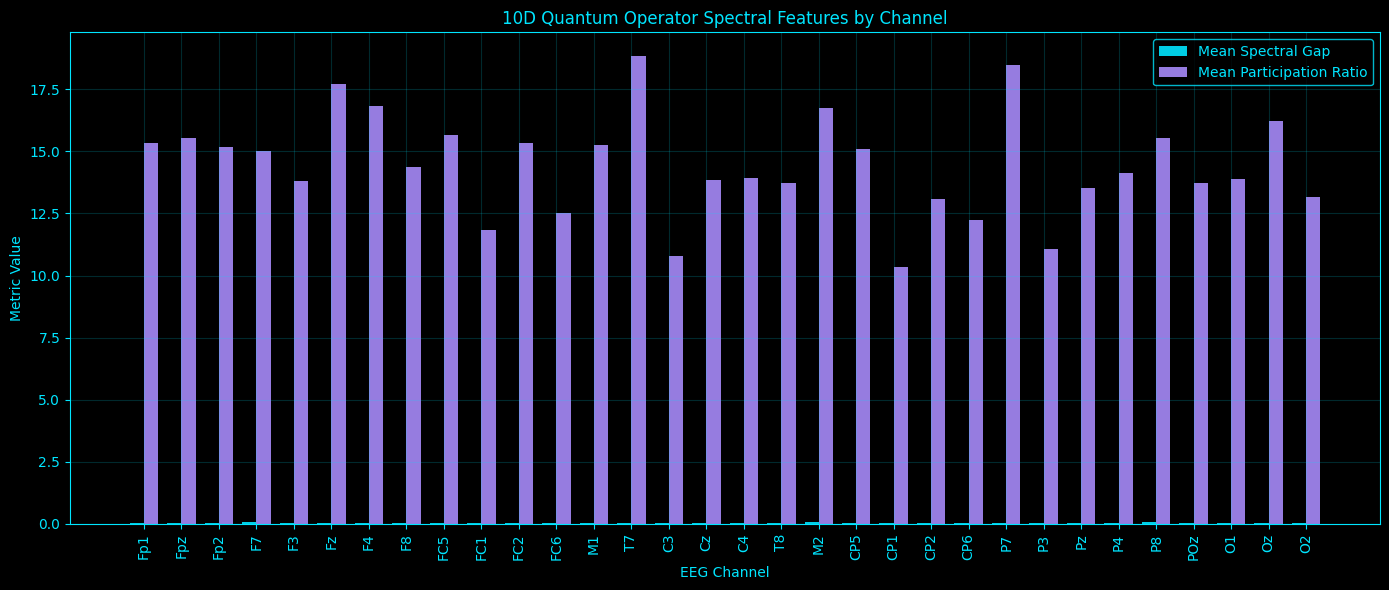

[   184.1s] Displayed plot: operator_10d_channel_spectral_features.png
[   184.3s] Saved plot: operator_10d_channel_energy_localization.png


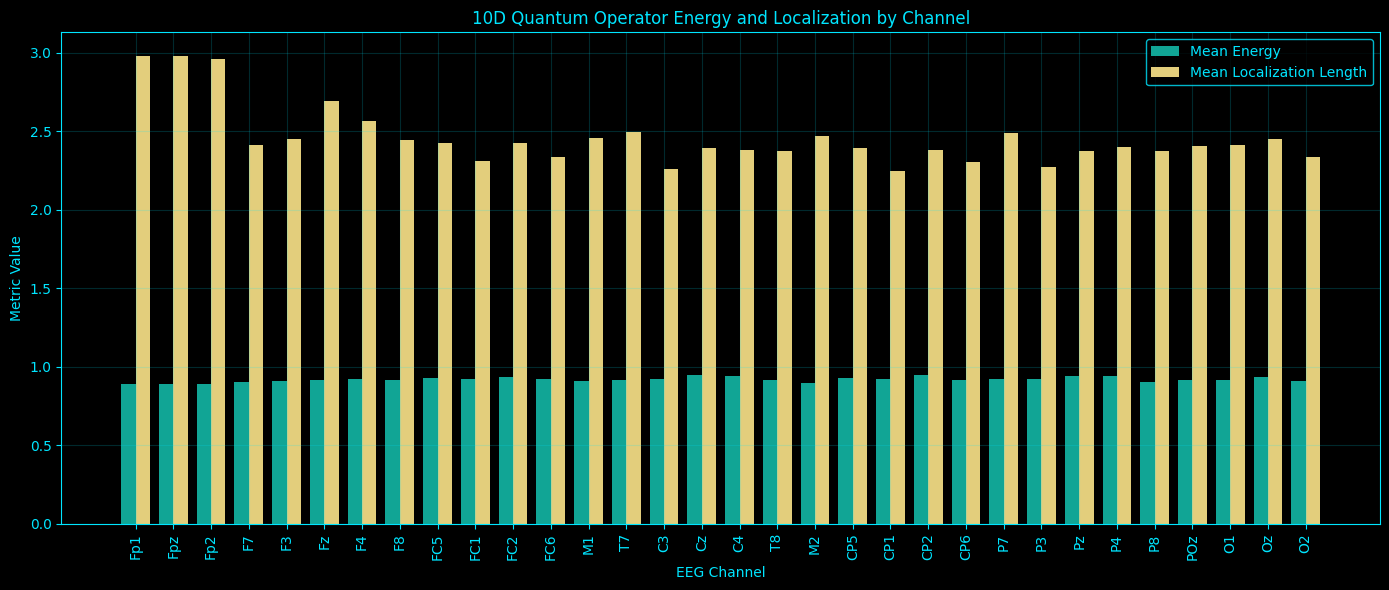

[   184.4s] Displayed plot: operator_10d_channel_energy_localization.png
[   184.7s] Saved plot: operator_10d_channel_eigenspectrum.png


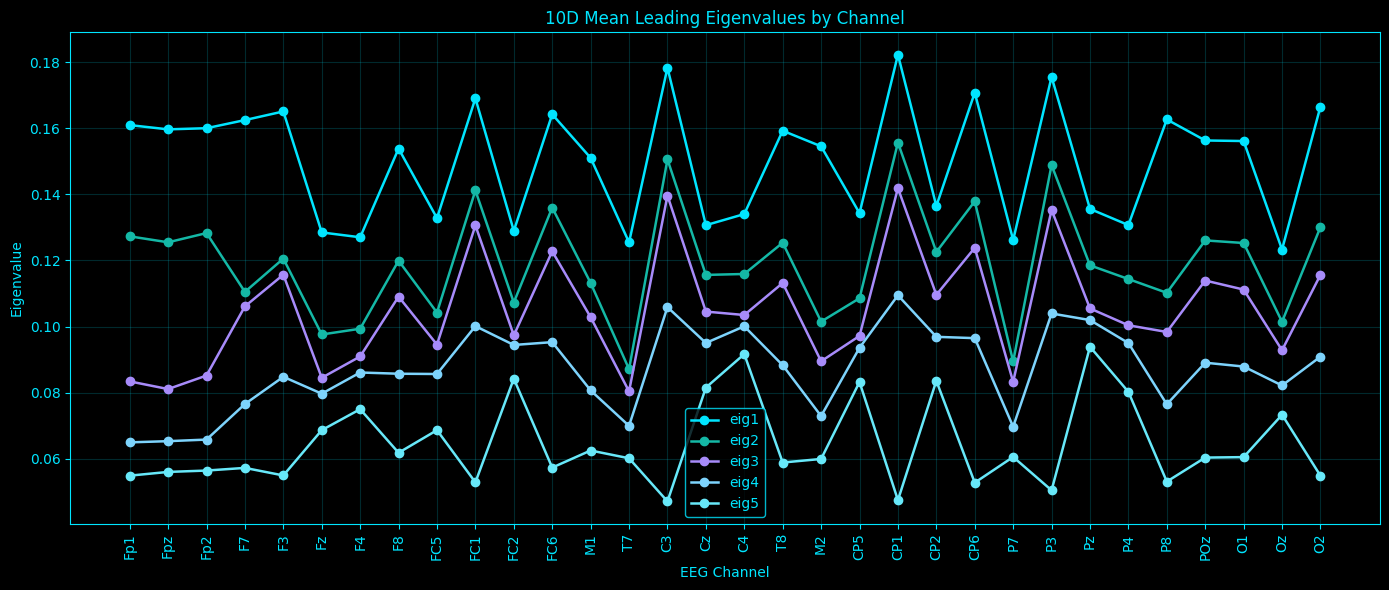

[   184.8s] Displayed plot: operator_10d_channel_eigenspectrum.png
[   184.9s] Saved plot: operator_10d_selected_spectral_gap_time.png


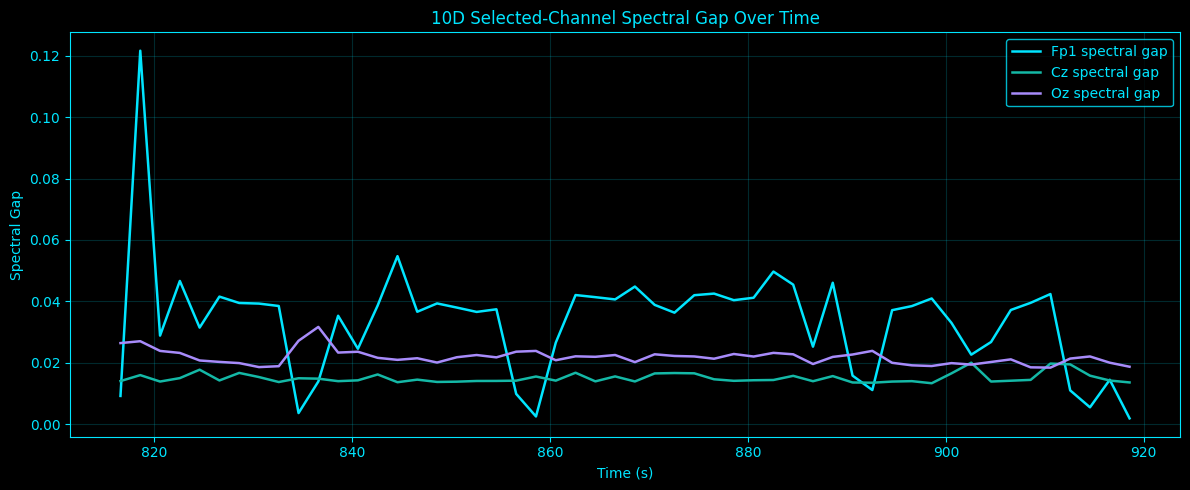

[   185.0s] Displayed plot: operator_10d_selected_spectral_gap_time.png
[   185.2s] Saved plot: operator_10d_selected_energy_time.png


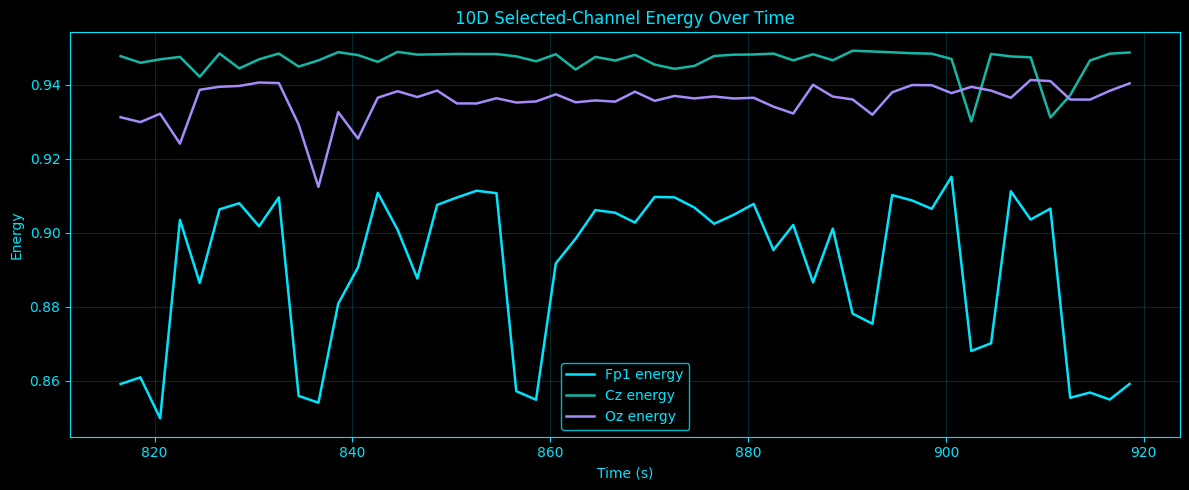

[   185.2s] Displayed plot: operator_10d_selected_energy_time.png
[   185.5s] Saved plot: operator_10d_channel_flow_features.png


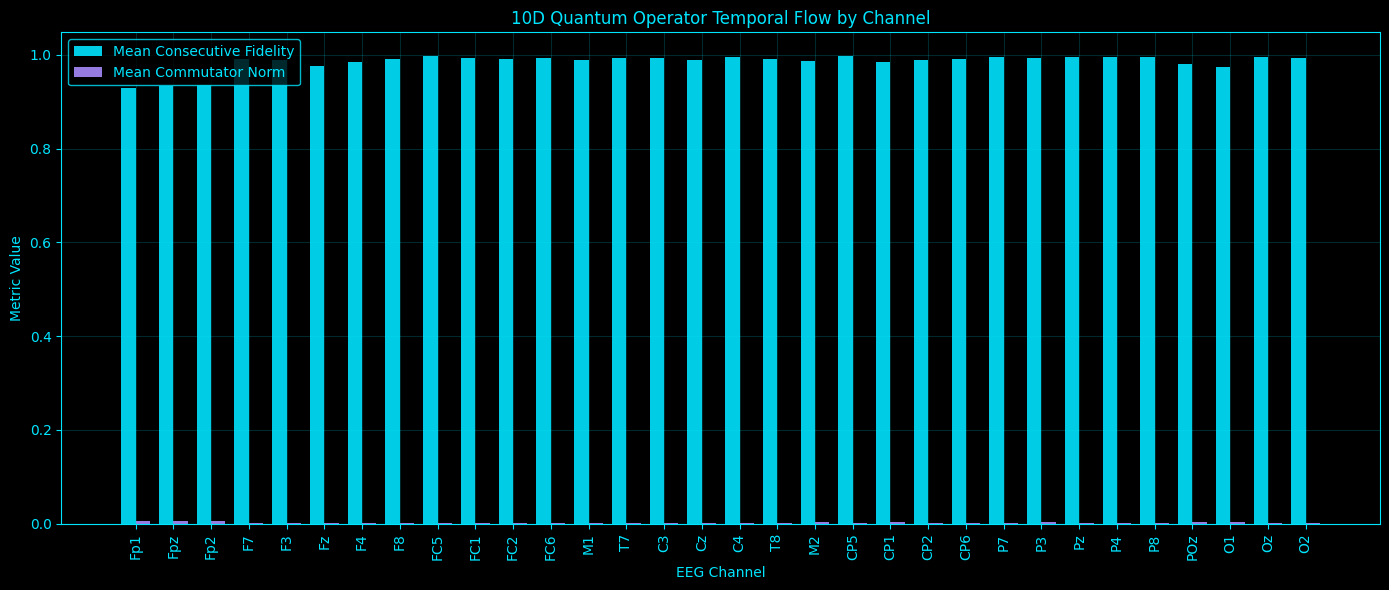

[   185.6s] Displayed plot: operator_10d_channel_flow_features.png
[   185.7s] Saved plot: operator_10d_time_summary.png


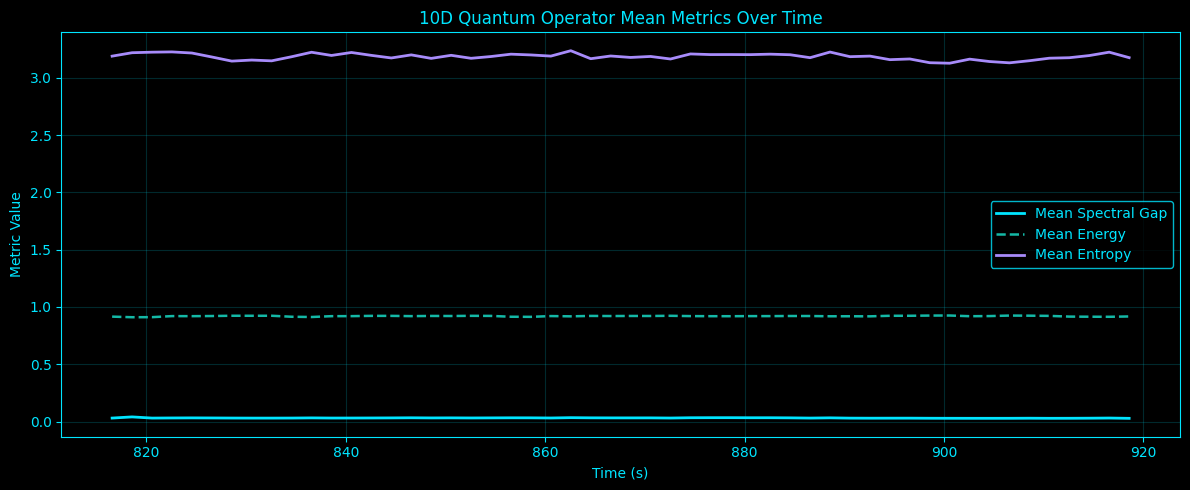

[   185.8s] Displayed plot: operator_10d_time_summary.png
[   185.9s] Saved plot: operator_10d_flow_time_summary.png


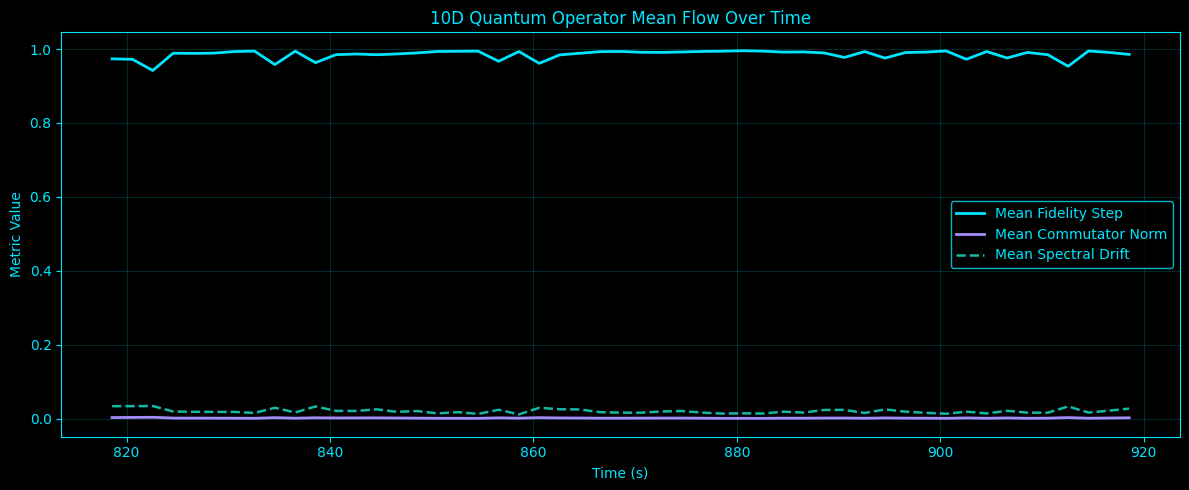

[   186.0s] Displayed plot: operator_10d_flow_time_summary.png
[   186.3s] Saved plot: operator_10d_channel_fidelity_heatmap.png


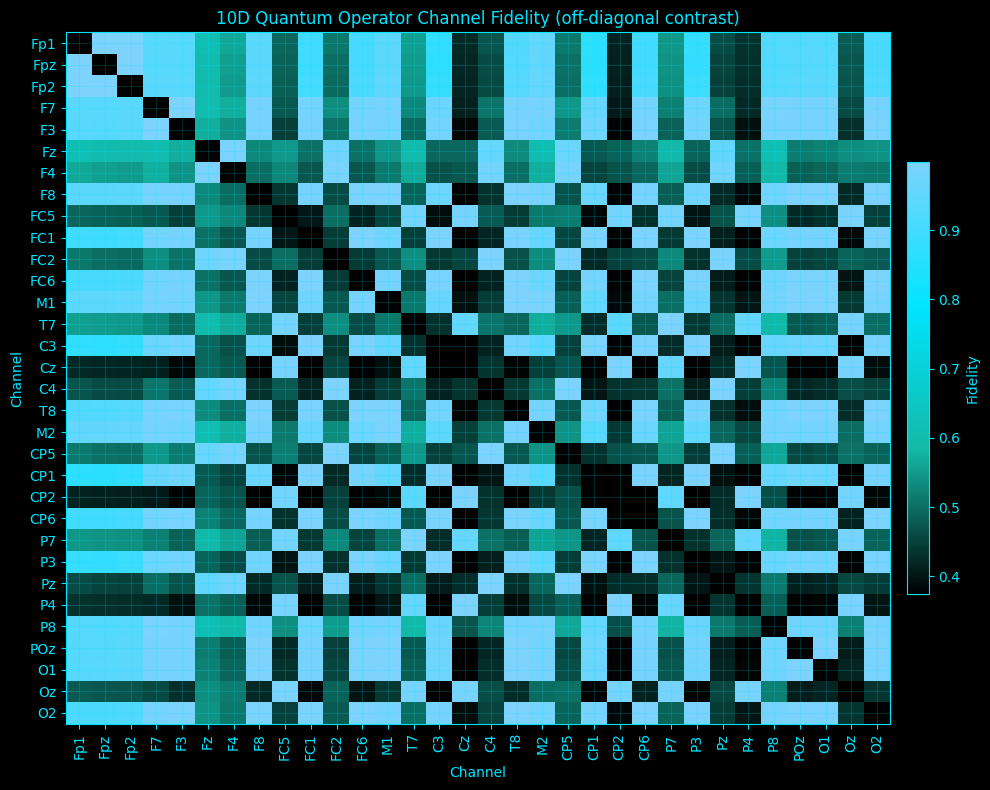

[   186.5s] Displayed plot: operator_10d_channel_fidelity_heatmap.png
[   186.5s] Saved cross-dim comparison CSV: quantum_operator_2d_to_10d_comparison.csv

Cross-dimension comparison:
   embedding_dim  n_states    sigma2  graph_sigma  mean_channel_spectral_gap  \
0              2        24  0.067832     1.823255                   0.015538   
1              3        24  0.214393     2.088268                   0.025880   
2              4        32  0.346378     2.380412                   0.027351   
3              5        32  0.497053     2.628191                   0.053400   
4              6        40  0.621898     2.732232                   0.025010   
5              7        40  0.841646     2.854333                   0.030610   
6              8        48  0.967515     3.103990                   0.028000   
7              9        48  1.133593     3.154544                   0.032601   
8             10        56  1.266609     3.375960                   0.030815   

   mean_channe

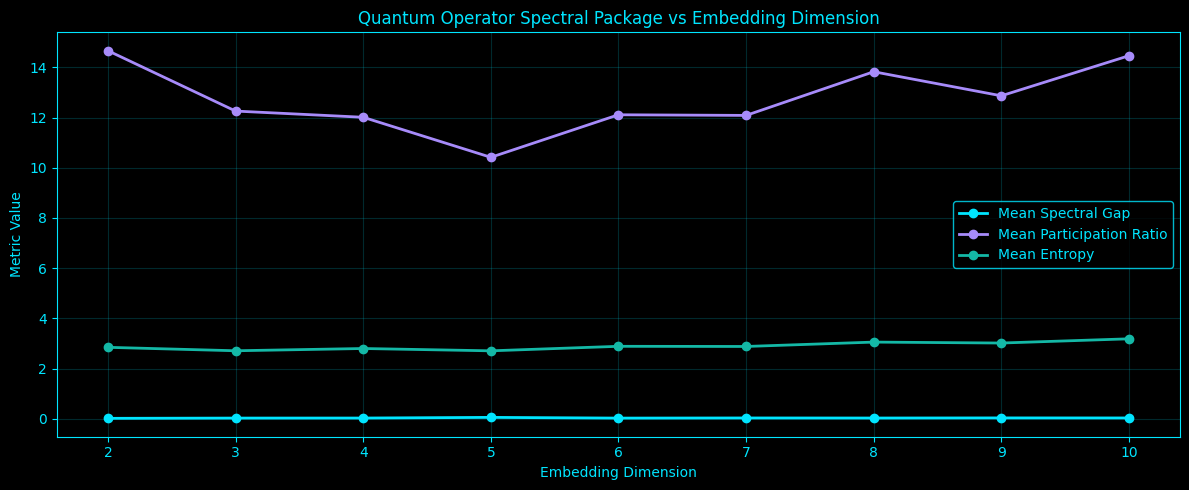

[   186.8s] Displayed plot: operator_metrics_vs_embedding_dim.png
[   186.9s] Saved plot: operator_energy_localization_vs_embedding_dim.png


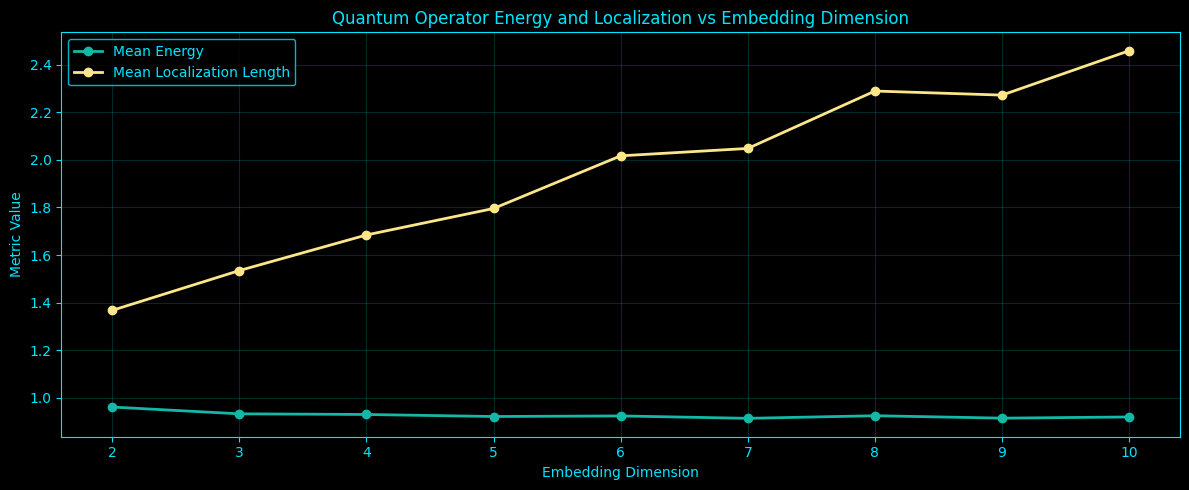

[   187.0s] Displayed plot: operator_energy_localization_vs_embedding_dim.png
[   187.2s] Saved plot: operator_fidelity_flow_vs_embedding_dim.png


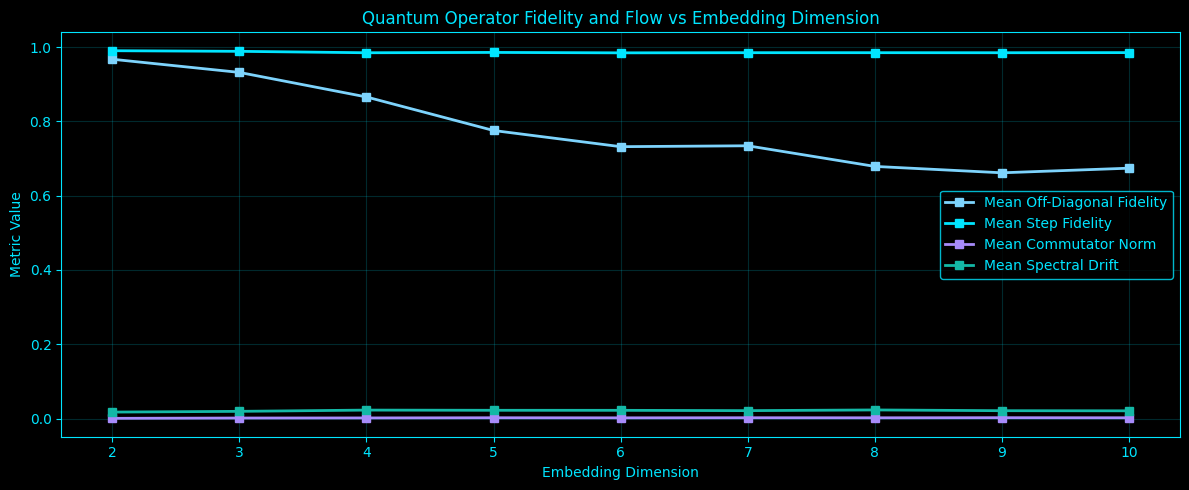

[   187.2s] Displayed plot: operator_fidelity_flow_vs_embedding_dim.png
[   187.2s] Done.


In [5]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial.distance import cdist

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = Path("/home/a/projects/Complete-Neural-Signal-Analysis")

embedding_dirs = {
    2: base_dir / "embedding_data" / "2dembedding_data",
    3: base_dir / "embedding_data" / "3dembedding_data",
}
for d in range(4, 11):
    embedding_dirs[d] = base_dir / "embedding_data" / "embeddings_4to10"

output_directory = base_dir / "quantum_operator_2d_to_10d"
plots_directory = output_directory / "plots"

output_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# same reference segment as the embedding-generation pipeline
sampling_rate = 1000
start_time, end_time = 814.571, 921.515

# analyze all embedding dimensions 2..10
EMBEDDING_DIMS = list(range(2, 11))

# codebook size grows mildly with embedding dimension
CODEBOOK_SIZE_MAP = {
    2: 24,
    3: 24,
    4: 32,
    5: 32,
    6: 40,
    7: 40,
    8: 48,
    9: 48,
    10: 56,
}

# windowing on embedded-point index axis
WINDOW_SEC = 4.0
STEP_SEC = 2.0

# shared codebook basis
FIT_SAMPLES_PER_CHANNEL = 2500
ALPHA_SMOOTH = 1e-3
USE_SOFT_ASSIGNMENT = True
SOFT_BETA_SCALE = 1.0

# graph-Hamiltonian settings
GRAPH_KERNEL_SCALE = "median"   # "median" or float
USE_NORMALIZED_LAPLACIAN = True

# output / runtime controls
SHOW_PLOTS = True                  # ALWAYS save + print plots
SAVE_PARTIALS = True
HEARTBEAT = True
HEARTBEAT_EVERY_CHANNELS = 4
HEARTBEAT_EVERY_WINDOWS = 20
RANDOM_SEED = 0

# selected channels for temporal traces
SELECTED_CHANNELS = ["Fp1", "Cz", "Oz"]

# if you want fewer per-dim plots, replace with a subset like [2, 3, 10]
PLOT_DIMS = EMBEDDING_DIMS.copy()

# -------------------------------------------------------
# COLOR PALETTE / STYLE
# -------------------------------------------------------
BG = "black"
ACCENT = "#00E5FF"
C_PRIMARY = "#00E5FF"
C_SECONDARY = "#14B8A6"
C_DIFF = "#A78BFA"
C_HIGHLIGHT = "#7DD3FC"
C_MUTED = "#67E8F9"
C_GOLD = "#FDE68A"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

QUANTUM_CMAP = LinearSegmentedColormap.from_list(
    "quantum_cmap",
    [BG, C_SECONDARY, C_PRIMARY, C_HIGHLIGHT]
)

rng = np.random.default_rng(RANDOM_SEED)

# -------------------------------------------------------
# HEARTBEAT
# -------------------------------------------------------
t0_global = time.perf_counter()

def hb(msg):
    if HEARTBEAT:
        dt = time.perf_counter() - t0_global
        print(f"[{dt:8.1f}s] {msg}", flush=True)

# -------------------------------------------------------
# STYLE HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT)

def style_colorbar(cbar):
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    if cbar.ax.yaxis.label is not None:
        cbar.ax.yaxis.label.set_color(ACCENT)

def style_legend(legend):
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_facecolor(BG)
    frame.set_edgecolor(ACCENT)
    for text in legend.get_texts():
        text.set_color(ACCENT)

def save_and_show(fig, out_path):
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    hb(f"Saved plot: {out_path.name}")
    if SHOW_PLOTS:
        plt.show()
        hb(f"Displayed plot: {out_path.name}")
    plt.close(fig)

# -------------------------------------------------------
# FILE HELPERS
# -------------------------------------------------------
def load_embedded_channel(channel_name, emb_dim):
    emb_dir = embedding_dirs[emb_dim]

    if emb_dim == 2:
        candidates = [
            emb_dir / f"2dembedded_{channel_name}.npy",
            emb_dir / f"2dembedded_{channel_name}_data.npy",
        ]
    elif emb_dim == 3:
        candidates = [
            emb_dir / f"3dembedded_{channel_name}.npy",
            emb_dir / f"3dembedded_{channel_name}_data.npy",
        ]
    else:
        candidates = [
            emb_dir / f"{emb_dim}dembedded_{channel_name}.npy",
            emb_dir / f"{emb_dim}dembedded_{channel_name}_data.npy",
        ]

    for path in candidates:
        if path.exists():
            arr = np.load(path)
            arr = np.asarray(arr, dtype=float)
            if arr.ndim != 2 or arr.shape[1] != emb_dim:
                raise ValueError(f"{path.name} has shape {arr.shape}, expected (N, {emb_dim})")
            return arr

    raise FileNotFoundError(f"No {emb_dim}D embedding found for channel {channel_name}")

# -------------------------------------------------------
# NUMERIC HELPERS
# -------------------------------------------------------
def zscore_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, ddof=1, keepdims=True)
    return np.divide(X - mu, sd, out=np.zeros_like(X), where=sd > 1e-12)

def sqrtm_psd(A):
    A = 0.5 * (A + A.T)
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals = np.clip(eigvals, 0.0, None)
    return (eigvecs * np.sqrt(eigvals)) @ eigvecs.T

def quantum_fidelity(rho, sigma):
    sr = sqrtm_psd(rho)
    middle = sr @ sigma @ sr
    sm = sqrtm_psd(middle)
    val = float(np.real(np.trace(sm)) ** 2)
    return max(0.0, min(1.0 + 1e-10, val))

def commutator_norm(A, B):
    C = A @ B - B @ A
    return float(np.linalg.norm(C, ord="fro"))

# -------------------------------------------------------
# CODEBOOK QUANTUM STATE
# -------------------------------------------------------
def fit_shared_codebook(X_pool, n_states, random_state=0):
    model = MiniBatchKMeans(
        n_clusters=n_states,
        random_state=random_state,
        batch_size=min(4096, max(256, n_states * 16)),
        n_init=10,
        max_iter=300
    )
    model.fit(X_pool)
    centers = np.asarray(model.cluster_centers_, dtype=float)

    labels = model.predict(X_pool)
    dist2 = np.sum((X_pool - centers[labels]) ** 2, axis=1)
    sigma2 = float(np.median(dist2) + 1e-12)

    return centers, sigma2

def soft_assignments(X, centers, sigma2, beta_scale=1.0):
    X = np.asarray(X, dtype=float)
    centers = np.asarray(centers, dtype=float)

    diff = X[:, None, :] - centers[None, :, :]
    dist2 = np.sum(diff * diff, axis=2)

    if USE_SOFT_ASSIGNMENT:
        logits = -dist2 / (2.0 * sigma2 * beta_scale + 1e-12)
        logits = logits - np.max(logits, axis=1, keepdims=True)
        A = np.exp(logits)
        A = A / (A.sum(axis=1, keepdims=True) + 1e-12)
    else:
        idx = np.argmin(dist2, axis=1)
        A = np.zeros((len(X), len(centers)), dtype=float)
        A[np.arange(len(X)), idx] = 1.0

    return A

def codebook_density_matrix(window_points, centers, sigma2, alpha=1e-3, beta_scale=1.0):
    """
    rho = (A^T A + alpha I) / trace(...)
    where A is the soft-assignment matrix into the shared codebook basis.
    """
    X = zscore_columns(window_points)
    A = soft_assignments(X, centers, sigma2=sigma2, beta_scale=beta_scale)

    rho = (A.T @ A) / max(len(A), 1)
    rho = rho + alpha * np.eye(rho.shape[0])
    rho = 0.5 * (rho + rho.T)
    rho = rho / np.trace(rho)

    return rho

# -------------------------------------------------------
# GRAPH HAMILTONIAN / ENERGY FEATURES
# -------------------------------------------------------
def build_codebook_hamiltonian(centers, kernel_scale="median", normalized=True):
    D = cdist(centers, centers, metric="euclidean")
    offdiag = D[~np.eye(len(D), dtype=bool)]

    if isinstance(kernel_scale, str) and kernel_scale == "median":
        sigma = float(np.median(offdiag) + 1e-12)
    else:
        sigma = float(kernel_scale)

    W = np.exp(-(D ** 2) / (2.0 * sigma ** 2 + 1e-12))
    np.fill_diagonal(W, 0.0)

    deg = np.sum(W, axis=1)
    L = np.diag(deg) - W

    if normalized:
        inv_sqrt_deg = 1.0 / np.sqrt(deg + 1e-12)
        L = np.diag(inv_sqrt_deg) @ L @ np.diag(inv_sqrt_deg)

    L = 0.5 * (L + L.T)
    return L, sigma

def localization_length(rho, centers):
    """
    Use diagonal occupancy over codebook states to measure spatial spread.
    """
    p = np.clip(np.real(np.diag(rho)), 0.0, None)
    p = p / (p.sum() + 1e-12)

    mu = p @ centers
    sq = np.sum((centers - mu) ** 2, axis=1)
    spread2 = float(np.sum(p * sq))
    return float(np.sqrt(max(spread2, 0.0)))

def operator_spectral_metrics(rho, top_k=5):
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.clip(np.real(eigvals), 0.0, None)
    eigvals = eigvals / (eigvals.sum() + 1e-12)
    eigvals = np.sort(eigvals)[::-1]

    lambda_max = float(eigvals[0])
    lambda2 = float(eigvals[1]) if len(eigvals) > 1 else np.nan
    spectral_gap = float(lambda_max - lambda2) if len(eigvals) > 1 else np.nan

    ipr = float(np.sum(eigvals ** 2))
    participation_ratio = float(1.0 / (ipr + 1e-12))

    entropy_vn = float(-np.sum(eigvals * np.log(eigvals + 1e-12)))
    effective_rank = float(np.exp(entropy_vn))

    out = {
        "lambda_max": lambda_max,
        "lambda2": lambda2,
        "spectral_gap": spectral_gap,
        "ipr": ipr,
        "participation_ratio": participation_ratio,
        "entropy_vn": entropy_vn,
        "effective_rank": effective_rank,
    }

    for i in range(top_k):
        out[f"eig_{i+1}"] = float(eigvals[i]) if i < len(eigvals) else np.nan

    return out, eigvals

def operator_energy_metrics(rho, H, centers):
    E = float(np.trace(rho @ H))
    H2 = H @ H
    varE = float(np.trace(rho @ H2) - E**2)
    loc_len = localization_length(rho, centers)

    return {
        "energy": E,
        "energy_variance": varE,
        "localization_length": loc_len,
    }

# -------------------------------------------------------
# MAIN ANALYSIS FOR ONE EMBEDDING DIMENSION
# -------------------------------------------------------
def run_dim_analysis(emb_dim):
    hb(f"Starting advanced operator analysis for {emb_dim}D")

    # -----------------------------
    # Load and align all channels
    # -----------------------------
    embedded = {}
    for idx, ch in enumerate(eeg_channels, start=1):
        embedded[ch] = zscore_columns(load_embedded_channel(ch, emb_dim))
        if idx == 1 or idx % HEARTBEAT_EVERY_CHANNELS == 0 or idx == len(eeg_channels):
            hb(f"{emb_dim}D loaded {idx}/{len(eeg_channels)}: {ch} shape={embedded[ch].shape}")

    common_length = min(len(embedded[ch]) for ch in eeg_channels)
    hb(f"{emb_dim}D common length across channels: {common_length}")

    for ch in eeg_channels:
        embedded[ch] = embedded[ch][:common_length]

    window_size = int(WINDOW_SEC * sampling_rate)
    step_size = int(STEP_SEC * sampling_rate)

    if common_length < window_size:
        raise ValueError(f"{emb_dim}D embeddings shorter than window size")

    window_starts = np.arange(0, common_length - window_size + 1, step_size)
    hb(
        f"{emb_dim}D windowing | window={WINDOW_SEC:.2f}s ({window_size}) | "
        f"step={STEP_SEC:.2f}s ({step_size}) | n_windows={len(window_starts)}"
    )

    # -----------------------------
    # Fit shared codebook
    # -----------------------------
    n_states = CODEBOOK_SIZE_MAP[emb_dim]
    pool = []

    for ch in eeg_channels:
        X = embedded[ch]
        n = len(X)
        if n <= FIT_SAMPLES_PER_CHANNEL:
            pool.append(X)
        else:
            idx = np.sort(rng.choice(n, size=FIT_SAMPLES_PER_CHANNEL, replace=False))
            pool.append(X[idx])

    X_pool = np.vstack(pool)
    hb(f"{emb_dim}D fitting codebook | pool_shape={X_pool.shape} | states={n_states}")

    centers, sigma2 = fit_shared_codebook(
        X_pool,
        n_states=n_states,
        random_state=RANDOM_SEED + emb_dim
    )
    hb(f"{emb_dim}D codebook fit complete | sigma2={sigma2:.6f}")

    codebook_npz_path = output_directory / f"codebook_{emb_dim}d.npz"
    np.savez_compressed(codebook_npz_path, centers=centers, sigma2=sigma2)

    # -----------------------------
    # Build graph Hamiltonian
    # -----------------------------
    H, graph_sigma = build_codebook_hamiltonian(
        centers,
        kernel_scale=GRAPH_KERNEL_SCALE,
        normalized=USE_NORMALIZED_LAPLACIAN
    )
    hb(f"{emb_dim}D Hamiltonian built | graph_sigma={graph_sigma:.6f}")

    # -----------------------------
    # Window loop per channel
    # -----------------------------
    rows = []
    flow_rows = []
    per_channel_rhos = {ch: [] for ch in eeg_channels}

    metrics_csv_path = output_directory / f"quantum_operator_{emb_dim}d_window_metrics.csv"
    flow_csv_path = output_directory / f"quantum_operator_{emb_dim}d_flow_metrics.csv"
    channel_summary_csv_path = output_directory / f"quantum_operator_{emb_dim}d_channel_summary.csv"
    flow_summary_csv_path = output_directory / f"quantum_operator_{emb_dim}d_flow_summary.csv"
    fidelity_csv_path = output_directory / f"quantum_operator_{emb_dim}d_channel_fidelity.csv"

    for ch_idx, ch in enumerate(eeg_channels, start=1):
        X = embedded[ch]
        prev_rho = None
        prev_eigs = None

        for w_idx, start in enumerate(window_starts, start=1):
            end = start + window_size
            Xw = X[start:end]

            rho = codebook_density_matrix(
                Xw,
                centers=centers,
                sigma2=sigma2,
                alpha=ALPHA_SMOOTH,
                beta_scale=SOFT_BETA_SCALE
            )
            per_channel_rhos[ch].append(rho)

            spec_metrics, eigvals = operator_spectral_metrics(rho, top_k=5)
            energy_metrics = operator_energy_metrics(rho, H, centers)

            rows.append({
                "embedding_dim": emb_dim,
                "channel": ch,
                "window_index": w_idx,
                "start_sample": int(start),
                "end_sample": int(end),
                "center_time_sec": float(start_time + (start + window_size / 2) / sampling_rate),
                "n_states": n_states,
                "sigma2": sigma2,
                "graph_sigma": graph_sigma,
                **spec_metrics,
                **energy_metrics,
            })

            if prev_rho is not None:
                flow_rows.append({
                    "embedding_dim": emb_dim,
                    "channel": ch,
                    "window_index_prev": w_idx - 1,
                    "window_index_curr": w_idx,
                    "center_time_prev_sec": float(start_time + (window_starts[w_idx - 2] + window_size / 2) / sampling_rate),
                    "center_time_curr_sec": float(start_time + (start + window_size / 2) / sampling_rate),
                    "fidelity_step": quantum_fidelity(prev_rho, rho),
                    "commutator_norm": commutator_norm(prev_rho, rho),
                    "spectral_drift": float(np.linalg.norm(eigvals - prev_eigs)),
                })

            prev_rho = rho
            prev_eigs = eigvals.copy()

            if ch_idx == 1 and (w_idx == 1 or w_idx % HEARTBEAT_EVERY_WINDOWS == 0 or w_idx == len(window_starts)):
                hb(
                    f"{emb_dim}D {ch} window {w_idx}/{len(window_starts)} | "
                    f"gap={spec_metrics['spectral_gap']:.5f} | "
                    f"PR={spec_metrics['participation_ratio']:.3f} | "
                    f"E={energy_metrics['energy']:.5f}"
                )

        if ch_idx == 1 or ch_idx % HEARTBEAT_EVERY_CHANNELS == 0 or ch_idx == len(eeg_channels):
            hb(f"{emb_dim}D processed channel {ch_idx}/{len(eeg_channels)}: {ch}")
            if SAVE_PARTIALS:
                pd.DataFrame(rows).to_csv(metrics_csv_path, index=False)
                pd.DataFrame(flow_rows).to_csv(flow_csv_path, index=False)
                hb(f"{emb_dim}D partial CSVs saved after {ch}")

    metrics_df = pd.DataFrame(rows)
    flow_df = pd.DataFrame(flow_rows)

    metrics_df.to_csv(metrics_csv_path, index=False)
    flow_df.to_csv(flow_csv_path, index=False)

    # -----------------------------
    # Channel summaries
    # -----------------------------
    channel_summary_df = (
        metrics_df
        .groupby("channel", as_index=False)[
            [
                "spectral_gap", "participation_ratio", "ipr", "entropy_vn",
                "effective_rank", "energy", "energy_variance", "localization_length",
                "lambda_max", "lambda2", "eig_1", "eig_2", "eig_3", "eig_4", "eig_5"
            ]
        ]
        .mean()
    )
    channel_summary_df["channel"] = pd.Categorical(
        channel_summary_df["channel"],
        categories=eeg_channels,
        ordered=True
    )
    channel_summary_df = channel_summary_df.sort_values("channel").reset_index(drop=True)
    channel_summary_df.to_csv(channel_summary_csv_path, index=False)

    flow_summary_df = (
        flow_df
        .groupby("channel", as_index=False)[
            ["fidelity_step", "commutator_norm", "spectral_drift"]
        ]
        .mean()
    )
    flow_summary_df["channel"] = pd.Categorical(
        flow_summary_df["channel"],
        categories=eeg_channels,
        ordered=True
    )
    flow_summary_df = flow_summary_df.sort_values("channel").reset_index(drop=True)
    flow_summary_df.to_csv(flow_summary_csv_path, index=False)

    # -----------------------------
    # Time summaries
    # -----------------------------
    time_summary_df = (
        metrics_df
        .groupby("center_time_sec", as_index=False)[
            [
                "spectral_gap", "participation_ratio", "ipr", "entropy_vn",
                "effective_rank", "energy", "energy_variance", "localization_length",
                "lambda_max"
            ]
        ]
        .mean()
    )

    time_flow_summary_df = (
        flow_df
        .groupby("center_time_curr_sec", as_index=False)[
            ["fidelity_step", "commutator_norm", "spectral_drift"]
        ]
        .mean()
    )

    # -----------------------------
    # Channel fidelity matrix
    # -----------------------------
    mean_rhos = {
        ch: np.mean(np.stack(per_channel_rhos[ch], axis=0), axis=0)
        for ch in eeg_channels
    }

    fidelity = np.zeros((len(eeg_channels), len(eeg_channels)), dtype=float)
    for i, ch_i in enumerate(eeg_channels):
        for j, ch_j in enumerate(eeg_channels):
            fidelity[i, j] = quantum_fidelity(mean_rhos[ch_i], mean_rhos[ch_j])

    fidelity_df = pd.DataFrame(fidelity, index=eeg_channels, columns=eeg_channels)
    fidelity_df.to_csv(fidelity_csv_path)

    F_off = fidelity.copy()
    np.fill_diagonal(F_off, np.nan)
    mean_offdiag_fidelity = float(np.nanmean(F_off))

    # -----------------------------
    # Print quick summary
    # -----------------------------
    print(f"\n{emb_dim}D channel summary head:")
    print(channel_summary_df.head())

    print(f"\n{emb_dim}D top channels by mean spectral gap:")
    print(
        channel_summary_df[["channel", "spectral_gap"]]
        .sort_values("spectral_gap", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    # -----------------------------
    # Per-dim plots
    # -----------------------------
    if emb_dim in PLOT_DIMS:
        x = np.arange(len(eeg_channels))
        width = 0.38

        # 1) Channel spectral package
        fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
        style_ax(ax)

        ax.bar(
            x - width / 2,
            channel_summary_df["spectral_gap"].to_numpy(dtype=float),
            width=width,
            color=C_PRIMARY,
            alpha=0.90,
            label="Mean Spectral Gap"
        )
        ax.bar(
            x + width / 2,
            channel_summary_df["participation_ratio"].to_numpy(dtype=float),
            width=width,
            color=C_DIFF,
            alpha=0.90,
            label="Mean Participation Ratio"
        )

        ax.set_title(f"{emb_dim}D Quantum Operator Spectral Features by Channel")
        ax.set_xlabel("EEG Channel")
        ax.set_ylabel("Metric Value")
        ax.set_xticks(x)
        ax.set_xticklabels(eeg_channels, rotation=90)

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"operator_{emb_dim}d_channel_spectral_features.png")

        # 2) Channel energy / localization
        fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
        style_ax(ax)

        ax.bar(
            x - width / 2,
            channel_summary_df["energy"].to_numpy(dtype=float),
            width=width,
            color=C_SECONDARY,
            alpha=0.90,
            label="Mean Energy"
        )
        ax.bar(
            x + width / 2,
            channel_summary_df["localization_length"].to_numpy(dtype=float),
            width=width,
            color=C_GOLD,
            alpha=0.90,
            label="Mean Localization Length"
        )

        ax.set_title(f"{emb_dim}D Quantum Operator Energy and Localization by Channel")
        ax.set_xlabel("EEG Channel")
        ax.set_ylabel("Metric Value")
        ax.set_xticks(x)
        ax.set_xticklabels(eeg_channels, rotation=90)

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"operator_{emb_dim}d_channel_energy_localization.png")

        # 3) Mean leading eigenspectrum by channel
        fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
        style_ax(ax)

        ax.plot(x, channel_summary_df["eig_1"].to_numpy(dtype=float), marker="o", linewidth=1.8, color=C_PRIMARY, label="eig1")
        ax.plot(x, channel_summary_df["eig_2"].to_numpy(dtype=float), marker="o", linewidth=1.8, color=C_SECONDARY, label="eig2")
        ax.plot(x, channel_summary_df["eig_3"].to_numpy(dtype=float), marker="o", linewidth=1.8, color=C_DIFF, label="eig3")
        ax.plot(x, channel_summary_df["eig_4"].to_numpy(dtype=float), marker="o", linewidth=1.8, color=C_HIGHLIGHT, label="eig4")
        ax.plot(x, channel_summary_df["eig_5"].to_numpy(dtype=float), marker="o", linewidth=1.8, color=C_MUTED, label="eig5")

        ax.set_title(f"{emb_dim}D Mean Leading Eigenvalues by Channel")
        ax.set_xlabel("EEG Channel")
        ax.set_ylabel("Eigenvalue")
        ax.set_xticks(x)
        ax.set_xticklabels(eeg_channels, rotation=90)

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"operator_{emb_dim}d_channel_eigenspectrum.png")

        # 4) Selected channel temporal operator metrics
        selected = [ch for ch in SELECTED_CHANNELS if ch in eeg_channels]
        if selected:
            colors = [C_PRIMARY, C_SECONDARY, C_DIFF, C_HIGHLIGHT]

            fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
            style_ax(ax)

            for idx, ch in enumerate(selected):
                df_ch = metrics_df[metrics_df["channel"] == ch].copy()
                ax.plot(
                    df_ch["center_time_sec"].to_numpy(),
                    df_ch["spectral_gap"].to_numpy(),
                    linewidth=1.8,
                    color=colors[idx % len(colors)],
                    label=f"{ch} spectral gap"
                )

            ax.set_title(f"{emb_dim}D Selected-Channel Spectral Gap Over Time")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Spectral Gap")

            legend = ax.legend()
            style_legend(legend)

            save_and_show(fig, plots_directory / f"operator_{emb_dim}d_selected_spectral_gap_time.png")

            fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
            style_ax(ax)

            for idx, ch in enumerate(selected):
                df_ch = metrics_df[metrics_df["channel"] == ch].copy()
                ax.plot(
                    df_ch["center_time_sec"].to_numpy(),
                    df_ch["energy"].to_numpy(),
                    linewidth=1.8,
                    color=colors[idx % len(colors)],
                    label=f"{ch} energy"
                )

            ax.set_title(f"{emb_dim}D Selected-Channel Energy Over Time")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Energy")

            legend = ax.legend()
            style_legend(legend)

            save_and_show(fig, plots_directory / f"operator_{emb_dim}d_selected_energy_time.png")

        # 5) Temporal flow summary by channel
        fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
        style_ax(ax)

        ax.bar(
            x - width/2,
            flow_summary_df["fidelity_step"].to_numpy(dtype=float),
            width=width,
            color=C_PRIMARY,
            alpha=0.90,
            label="Mean Consecutive Fidelity"
        )
        ax.bar(
            x + width/2,
            flow_summary_df["commutator_norm"].to_numpy(dtype=float),
            width=width,
            color=C_DIFF,
            alpha=0.90,
            label="Mean Commutator Norm"
        )

        ax.set_title(f"{emb_dim}D Quantum Operator Temporal Flow by Channel")
        ax.set_xlabel("EEG Channel")
        ax.set_ylabel("Metric Value")
        ax.set_xticks(x)
        ax.set_xticklabels(eeg_channels, rotation=90)

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"operator_{emb_dim}d_channel_flow_features.png")

        # 6) Mean metrics over time
        fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
        style_ax(ax)

        ax.plot(
            time_summary_df["center_time_sec"].to_numpy(),
            time_summary_df["spectral_gap"].to_numpy(),
            linewidth=2.0,
            color=C_PRIMARY,
            label="Mean Spectral Gap"
        )
        ax.plot(
            time_summary_df["center_time_sec"].to_numpy(),
            time_summary_df["energy"].to_numpy(),
            linewidth=1.8,
            linestyle="--",
            color=C_SECONDARY,
            label="Mean Energy"
        )
        ax.plot(
            time_summary_df["center_time_sec"].to_numpy(),
            time_summary_df["entropy_vn"].to_numpy(),
            linewidth=2.0,
            color=C_DIFF,
            label="Mean Entropy"
        )

        ax.set_title(f"{emb_dim}D Quantum Operator Mean Metrics Over Time")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Metric Value")

        legend = ax.legend()
        style_legend(legend)

        save_and_show(fig, plots_directory / f"operator_{emb_dim}d_time_summary.png")

        # 7) Mean flow metrics over time
        if not time_flow_summary_df.empty:
            fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
            style_ax(ax)

            ax.plot(
                time_flow_summary_df["center_time_curr_sec"].to_numpy(),
                time_flow_summary_df["fidelity_step"].to_numpy(),
                linewidth=2.0,
                color=C_PRIMARY,
                label="Mean Fidelity Step"
            )
            ax.plot(
                time_flow_summary_df["center_time_curr_sec"].to_numpy(),
                time_flow_summary_df["commutator_norm"].to_numpy(),
                linewidth=2.0,
                color=C_DIFF,
                label="Mean Commutator Norm"
            )
            ax.plot(
                time_flow_summary_df["center_time_curr_sec"].to_numpy(),
                time_flow_summary_df["spectral_drift"].to_numpy(),
                linewidth=1.8,
                linestyle="--",
                color=C_SECONDARY,
                label="Mean Spectral Drift"
            )

            ax.set_title(f"{emb_dim}D Quantum Operator Mean Flow Over Time")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Metric Value")

            legend = ax.legend()
            style_legend(legend)

            save_and_show(fig, plots_directory / f"operator_{emb_dim}d_flow_time_summary.png")

        # 8) Fidelity heatmap with off-diagonal contrast
        F_plot = fidelity.copy()
        np.fill_diagonal(F_plot, np.nan)
        vmin = float(np.nanpercentile(F_plot, 5))
        vmax = float(np.nanpercentile(F_plot, 95))

        fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
        style_ax(ax)

        im = ax.imshow(
            F_plot,
            cmap=QUANTUM_CMAP,
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(f"{emb_dim}D Quantum Operator Channel Fidelity (off-diagonal contrast)")
        ax.set_xlabel("Channel")
        ax.set_ylabel("Channel")
        ax.set_xticks(np.arange(len(eeg_channels)))
        ax.set_xticklabels(eeg_channels, rotation=90)
        ax.set_yticks(np.arange(len(eeg_channels)))
        ax.set_yticklabels(eeg_channels)

        cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
        cbar.set_label("Fidelity", color=ACCENT)
        style_colorbar(cbar)

        save_and_show(fig, plots_directory / f"operator_{emb_dim}d_channel_fidelity_heatmap.png")

    return {
        "emb_dim": emb_dim,
        "n_states": n_states,
        "sigma2": sigma2,
        "graph_sigma": graph_sigma,
        "metrics_df": metrics_df,
        "flow_df": flow_df,
        "channel_summary_df": channel_summary_df,
        "flow_summary_df": flow_summary_df,
        "time_summary_df": time_summary_df,
        "time_flow_summary_df": time_flow_summary_df,
        "fidelity_df": fidelity_df,
        "mean_offdiag_fidelity": mean_offdiag_fidelity,
    }

# -------------------------------------------------------
# RUN ALL EMBEDDING DIMS 2..10
# -------------------------------------------------------
all_results = {}
comparison_rows = []

for emb_dim in EMBEDDING_DIMS:
    res = run_dim_analysis(emb_dim)
    all_results[emb_dim] = res

    summary = res["channel_summary_df"]
    flow_summary = res["flow_summary_df"]

    comparison_rows.append({
        "embedding_dim": emb_dim,
        "n_states": res["n_states"],
        "sigma2": res["sigma2"],
        "graph_sigma": res["graph_sigma"],
        "mean_channel_spectral_gap": float(summary["spectral_gap"].mean()),
        "mean_channel_participation_ratio": float(summary["participation_ratio"].mean()),
        "mean_channel_entropy": float(summary["entropy_vn"].mean()),
        "mean_channel_energy": float(summary["energy"].mean()),
        "mean_channel_localization_length": float(summary["localization_length"].mean()),
        "mean_channel_lambda_max": float(summary["lambda_max"].mean()),
        "mean_offdiag_fidelity": float(res["mean_offdiag_fidelity"]),
        "mean_step_fidelity": float(flow_summary["fidelity_step"].mean()),
        "mean_commutator_norm": float(flow_summary["commutator_norm"].mean()),
        "mean_spectral_drift": float(flow_summary["spectral_drift"].mean()),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("embedding_dim").reset_index(drop=True)
comparison_csv_path = output_directory / "quantum_operator_2d_to_10d_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
hb(f"Saved cross-dim comparison CSV: {comparison_csv_path.name}")

print("\nCross-dimension comparison:")
print(comparison_df)

# -------------------------------------------------------
# CROSS-DIM PLOTS
# -------------------------------------------------------
x = comparison_df["embedding_dim"].to_numpy()

# 1) spectral package vs embedding dimension
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    comparison_df["mean_channel_spectral_gap"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_PRIMARY,
    label="Mean Spectral Gap"
)
ax.plot(
    x,
    comparison_df["mean_channel_participation_ratio"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_DIFF,
    label="Mean Participation Ratio"
)
ax.plot(
    x,
    comparison_df["mean_channel_entropy"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_SECONDARY,
    label="Mean Entropy"
)

ax.set_title("Quantum Operator Spectral Package vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Metric Value")
ax.set_xticks(x)

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "operator_metrics_vs_embedding_dim.png")

# 2) energy / localization vs embedding dimension
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    comparison_df["mean_channel_energy"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_SECONDARY,
    label="Mean Energy"
)
ax.plot(
    x,
    comparison_df["mean_channel_localization_length"].to_numpy(),
    linewidth=2.0,
    marker="o",
    color=C_GOLD,
    label="Mean Localization Length"
)

ax.set_title("Quantum Operator Energy and Localization vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Metric Value")
ax.set_xticks(x)

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "operator_energy_localization_vs_embedding_dim.png")

# 3) fidelity / flow vs embedding dimension
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    x,
    comparison_df["mean_offdiag_fidelity"].to_numpy(),
    linewidth=2.0,
    marker="s",
    color=C_HIGHLIGHT,
    label="Mean Off-Diagonal Fidelity"
)
ax.plot(
    x,
    comparison_df["mean_step_fidelity"].to_numpy(),
    linewidth=2.0,
    marker="s",
    color=C_PRIMARY,
    label="Mean Step Fidelity"
)
ax.plot(
    x,
    comparison_df["mean_commutator_norm"].to_numpy(),
    linewidth=2.0,
    marker="s",
    color=C_DIFF,
    label="Mean Commutator Norm"
)
ax.plot(
    x,
    comparison_df["mean_spectral_drift"].to_numpy(),
    linewidth=2.0,
    marker="s",
    color=C_SECONDARY,
    label="Mean Spectral Drift"
)

ax.set_title("Quantum Operator Fidelity and Flow vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Metric Value")
ax.set_xticks(x)

legend = ax.legend()
style_legend(legend)

save_and_show(fig, plots_directory / "operator_fidelity_flow_vs_embedding_dim.png")

hb("Done.")